# Pronóstico de Volatilidad en Mercados de Criptomonedas mediante MLP Multisalida

**Notebook maestro reproducible**

Este notebook integra en un único flujo la adquisición de datos,
la preparación temporal, el análisis exploratorio, la construcción
de ventanas, la validación cronológica, el entrenamiento del MLP
multisalida, la evaluación y las conclusiones del proyecto.


# 2. Análisis Exploratorio de Datos (EDA)

Este capítulo reproduce las celdas 1–14 del notebook maestro `model_evaluation.ipynb`, con sus tablas y figuras guardadas. Incluye adquisición, preparación, período común, continuidad temporal, retornos, volatilidad de 30 horas y EDA. Las celdas de código conservan la etiqueta `skip-execution` para publicar las salidas existentes.

## 2.1 Configuración y adquisición de datos

El proyecto utiliza datos horarios de Binance Spot para cinco criptomonedas:

- BTCUSDT
- ETHUSDT
- BNBUSDT
- XRPUSDT
- SOLUSDT

La frecuencia utilizada es de una hora (`1h`).

Los datos serán descargados directamente desde la API pública de Binance para garantizar la reproducibilidad del proyecto.

La variable de interés será la volatilidad de los retornos logarítmicos.

El objetivo final será pronosticar simultáneamente los siguientes siete valores futuros de volatilidad mediante una red neuronal MLP multisalida.

In [2]:

import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# =========================================================
# CONFIGURACIN GENERAL DEL PROYECTO
# =========================================================

SYMBOLS = [
    "BTCUSDT",
    "ETHUSDT",
    "BNBUSDT",
    "XRPUSDT",
    "SOLUSDT",
]

INTERVAL = "1h"

START_DATE = "2020-01-01"
END_DATE = "2026-09-20"

BASE_URL = "https://data-api.binance.vision/api/v3/klines"

DATA_DIR = Path("data/processed")
DATA_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = DATA_DIR / "crypto_binance_master_1h.csv"

RANDOM_STATE = 42

INPUT_WINDOWS = [7, 14, 21, 28]
N_STEPS_FORECAST = 7
N_STEPS_JUMP = 1

print("Configuracin cargada correctamente.")
print("Criptomonedas:", SYMBOLS)
print("Frecuencia:", INTERVAL)
print("Periodo:", START_DATE, "a", END_DATE)
print("Ventanas de entrada:", INPUT_WINDOWS)
print("Horizonte de pronstico:", N_STEPS_FORECAST)


Configuracin cargada correctamente.
Criptomonedas: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'SOLUSDT']
Frecuencia: 1h
Periodo: 2020-01-01 a 2026-09-20
Ventanas de entrada: [7, 14, 21, 28]
Horizonte de pronstico: 7



### 2.1.1 Descarga de datos desde Binance Spot

Los datos OHLCV se obtienen directamente desde el endpoint público de Binance:

`https://data-api.binance.vision/api/v3/klines`

Para cada activo se descargan velas de una hora (`1h`) dentro del período de estudio.

Cada observación contiene las variables originales suministradas por Binance:

- Open time
- Open
- High
- Low
- Close
- Volume
- Close time
- Quote asset volume
- Number of trades
- Taker buy base asset volume
- Taker buy quote asset volume

Se conserva además el símbolo correspondiente a cada activo.

In [3]:

# =========================================================
# DESCARGA PAGINADA DE DATOS DESDE BINANCE SPOT
# =========================================================

KLINE_COLUMNS = [
    "open_time",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "close_time",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_base_asset_volume",
    "taker_buy_quote_asset_volume",
    "ignore",
]

NUMERIC_COLUMNS = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_base_asset_volume",
    "taker_buy_quote_asset_volume",
]

def download_binance_klines(
    symbol,
    interval,
    start_date,
    end_date,
    limit=1000,
    max_retries=5,
):
    """
    Descarga velas histricas de Binance Spot utilizando paginacin.
    """

    start_timestamp = pd.Timestamp(start_date, tz="UTC")

    # END_DATE se interpreta como da completo.
    end_timestamp = (
        pd.Timestamp(end_date, tz="UTC")
        + pd.Timedelta(days=1)
        - pd.Timedelta(milliseconds=1)
    )

    start_ms = int(start_timestamp.timestamp() * 1000)
    end_ms = int(end_timestamp.timestamp() * 1000)

    all_rows = []
    current_start = start_ms

    session = requests.Session()

    print(f"\nDescargando {symbol}...")

    while current_start <= end_ms:

        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_start,
            "endTime": end_ms,
            "limit": limit,
        }

        data = None

        for attempt in range(1, max_retries + 1):
            try:
                response = session.get(
                    BASE_URL,
                    params=params,
                    timeout=30,
                )

                response.raise_for_status()
                data = response.json()
                break

            except requests.RequestException as error:
                print(
                    f"Intento {attempt}/{max_retries} "
                    f"fallido para {symbol}: {error}"
                )

                if attempt == max_retries:
                    raise

                time.sleep(2 * attempt)

        if not data:
            break

        all_rows.extend(data)

        last_open_time = int(data[-1][0])

        # Evita repetir la ltima observacin.
        next_start = last_open_time + 1

        if next_start <= current_start:
            break

        current_start = next_start

        if len(data) < limit:
            break

        # Pequea pausa para evitar sobrecargar la API.
        time.sleep(0.05)

    if not all_rows:
        print(f"No se encontraron datos para {symbol}.")
        return pd.DataFrame(columns=KLINE_COLUMNS + ["symbol"])

    df_symbol = pd.DataFrame(
        all_rows,
        columns=KLINE_COLUMNS,
    )

    df_symbol["symbol"] = symbol

    df_symbol["open_time"] = pd.to_datetime(
        df_symbol["open_time"],
        unit="ms",
        utc=True,
    )

    df_symbol["close_time"] = pd.to_datetime(
        df_symbol["close_time"],
        unit="ms",
        utc=True,
    )

    for column in NUMERIC_COLUMNS:
        df_symbol[column] = pd.to_numeric(
            df_symbol[column],
            errors="coerce",
        )

    df_symbol["number_of_trades"] = (
        df_symbol["number_of_trades"]
        .fillna(0)
        .astype("int64")
    )

    df_symbol = (
        df_symbol
        .drop(columns=["ignore"])
        .drop_duplicates(
            subset=["symbol", "open_time"]
        )
        .sort_values("open_time")
        .reset_index(drop=True)
    )

    print(
        f"{symbol}: {len(df_symbol):,} observaciones | "
        f"{df_symbol['open_time'].min()} -> "
        f"{df_symbol['open_time'].max()}"
    )

    return df_symbol


# ---------------------------------------------------------
# DESCARGA O CARGA DESDE CACH LOCAL
# ---------------------------------------------------------

FORCE_DOWNLOAD = False

if OUTPUT_FILE.exists() and not FORCE_DOWNLOAD:

    print("Archivo local encontrado.")
    print("Cargando:", OUTPUT_FILE)

    df = pd.read_csv(
        OUTPUT_FILE
    )

    df["open_time"] = pd.to_datetime(
        df["open_time"],
        format="mixed",
        utc=True,
    )

    df["close_time"] = pd.to_datetime(
        df["close_time"],
        format="mixed",
        utc=True,
    )

else:

    datasets = []

    for symbol in SYMBOLS:

        temp = download_binance_klines(
            symbol=symbol,
            interval=INTERVAL,
            start_date=START_DATE,
            end_date=END_DATE,
        )

        datasets.append(temp)

    df = pd.concat(
        datasets,
        ignore_index=True,
    )

    df = (
        df
        .sort_values(["symbol", "open_time"])
        .reset_index(drop=True)
    )

    df.to_csv(
        OUTPUT_FILE,
        index=False,
    )

    print("\nArchivo guardado correctamente:")
    print(OUTPUT_FILE)


# ---------------------------------------------------------
# VALIDACIN INICIAL
# ---------------------------------------------------------

print("\nDimensiones del dataset:")
print(df.shape)

print("\nNmero de observaciones por activo:")
print(
    df.groupby("symbol")
      .size()
      .sort_index()
)

print("\nPeriodo disponible por activo:")

period_summary = (
    df.groupby("symbol")
      .agg(
          fecha_inicial=("open_time", "min"),
          fecha_final=("open_time", "max"),
          observaciones=("open_time", "size"),
      )
)

display(period_summary)

print("\nPrimeras observaciones:")
display(df.head())


Archivo local encontrado.
Cargando: data\processed\crypto_binance_master_1h.csv



Dimensiones del dataset:
(289094, 12)

Nmero de observaciones por activo:
symbol
BNBUSDT    58888
BTCUSDT    58888
ETHUSDT    58888
SOLUSDT    53542
XRPUSDT    58888
dtype: int64

Periodo disponible por activo:


,fecha_inicial,fecha_final,observaciones
symbol,,,
BNBUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888
BTCUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888
ETHUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888
SOLUSDT,2020-08-11 06:00:00+00:00,2026-09-20 23:00:00+00:00,53542
XRPUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888



Primeras observaciones:


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,symbol
0,2020-01-01 00:00:00+00:00,13.7159,13.7211,13.6903,13.6981,62016.69,2020-01-01 00:59:59.999000+00:00,8.498617e+05,974,40644.00,556987.169809,BNBUSDT
1,2020-01-01 01:00:00+00:00,13.6981,13.8000,13.6953,13.7995,53791.25,2020-01-01 01:59:59.999000+00:00,7.405759e+05,1613,31233.62,429983.786527,BNBUSDT
2,2020-01-01 02:00:00+00:00,13.7984,13.8488,13.7906,13.8478,75200.49,2020-01-01 02:59:59.999000+00:00,1.039091e+06,1738,50428.79,696827.231512,BNBUSDT
3,2020-01-01 03:00:00+00:00,13.8461,13.8500,13.7855,13.8170,35995.97,2020-01-01 03:59:59.999000+00:00,4.975018e+05,784,26728.89,369440.277768,BNBUSDT
4,2020-01-01 04:00:00+00:00,13.8157,13.8262,13.7801,13.7922,34409.55,2020-01-01 04:59:59.999000+00:00,4.751285e+05,784,21646.90,298923.160759,BNBUSDT



## 2.2 Preparación temporal de los datos

### 2.2.1 Período común entre los activos

Debido a que las criptomonedas no necesariamente poseen la misma fecha inicial de negociación, se determina un período temporal común para los cinco activos.

La fecha inicial común corresponde a la mayor de las fechas iniciales y la fecha final común corresponde a la menor de las fechas finales.

### 2.2.2 Verificación de continuidad temporal

Como la frecuencia seleccionada es de una hora, dos observaciones consecutivas del mismo activo deberían encontrarse separadas por exactamente una hora.

Los saltos temporales se identifican antes de calcular retornos y volatilidad para evitar construir variables utilizando observaciones pertenecientes a segmentos discontinuos.

In [4]:

# =========================================================
# PERIODO COMUN Y CONTINUIDAD TEMPORAL
# =========================================================

df = df.copy()

df["open_time"] = pd.to_datetime(
    df["open_time"],
    format="mixed",
    utc=True,
)

df["close_time"] = pd.to_datetime(
    df["close_time"],
    format="mixed",
    utc=True,
)

df = (
    df
    .sort_values(["symbol", "open_time"])
    .drop_duplicates(["symbol", "open_time"])
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# 1. RANGO DISPONIBLE POR ACTIVO
# ---------------------------------------------------------

ranges = (
    df.groupby("symbol")
      .agg(
          fecha_inicial=("open_time", "min"),
          fecha_final=("open_time", "max"),
          observaciones=("open_time", "size"),
      )
)

print("Periodo original por activo:")
display(ranges)

# ---------------------------------------------------------
# 2. PERIODO COMUN
# ---------------------------------------------------------

COMMON_START = ranges["fecha_inicial"].max()
COMMON_END = ranges["fecha_final"].min()

print("Fecha inicial comun:", COMMON_START)
print("Fecha final comun:  ", COMMON_END)

df_common = (
    df.loc[
        (df["open_time"] >= COMMON_START)
        & (df["open_time"] <= COMMON_END)
    ]
    .copy()
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)

print("\nDimensiones durante el periodo comun:")
print(df_common.shape)

print("\nObservaciones por activo:")
display(
    df_common.groupby("symbol")
             .size()
             .rename("observaciones")
             .to_frame()
)

# ---------------------------------------------------------
# 3. DUPLICADOS
# ---------------------------------------------------------

duplicados = df_common.duplicated(
    subset=["symbol", "open_time"]
).sum()

print("\nDuplicados symbol-open_time:", duplicados)

# ---------------------------------------------------------
# 4. CONTINUIDAD HORARIA
# ---------------------------------------------------------

df_common["delta_h"] = (
    df_common.groupby("symbol")["open_time"]
             .diff()
             .dt.total_seconds()
             .div(3600)
)

df_common["new_segment"] = (
    df_common["delta_h"].notna()
    & (df_common["delta_h"] != 1)
)

df_common["segment_id"] = (
    df_common.groupby("symbol")["new_segment"]
             .cumsum()
             .astype(int)
)

continuity_summary = (
    df_common.groupby("symbol")
             .agg(
                 observaciones=("open_time", "size"),
                 saltos_temporales=("new_segment", "sum"),
                 segmentos=("segment_id", lambda x: x.nunique()),
             )
)

print("\nResumen de continuidad temporal:")
display(continuity_summary)

# ---------------------------------------------------------
# 5. DETALLE DE LOS SALTOS, SI EXISTEN
# ---------------------------------------------------------

gaps = df_common.loc[
    df_common["new_segment"],
    ["symbol", "open_time", "delta_h", "segment_id"]
].copy()

print("\nNumero total de saltos temporales:", len(gaps))

if len(gaps) > 0:
    display(gaps.head(20))
else:
    print("No se encontraron saltos temporales en el periodo comun.")

print("\nPreparacion temporal completada correctamente.")


Periodo original por activo:


,fecha_inicial,fecha_final,observaciones
symbol,,,
BNBUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888
BTCUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888
ETHUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888
SOLUSDT,2020-08-11 06:00:00+00:00,2026-09-20 23:00:00+00:00,53542
XRPUSDT,2020-01-01 00:00:00+00:00,2026-09-20 23:00:00+00:00,58888


Fecha inicial comun: 2020-08-11 06:00:00+00:00
Fecha final comun:   2026-09-20 23:00:00+00:00

Dimensiones durante el periodo comun:
(267710, 12)

Observaciones por activo:


,observaciones
symbol,
BNBUSDT,53542
BTCUSDT,53542
ETHUSDT,53542
SOLUSDT,53542
XRPUSDT,53542



Duplicados symbol-open_time: 0



Resumen de continuidad temporal:


,observaciones,saltos_temporales,segmentos
symbol,,,
BNBUSDT,53542,10,11
BTCUSDT,53542,10,11
ETHUSDT,53542,10,11
SOLUSDT,53542,10,11
XRPUSDT,53542,10,11



Numero total de saltos temporales: 50


,symbol,open_time,delta_h,segment_id
2664,BNBUSDT,2020-11-30 07:00:00+00:00,2.0,1
3175,BNBUSDT,2020-12-21 18:00:00+00:00,5.0,2
3255,BNBUSDT,2020-12-25 03:00:00+00:00,2.0,3
4408,BNBUSDT,2021-02-11 05:00:00+00:00,2.0,4
4957,BNBUSDT,2021-03-06 03:00:00+00:00,2.0,5
6036,BNBUSDT,2021-04-20 04:00:00+00:00,3.0,6
6157,BNBUSDT,2021-04-25 08:00:00+00:00,4.0,7
8791,BNBUSDT,2021-08-13 06:00:00+00:00,5.0,8
9920,BNBUSDT,2021-09-29 09:00:00+00:00,3.0,9
22908,BNBUSDT,2023-03-24 14:00:00+00:00,2.0,10



Preparacion temporal completada correctamente.


## 2.3 Variable objetivo: volatilidad histórica de 30 horas

Para cada activo, ordenamos los precios de cierre $P_t$ por `open_time` y calculamos el retorno logaritmico dentro de cada segmento temporal continuo:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right).$$

La unica variable objetivo, `volatility`, es la desviación estándar movil de los ultimos 30 retornos horarios del mismo símbolo y segmento:

$$\sigma_t = \operatorname{std}(r_{t-29}, \ldots, r_t)
= \sqrt{\frac{1}{29}\sum_{i=t-29}^{t}(r_i-\bar r_t)^2},
\qquad \bar r_t = \frac{1}{30}\sum_{i=t-29}^{t}r_i.$$

Usamos la desviación estándar muestral (`ddof=1`, valor predeterminado de pandas), con `window=30` y `min_periods=30`. Es volatilidad historica de 30 horas, sin anualizar y expresada en unidades de retorno, no en porcentaje. La ventana incluye el retorno actual y no utiliza datos futuros.

El primer retorno de cada segmento no esta definido. Se necesitan 31 cierres consecutivos para obtener 30 retornos validos; por ello las primeras 30 filas de cada segmento (o todo el segmento si es mas corto) no tienen volatilidad util. Tanto el retorno como el rolling se reinician tras cada hueco temporal. Eliminamos exclusivamente filas con NaN en `log_return` o `volatility`, sin imputarlas ni eliminar filas por otras columnas.

Partimos de `df_common` y conservamos ese dataframe. El resultado util queda en `df_volatility`, manteniendo `symbol` y `segment_id`. `INPUT_WINDOWS = [7, 14, 21, 28]` se reserva para las ventanas de entrada del MLP; mantenemos `N_STEPS_FORECAST = 7` y `N_STEPS_JUMP = 1`.

In [5]:
# Volatilidad historica por smbolo y segmento continuo.
VOLATILITY_WINDOW = 30
GROUP_KEYS = ["symbol", "segment_id"]

df_target = (
    df_common.copy()
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)

# Un precio invalido debe revisarse, no convertirse silenciosamente en retorno.
assert np.isfinite(df_target["close"]).all(), "Hay cierres no finitos"
assert df_target["close"].gt(0).all(), "Hay cierres no positivos"

previous_close = df_target.groupby(GROUP_KEYS, sort=False)["close"].shift(1)
df_target["log_return"] = np.log(df_target["close"] / previous_close)
df_target["volatility"] = (
    df_target.groupby(GROUP_KEYS, sort=False)["log_return"]
    .transform(lambda returns: returns.rolling(
        window=VOLATILITY_WINDOW,
        min_periods=VOLATILITY_WINDOW,
    ).std(ddof=0))
)

nan_by_column = df_target.isna().sum().rename("NaN")
print("NaN por columna antes de eliminar filas:")
display(nan_by_column.to_frame())

nan_by_symbol = (
    df_target[["log_return", "volatility"]].isna()
    .groupby(df_target["symbol"]).sum()
    .reindex(SYMBOLS)
)
print("NaN de retorno y volatilidad por activo (pueden coincidir en una fila):")
display(nan_by_symbol)

unusable_rows = df_target[["log_return", "volatility"]].isna().any(axis=1)
removed_by_symbol = (
    unusable_rows.groupby(df_target["symbol"]).sum()
    .reindex(SYMBOLS).rename("filas_eliminadas")
)
removed_rows = int(unusable_rows.sum())
print("Filas eliminadas por retorno o rolling:", removed_rows)
display(removed_by_symbol.to_frame())

df_volatility = (
    df_target.dropna(subset=["log_return", "volatility"])
    .reset_index(drop=True)
)

infinite_by_column = (
    np.isinf(df_target.select_dtypes(include=[np.number]))
    .sum().rename("infinitos")
)
print("Valores infinitos por columna numerica:")
display(infinite_by_column.to_frame())
assert infinite_by_column.eq(0).all(), "Se encontraron valores infinitos"
assert np.isfinite(df_volatility[["log_return", "volatility"]]).all().all()

useful_summary = (
    df_volatility.groupby("symbol")
    .agg(
        observaciones=("open_time", "size"),
        fecha_inicial=("open_time", "min"),
        fecha_final=("open_time", "max"),
    )
    .reindex(SYMBOLS)
)
print("Observaciones y rango temporal util por activo (UTC):")
display(useful_summary)

volatility_statistics = (
    df_volatility.groupby("symbol")["volatility"]
    .describe().reindex(SYMBOLS)
)
print("Estadisticas descriptivas de volatility por activo:")
display(volatility_statistics)
print("Construccion de la variable objetivo completada correctamente.")


NaN por columna antes de eliminar filas:


,NaN
open_time,0
open,0
high,0
low,0
close,0
volume,0
close_time,0
quote_asset_volume,0
number_of_trades,0
taker_buy_base_asset_volume,0


NaN de retorno y volatilidad por activo (pueden coincidir en una fila):


,log_return,volatility
symbol,,
BTCUSDT,11,330
ETHUSDT,11,330
BNBUSDT,11,330
XRPUSDT,11,330
SOLUSDT,11,330


Filas eliminadas por retorno o rolling: 1650


...

Observaciones y rango temporal util por activo (UTC):


,observaciones,fecha_inicial,fecha_final
symbol,,,
BTCUSDT,53212,2020-08-12 12:00:00+00:00,2026-09-20 23:00:00+00:00
ETHUSDT,53212,2020-08-12 12:00:00+00:00,2026-09-20 23:00:00+00:00
BNBUSDT,53212,2020-08-12 12:00:00+00:00,2026-09-20 23:00:00+00:00
XRPUSDT,53212,2020-08-12 12:00:00+00:00,2026-09-20 23:00:00+00:00
SOLUSDT,53212,2020-08-12 12:00:00+00:00,2026-09-20 23:00:00+00:00


Estadisticas descriptivas de volatility por activo:


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
BTCUSDT,53212.0,0.005337,0.003153,0.000472,0.003272,0.004670,0.006514,0.032301
ETHUSDT,53212.0,0.007049,0.004111,0.000602,0.004415,0.006206,0.008638,0.048778
BNBUSDT,53212.0,0.006592,0.004862,0.000793,0.003648,0.005395,0.007910,0.056266
XRPUSDT,53212.0,0.008450,0.006548,0.000829,0.004626,0.006631,0.009735,0.073333
SOLUSDT,53212.0,0.010713,0.006909,0.001406,0.006361,0.008916,0.012920,0.070185


Construccion de la variable objetivo completada correctamente.


## 2.4 Análisis exploratorio de los datos útiles

Este EDA utiliza exclusivamente `df_volatility`, despues de eliminar las filas no utilizables por el retorno y la ventana de 30 horas. Cada activo se analiza por separado, sin escalamiento, folds ni entrenamiento. Los precios `close` estan expresados en USDT; los retornos y la volatilidad se mantienen en unidades decimales.

Las tablas muestran estadisticas descriptivas por activo y variable. La desviación estándar es muestral. La asimetria (`skewness`) y el exceso de curtosis (`kurtosis`, referencia normal = 0) se calculan con pandas. Las correlaciones son de Pearson y contemporaneas: la ventana de volatilidad incluye el retorno actual, por lo que no implican capacidad predictiva ni causalidad.

Las figuras se guardan en `notebooks/figs/`, con un archivo por activo y tipo de grafica. Los histogramas y boxplots conservan todos los valores, incluidos los extremos. Las gráficas temporales interrumpen la linea entre segmentos para no unir huecos. La vista reciente contiene exactamente las ultimas 500 observaciones utiles por activo.

In [6]:
EDA_COLUMNS = ["close", "log_return", "volatility"]
eda_data = df_volatility.copy().sort_values(["symbol", "open_time"])
assert np.isfinite(eda_data[EDA_COLUMNS]).all().all()
assert set(eda_data.symbol) == set(SYMBOLS)

eda_descriptive = (
    eda_data.groupby("symbol")[EDA_COLUMNS].describe()
    .rename(columns={"50%": "median"}, level=1)
    .reindex(SYMBOLS)
)
print("Estadisticas descriptivas por activo y variable:")
for variable in EDA_COLUMNS:
    print(variable)
    display(eda_descriptive[variable])

return_statistics = (
    eda_data.groupby("symbol")["log_return"]
    .agg(mean="mean", std="std", skewness="skew", kurtosis=lambda x: x.kurt())
    .reindex(SYMBOLS)
)
print("Retornos: media, desviacion estandar, asimetria y exceso de curtosis:")
display(return_statistics)

volatility_eda_statistics = (
    eda_data.groupby("symbol")["volatility"]
    .describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])
    .rename(columns={"50%": "median"}).reindex(SYMBOLS)
)
print("Volatilidad: estadisticas y percentiles:")
display(volatility_eda_statistics)

correlation_rows = []
for symbol in SYMBOLS:
    asset = eda_data.loc[eda_data.symbol.eq(symbol)]
    correlation_rows.append({
        "symbol": symbol,
        "abs_return_volatility": asset.log_return.abs().corr(asset.volatility),
        "squared_return_volatility": asset.log_return.pow(2).corr(asset.volatility),
    })
eda_correlations = pd.DataFrame(correlation_rows).set_index("symbol")
print("Correlaciones de Pearson contemporaneas:")
display(eda_correlations)


Estadisticas descriptivas por activo y variable:


close


,count,mean,std,min,25%,median,75%,max
symbol,,,,,,,,
BTCUSDT,53212.0,54127.175671,29378.226743,9946.1400,28611.1700,48956.6500,71285.5975,126011.1800
ETHUSDT,53212.0,2364.008004,979.423023,320.2300,1703.8225,2266.1000,3092.6950,4935.0000
BNBUSDT,53212.0,454.895706,239.975669,18.2686,278.8000,424.5000,613.6900,1368.7600
XRPUSDT,53212.0,1.022868,0.782651,0.1792,0.4808,0.6256,1.3788,3.6535
SOLUSDT,53212.0,91.809034,69.101287,1.1832,24.7800,85.0000,146.8800,286.2400


log_return


,count,mean,std,min,25%,median,75%,max
symbol,,,,,,,,
BTCUSDT,53212.0,0.000031,0.006193,-0.093810,-0.002268,0.000044,0.002411,0.116145
ETHUSDT,53212.0,0.000029,0.008155,-0.140175,-0.003035,0.000061,0.003241,0.091261
BNBUSDT,53212.0,0.000059,0.008213,-0.168726,-0.002823,0.000125,0.003067,0.138032
XRPUSDT,53212.0,0.000024,0.010691,-0.224938,-0.003673,0.000075,0.003726,0.244873
SOLUSDT,53212.0,0.000060,0.012735,-0.214234,-0.005041,0.000000,0.005065,0.267351


...

,mean,std,skewness,kurtosis
symbol,,,,
BTCUSDT,0.000031,0.006193,-0.222340,16.115051
ETHUSDT,0.000029,0.008155,-0.507622,14.634462
BNBUSDT,0.000059,0.008213,-0.524261,30.160263
XRPUSDT,0.000024,0.010691,0.191926,44.411207
SOLUSDT,0.000060,0.012735,0.282793,20.256784


Volatilidad: estadisticas y percentiles:


,count,mean,std,min,1%,5%,25%,median,75%,95%,99%,max
symbol,,,,,,,,,,,,
BTCUSDT,53212.0,0.005337,0.003153,0.000472,0.001077,0.001775,0.003272,0.004670,0.006514,0.011233,0.016980,0.032301
ETHUSDT,53212.0,0.007049,0.004111,0.000602,0.001587,0.002421,0.004415,0.006206,0.008638,0.014625,0.023259,0.048778
BNBUSDT,53212.0,0.006592,0.004862,0.000793,0.001453,0.002117,0.003648,0.005395,0.007910,0.015049,0.025237,0.056266
XRPUSDT,53212.0,0.008450,0.006548,0.000829,0.001994,0.002866,0.004626,0.006631,0.009735,0.020800,0.034851,0.073333
SOLUSDT,53212.0,0.010713,0.006909,0.001406,0.002763,0.003943,0.006361,0.008916,0.012920,0.023326,0.037249,0.070185


Correlaciones de Pearson contemporaneas:


,abs_return_volatility,squared_return_volatility
symbol,,
BTCUSDT,0.443472,0.309836
ETHUSDT,0.455094,0.331921
BNBUSDT,0.527930,0.354956
XRPUSDT,0.496560,0.300433
SOLUSDT,0.497064,0.340423


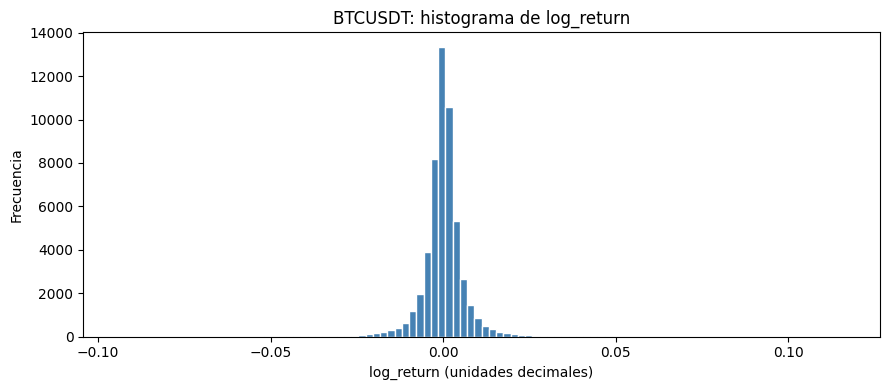

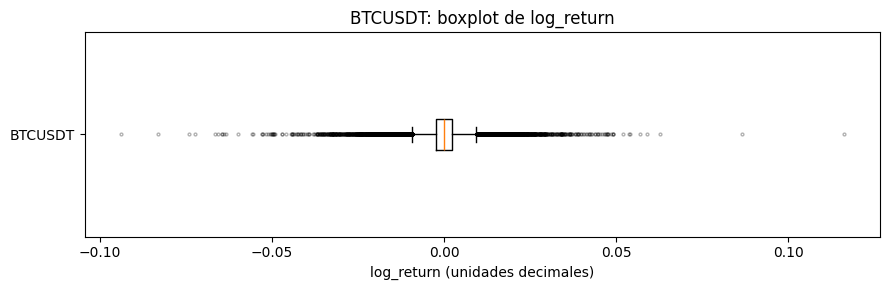

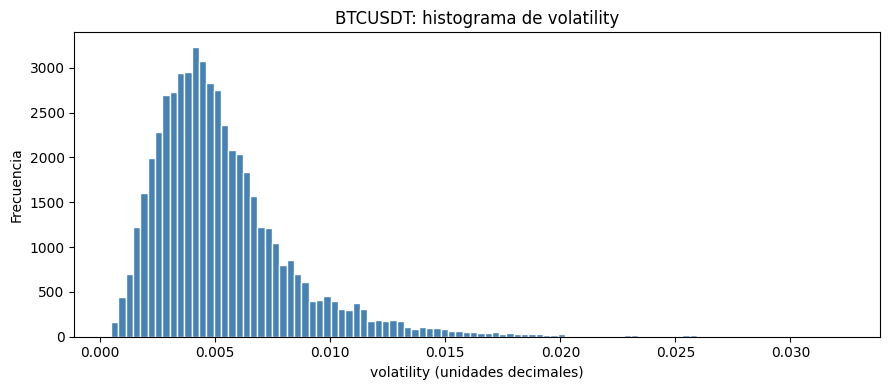

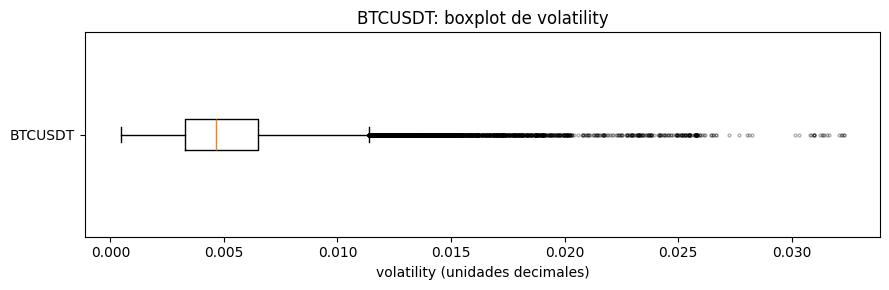

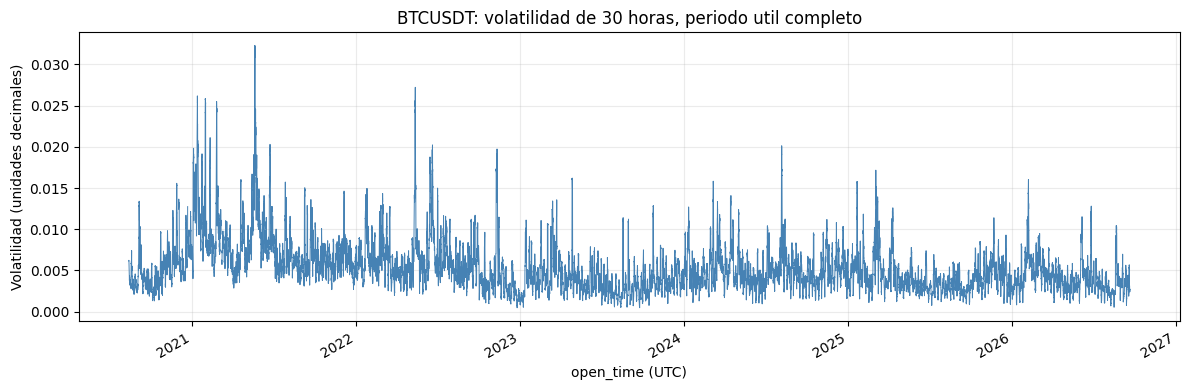

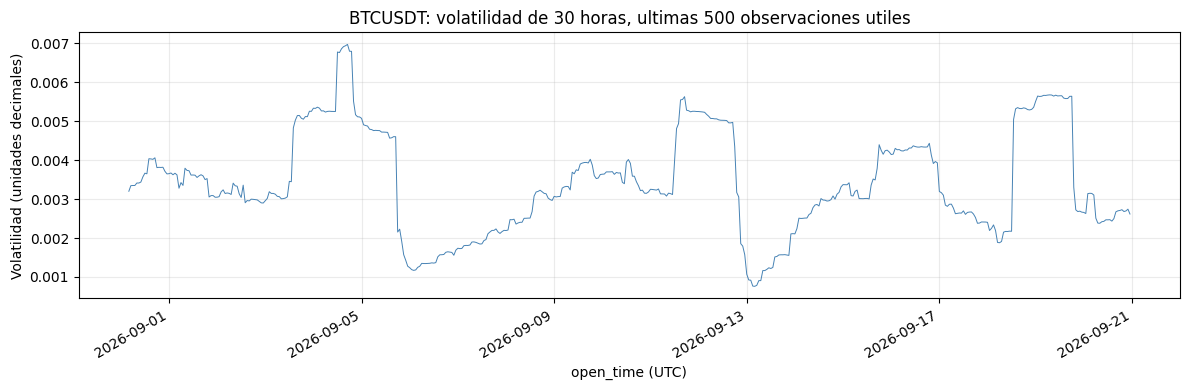

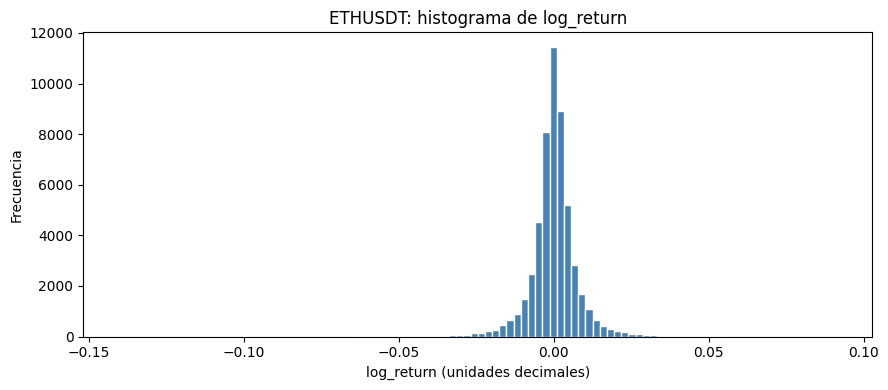

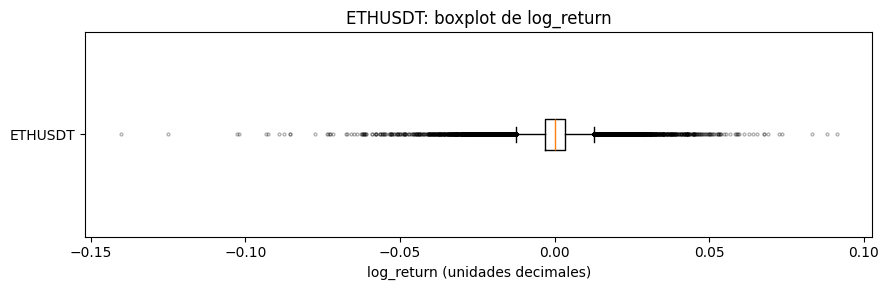

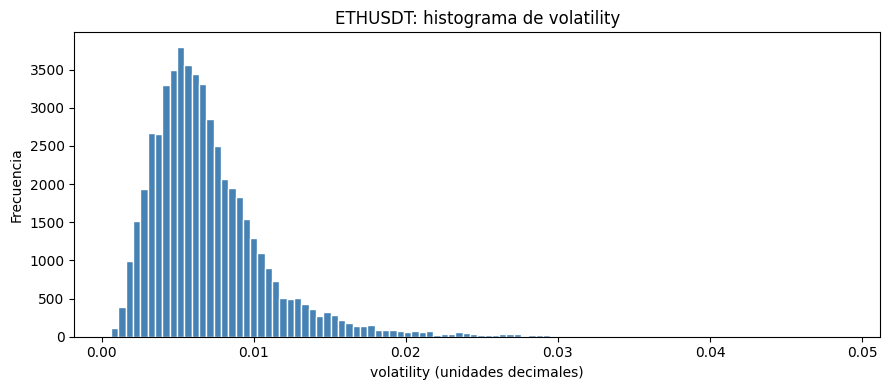

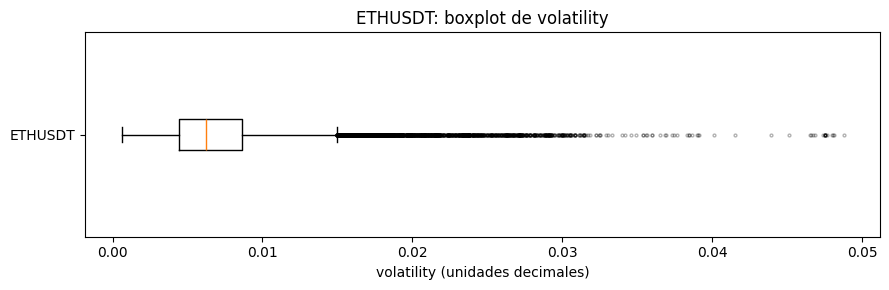

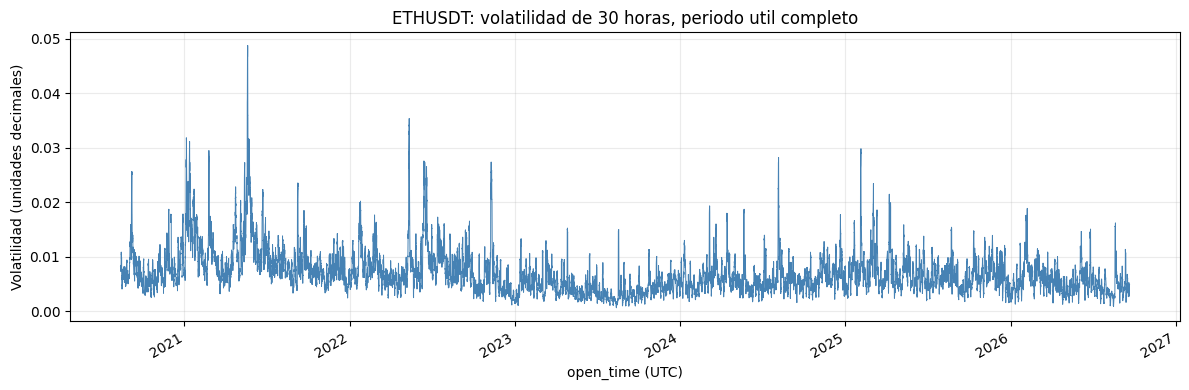

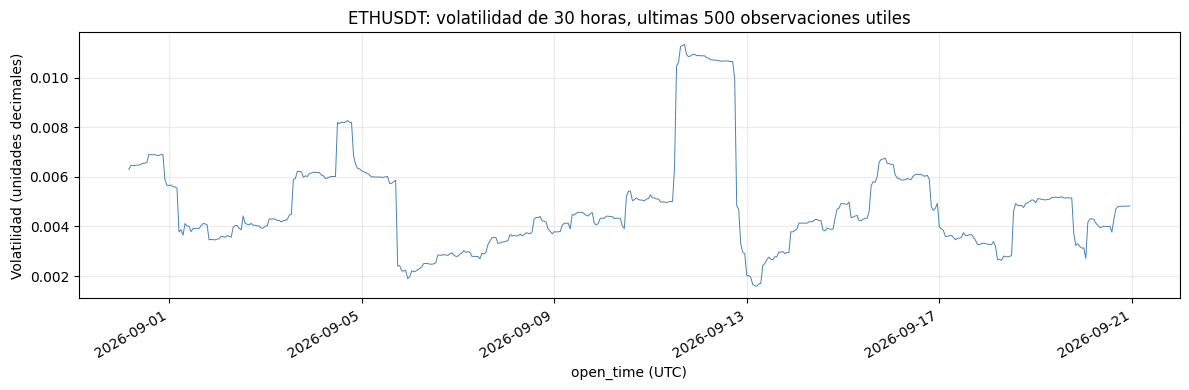

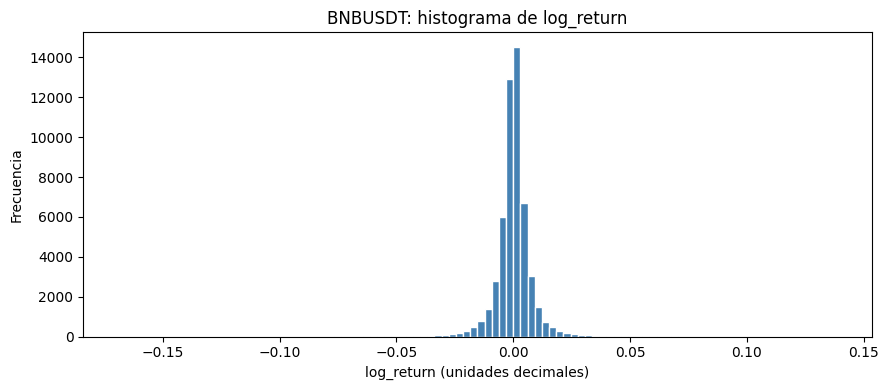

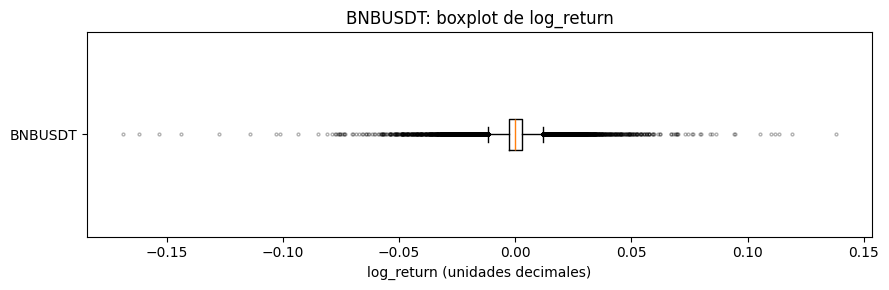

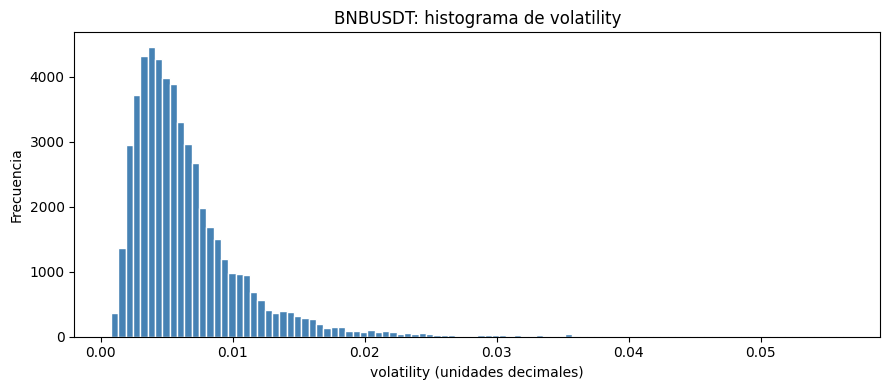

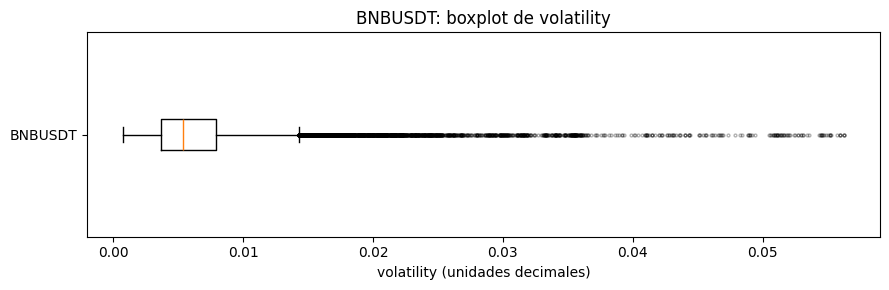

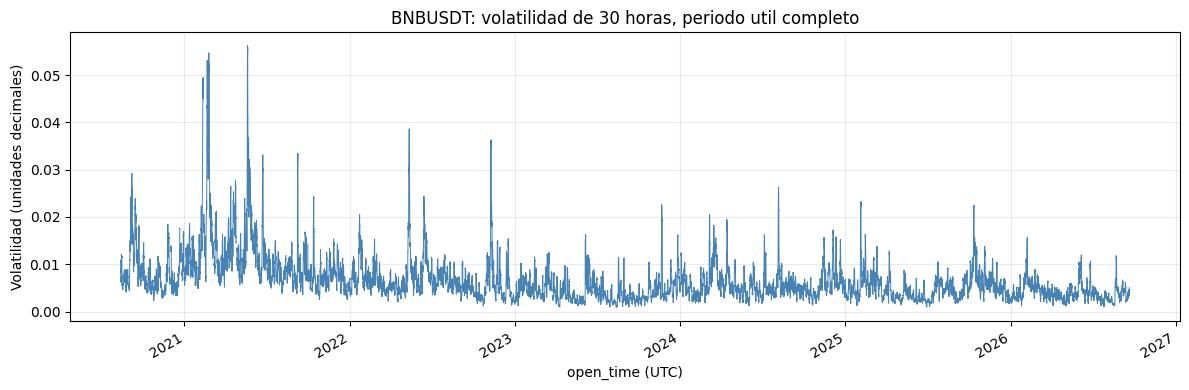

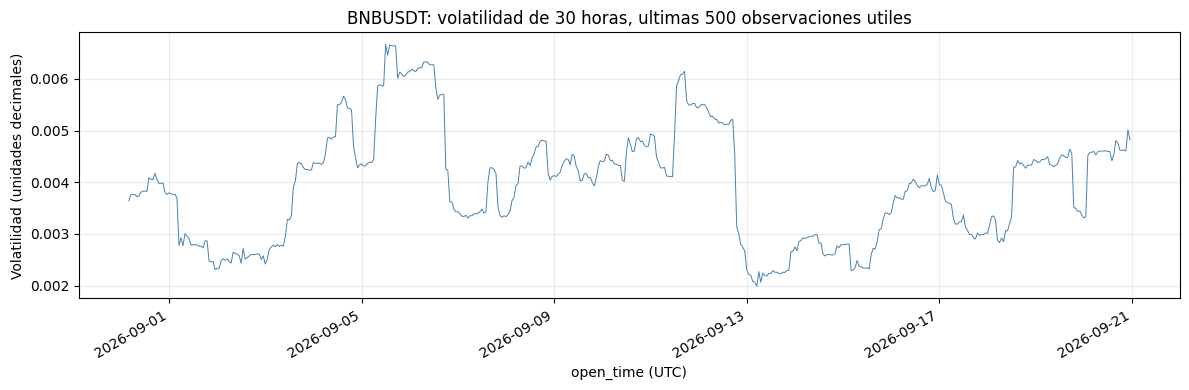

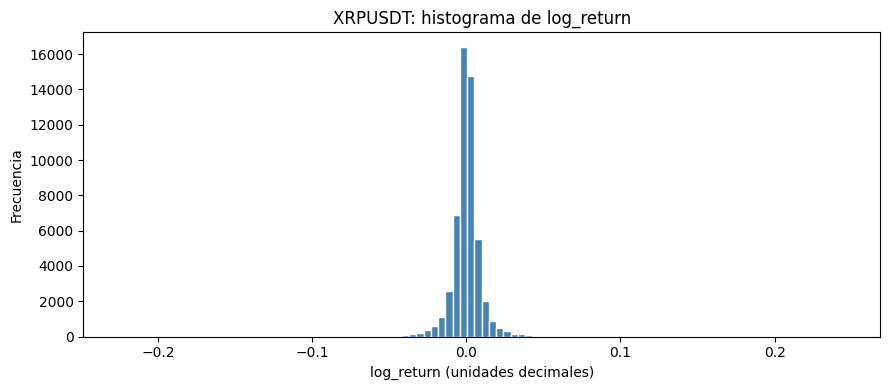

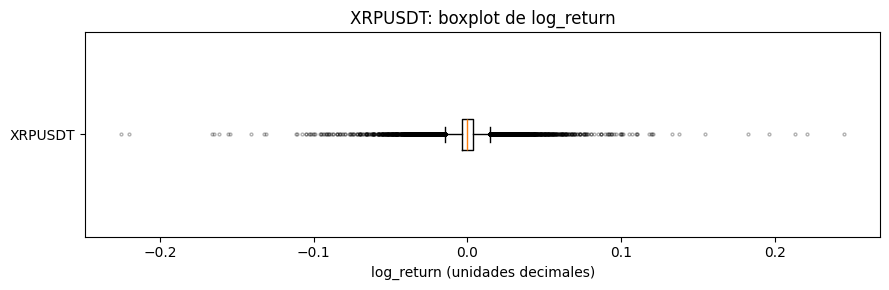

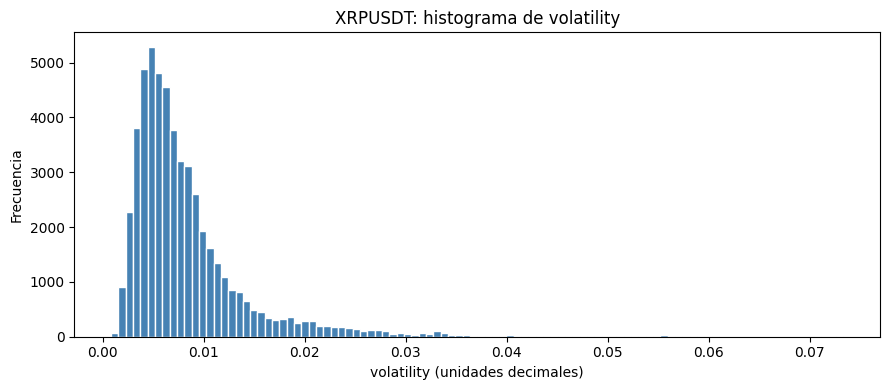

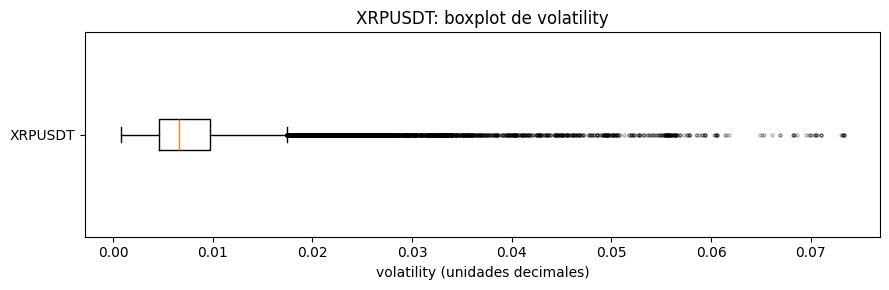

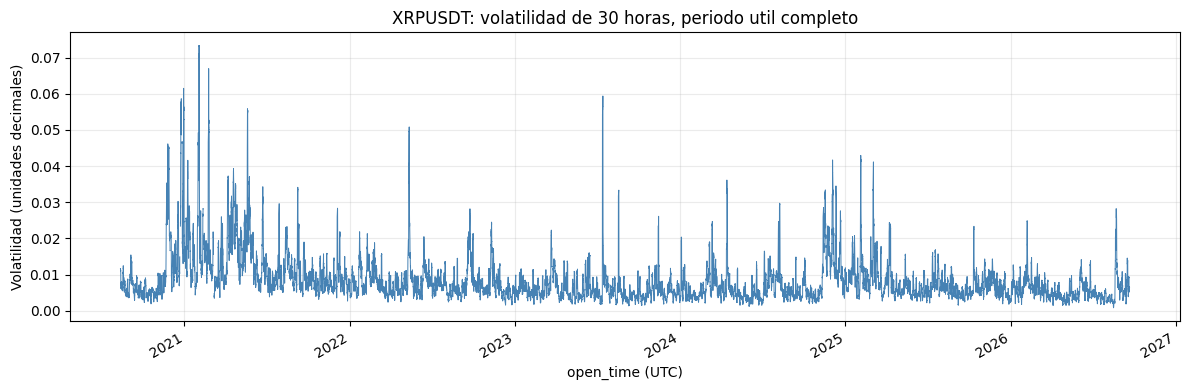

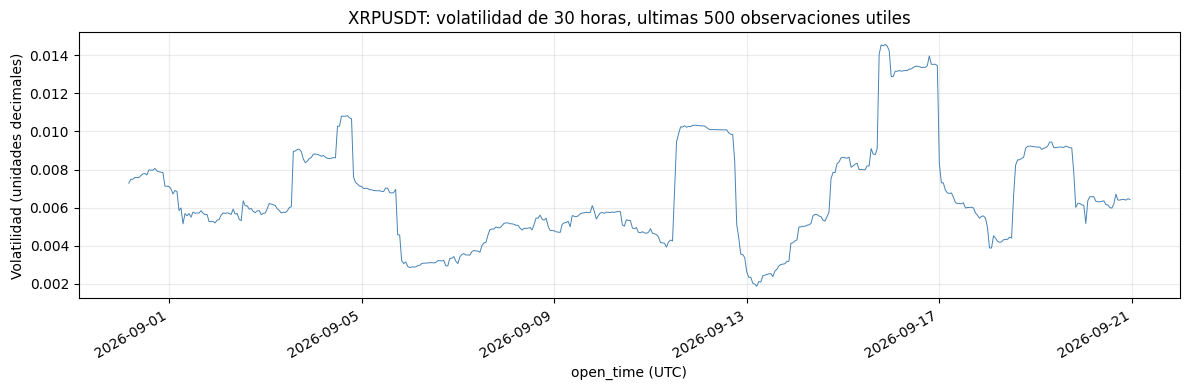

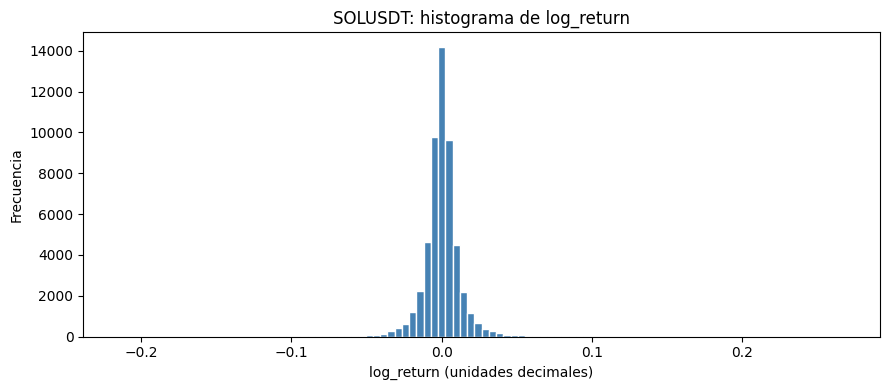

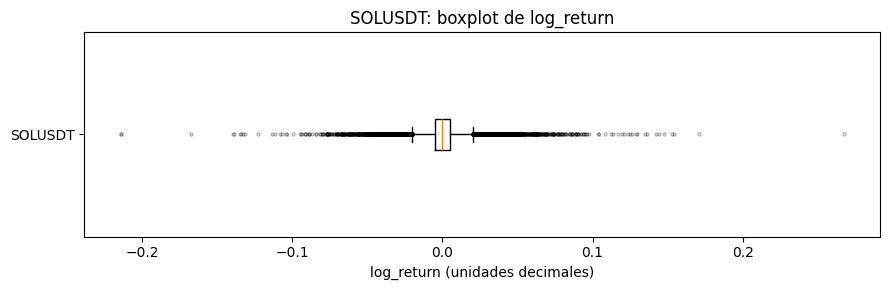

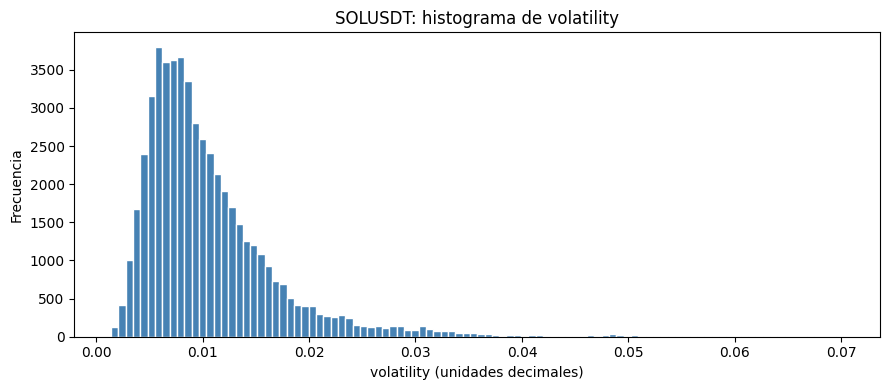

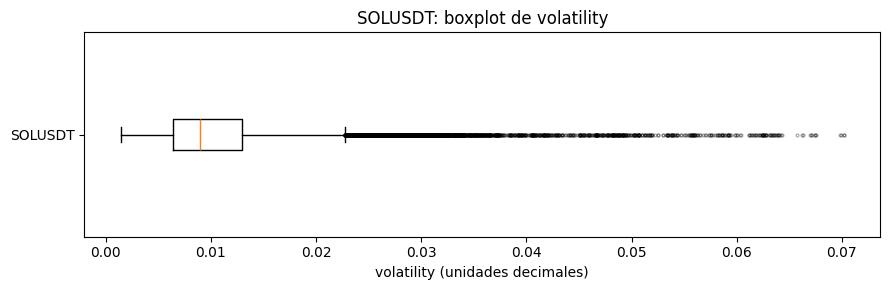

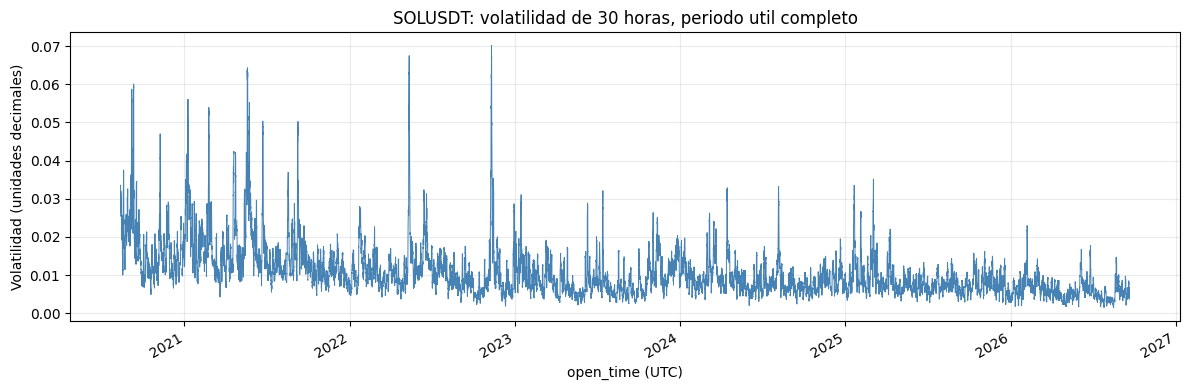

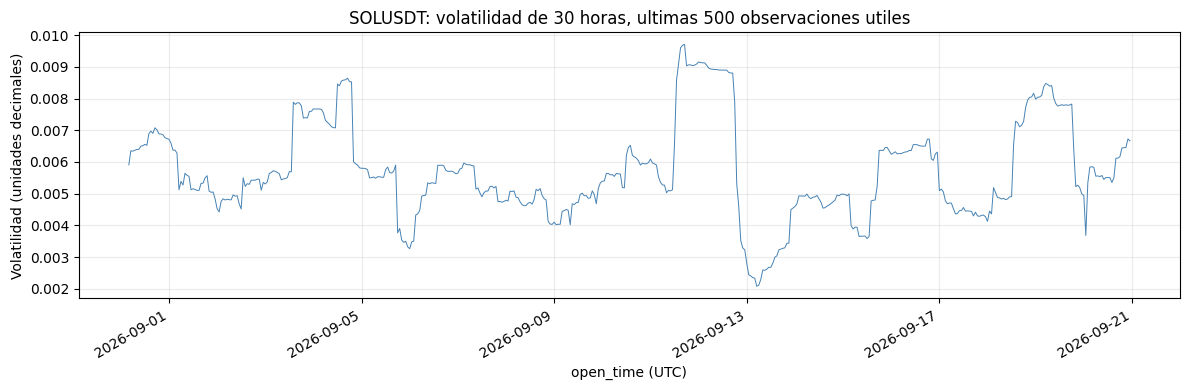

In [7]:
FIGURES_DIR = Path("notebooks/figs")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
eda_figure_paths = []

def save_eda_figure(fig, filename):
    fig.tight_layout()
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    eda_figure_paths.append(path)
    plt.show()
    plt.close(fig)

for symbol in SYMBOLS:
    asset = eda_data.loc[eda_data.symbol.eq(symbol)].sort_values("open_time")
    for variable in ["log_return", "volatility"]:
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.hist(asset[variable], bins=100, color="steelblue", edgecolor="white")
        ax.set(title=f"{symbol}: histograma de {variable}",
               xlabel=f"{variable} (unidades decimales)", ylabel="Frecuencia")
        save_eda_figure(fig, f"eda_{symbol}_{variable}_histogram.png")

        fig, ax = plt.subplots(figsize=(9, 3))
        ax.boxplot(asset[variable].to_numpy(), vert=False, showfliers=True,
                   flierprops={"markersize": 2, "alpha": .3})
        ax.set(title=f"{symbol}: boxplot de {variable}",
               xlabel=f"{variable} (unidades decimales)", yticks=[1], yticklabels=[symbol])
        save_eda_figure(fig, f"eda_{symbol}_{variable}_boxplot.png")

    for suffix, view, title in [
        ("full", asset, "periodo util completo"),
        ("last500", asset.tail(500), "ultimas 500 observaciones utiles"),
    ]:
        fig, ax = plt.subplots(figsize=(12, 4))
        for _, segment in view.groupby("segment_id", sort=False):
            ax.plot(segment.open_time, segment.volatility,
                    color="steelblue", linewidth=.7)
        ax.set(title=f"{symbol}: volatilidad de 30 horas, {title}",
               xlabel="open_time (UTC)", ylabel="Volatilidad (unidades decimales)")
        ax.grid(alpha=.25)
        fig.autofmt_xdate()
        save_eda_figure(fig, f"eda_{symbol}_volatility_time_{suffix}.png")


### 2.4.1 Autocorrelación hasta 48 horas

Para cada activo calculamos la ACF de `log_return`, `log_return` al cuadrado y `volatility`. Como existen discontinuidades, solo incluimos productos de observaciones pertenecientes al mismo segmento continuo:

$$\widehat\rho(k)=\frac{\sum_s\sum_{t=k+1}^{n_s}(x_{s,t}-\bar x)(x_{s,t-k}-\bar x)}{\sum_s\sum_{t=1}^{n_s}(x_{s,t}-\bar x)^2},\qquad k=0,\ldots,48.$$

Aqui $s$ identifica un segmento y $\bar x$ es la media de la variable para ese activo en el conjunto util. Es la ACF con denominador fijo (sin ajuste por el numero de pares), extendida a segmentos; no concatenamos extremos separados por huecos. Cada rezago representa horas consecutivas y se reporta el numero de pares utilizados. No se presentan bandas de significancia basadas en el supuesto de observaciones independientes.

La persistencia de una volatilidad movil incluye un efecto mecanico: ventanas consecutivas de 30 retornos comparten 29 observaciones. Por ello tambien examinamos los retornos al cuadrado y los rezagos superiores a la ventana.

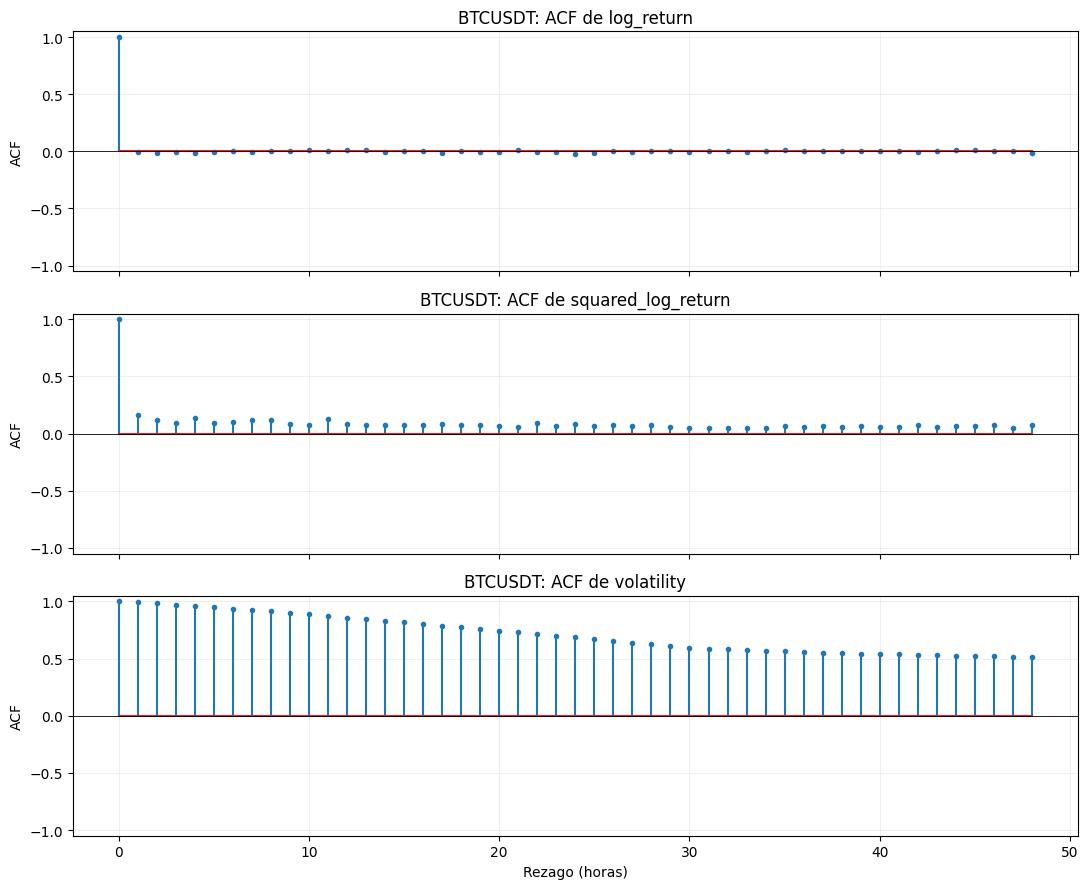

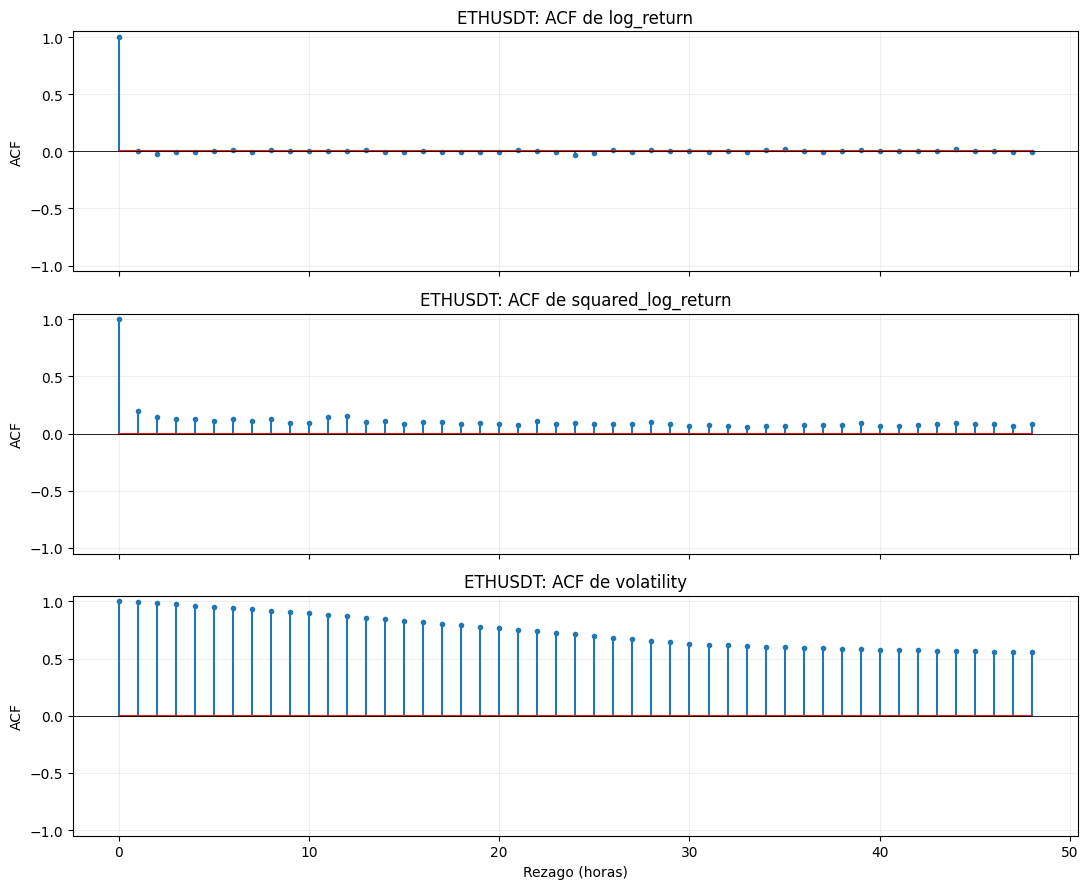

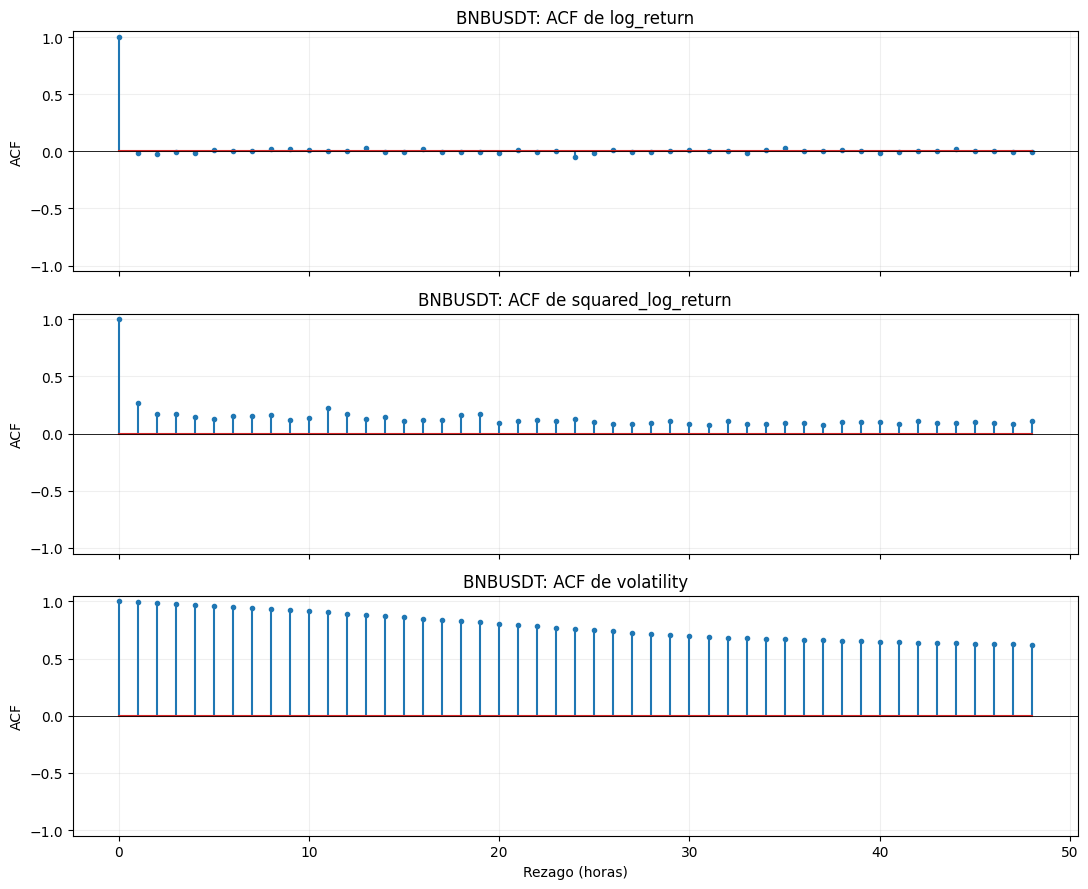

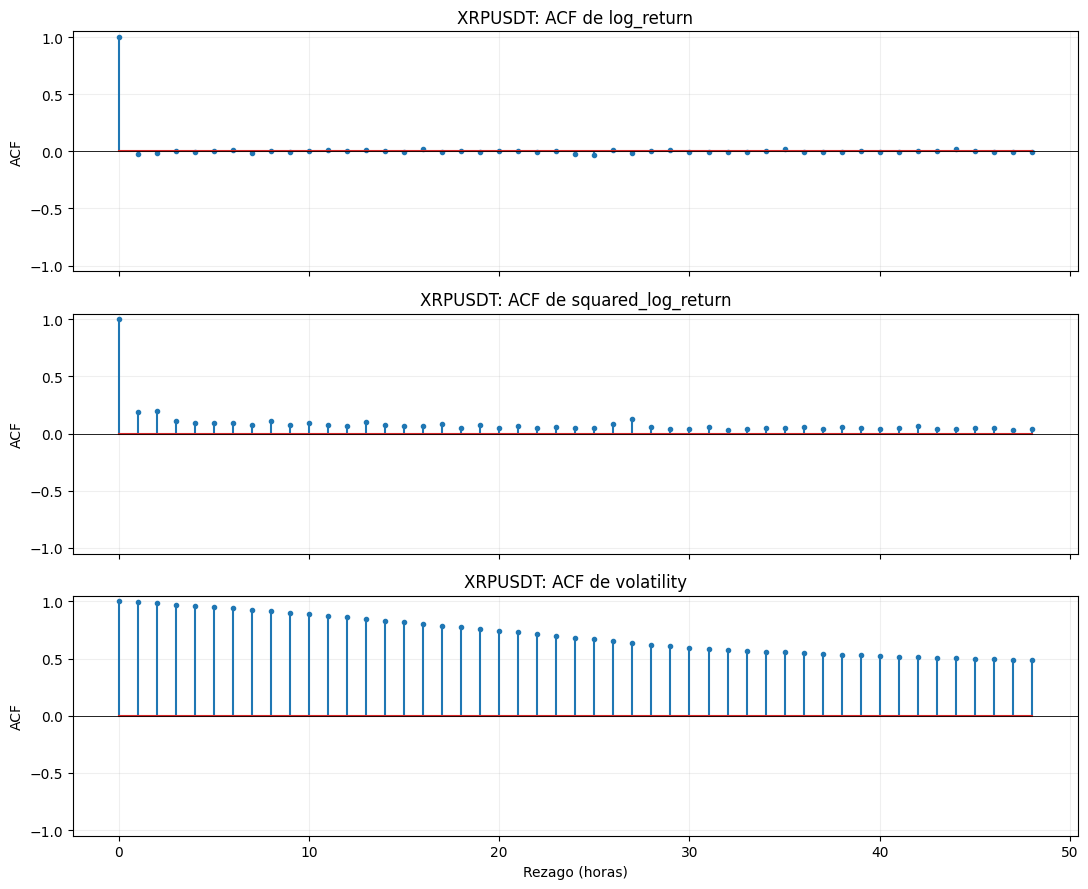

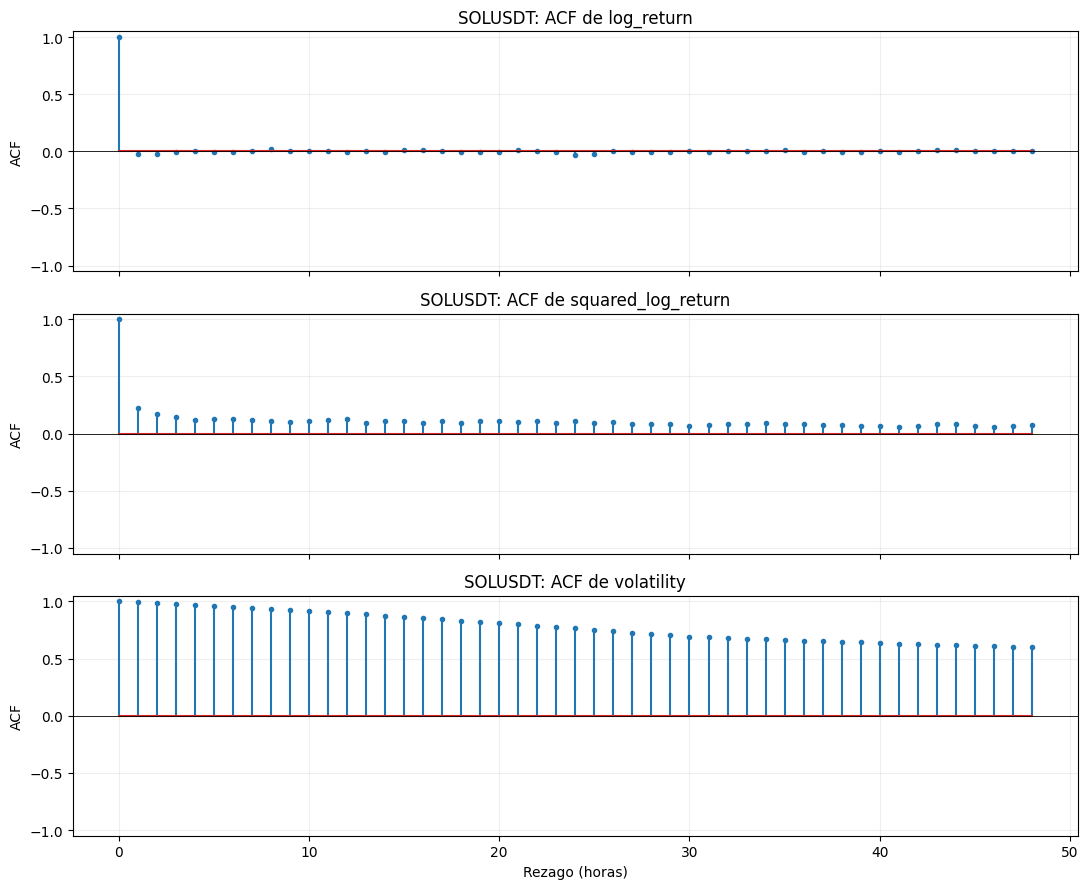

ACF de volatility en rezagos seleccionados:


lag,1,6,12,24,48
symbol,,,,,
BTCUSDT,0.992150,0.937496,0.858923,0.685541,0.512702
ETHUSDT,0.992646,0.942985,0.871116,0.711353,0.553773
BNBUSDT,0.994176,0.953842,0.894428,0.760582,0.620270
XRPUSDT,0.992395,0.938520,0.859920,0.683044,0.483882
SOLUSDT,0.994264,0.954372,0.896972,0.764200,0.601369


ACF completa y numero de pares por activo y variable (rezagos 0 a 48):
BTCUSDT


acf                                    pairs  \
variable log_return squared_log_return volatility log_return   
lag                                                            
0          1.000000           1.000000   1.000000    53212.0   
1         -0.009137           0.159496   0.992150    53201.0   
2         -0.013118           0.121566   0.982552    53190.0   
3         -0.001490           0.092039   0.972054    53179.0   
4         -0.013528           0.132635   0.960995    53168.0   
5         -0.002265           0.092607   0.949397    53157.0   
6          0.006546           0.103249   0.937496    53146.0   
7         -0.007176           0.117155   0.925245    53135.0   
8          0.006779           0.118241   0.912591    53124.0   
9          0.005783           0.080222   0.899525    53113.0   
10         0.008074           0.073354   0.886228    53102.0   
11         0.006826           0.127295   0.872770    53091.0   
12         0.010912           0.083692   0.858923    53080.0   
13         0.012958           0.076921   0.844967    53069.0   
14        -0.009809           0.073533   0.830837    53058.0   
15        -0.001273           0.073211   0.816625    53047.0   
16         0.005250           0.073026   0.802381    53036.0   
17        -0.013332           0.080030   0.788053    53025.0   
18         0.005947           0.073524   0.773606    53014.0   
19        -0.008206           0.075167   0.759159    53003.0   
20        -0.002088           0.066180   0.744688    52992.0   
21         0.007647           0.057917   0.730150    52981.0   
22        -0.003405           0.092043   0.715460    52970.0   
23        -0.006951           0.065446   0.700549    52959.0   
24        -0.023383           0.083325   0.685541    52948.0   
25        -0.015098           0.066563   0.670212    52937.0   
26        -0.000675           0.074164   0.654704    52926.0   
27        -0.006481           0.061609   0.639196    52915.0   
28         0.006628           0.076800   0.623749    52904.0   
29        -0.000114           0.059908   0.608542    52893.0   
30        -0.002617           0.049345   0.594075    52882.0   
31        -0.000562           0.052641   0.586583    52871.0   
32         0.004768           0.050474   0.580041    52860.0   
33        -0.007317           0.049507   0.573990    52849.0   
34        -0.000477           0.051563   0.568263    52838.0   
35         0.012921           0.065488   0.562861    52827.0   
36         0.006408           0.060428   0.557701    52816.0   
37         0.002678           0.070001   0.552843    52805.0   
38         0.002396           0.054473   0.548188    52794.0   
39         0.000764           0.066829   0.543917    52783.0   
40        -0.000056           0.053351   0.539869    52772.0   
41         0.004059           0.054333   0.536018    52761.0   
42        -0.002993           0.076354   0.532556    52750.0   
43         0.000647           0.060042   0.529162    52739.0   
44         0.014562           0.064707   0.525872    52728.0   
45         0.007421           0.065973   0.522600    52717.0   
46         0.002513           0.074386   0.519228    52706.0   
47        -0.001182           0.048618   0.515914    52695.0   
48        -0.012171           0.073622   0.512702    52684.0   

                                        
variable squared_log_return volatility  
lag                                     
0                   53212.0    53212.0  
1                   53201.0    53201.0  
2                   53190.0    53190.0  
3                   53179.0    53179.0  
4                   53168.0    53168.0  
5                   53157.0    53157.0  
6                   53146.0    53146.0  
7                   53135.0    53135.0  
8                   53124.0    53124.0  
9                   53113.0    53113.0  
10                  53102.0    53102.0  
11                  53091.0    53091.0  
12                  53080.0    53080.0  
13                  53069.0    

ETHUSDT


...

XRPUSDT


acf                                    pairs  \
variable log_return squared_log_return volatility log_return   
lag                                                            
0          1.000000           1.000000   1.000000    53212.0   
1         -0.019988           0.184699   0.992395    53201.0   
2         -0.018593           0.196273   0.983115    53190.0   
3          0.001222           0.106419   0.972679    53179.0   
4         -0.010178           0.095176   0.961676    53168.0   
5          0.001472           0.089200   0.950315    53157.0   
6          0.014165           0.095441   0.938520    53146.0   
7         -0.010678           0.077440   0.926312    53135.0   
8          0.006051           0.105726   0.913750    53124.0   
9         -0.003917           0.076937   0.900728    53113.0   
10         0.002059           0.096203   0.887451    53102.0   
11         0.007448           0.071899   0.873760    53091.0   
12         0.006316           0.067869   0.859920    53080.0   
13         0.010806           0.102432   0.845893    53069.0   
14        -0.000268           0.076455   0.831689    53058.0   
15        -0.004805           0.068985   0.817279    53047.0   
16         0.017469           0.068665   0.802714    53036.0   
17        -0.002663           0.080826   0.788151    53025.0   
18         0.005502           0.049784   0.773356    53014.0   
19        -0.001754           0.074705   0.758558    53003.0   
20         0.002826           0.050771   0.743482    52992.0   
21         0.005002           0.069486   0.728489    52981.0   
22        -0.004340           0.048245   0.713418    52970.0   
23        -0.000924           0.058678   0.698305    52959.0   
24        -0.026721           0.052216   0.683044    52948.0   
25        -0.029206           0.044712   0.667763    52937.0   
26         0.008937           0.081287   0.652584    52926.0   
27        -0.013194           0.122977   0.637398    52915.0   
28         0.006753           0.057582   0.621962    52904.0   
29         0.007690           0.042644   0.606788    52893.0   
30        -0.004093           0.040632   0.592349    52882.0   
31        -0.003207           0.056586   0.583484    52871.0   
32        -0.003422           0.034554   0.575393    52860.0   
33        -0.009686           0.036312   0.568019    52849.0   
34         0.003470           0.047934   0.561001    52838.0   
35         0.016383           0.046332   0.554223    52827.0   
36        -0.005610           0.053661   0.547578    52816.0   
37        -0.005140           0.039758   0.541218    52805.0   
38        -0.008447           0.056440   0.535112    52794.0   
39         0.005354           0.052356   0.529272    52783.0   
40        -0.005495           0.041073   0.523512    52772.0   
41        -0.003444           0.049220   0.518064    52761.0   
42         0.005099           0.061609   0.512707    52750.0   
43        -0.000004           0.039793   0.507375    52739.0   
44         0.016853           0.041174   0.502361    52728.0   
45         0.005162           0.049549   0.497485    52717.0   
46        -0.003386           0.049571   0.492718    52706.0   
47        -0.005970           0.027357   0.488103    52695.0   
48        -0.007872           0.038177   0.483882    52684.0   

                                        
variable squared_log_return volatility  
lag                                     
0                   53212.0    53212.0  
1                   53201.0    53201.0  
2                   53190.0    53190.0  
3                   53179.0    53179.0  
4                   53168.0    53168.0  
5                   53157.0    53157.0  
6                   53146.0    53146.0  
7                   53135.0    53135.0  
8                   53124.0    53124.0  
9                   53113.0    53113.0  
10                  53102.0    53102.0  
11                  53091.0    53091.0  
12                  53080.0    53080.0  
13                  53069.0    

SOLUSDT


acf                                    pairs  \
variable log_return squared_log_return volatility log_return   
lag                                                            
0          1.000000           1.000000   1.000000    53212.0   
1         -0.023500           0.225848   0.994264    53201.0   
2         -0.023919           0.169729   0.987346    53190.0   
3         -0.004818           0.141887   0.979705    53179.0   
4          0.003482           0.114764   0.971526    53168.0   
5         -0.007364           0.129183   0.963111    53157.0   
6         -0.007609           0.124660   0.954372    53146.0   
7         -0.001015           0.122379   0.945337    53135.0   
8          0.017640           0.107665   0.936000    53124.0   
9         -0.000757           0.101229   0.926555    53113.0   
10         0.002233           0.108703   0.916884    53102.0   
11         0.007085           0.117972   0.907042    53091.0   
12        -0.008725           0.130037   0.896972    53080.0   
13         0.003481           0.095444   0.886650    53069.0   
14        -0.005118           0.106036   0.876178    53058.0   
15         0.007825           0.113109   0.865508    53047.0   
16         0.013863           0.094592   0.854654    53036.0   
17         0.001690           0.108076   0.843670    53025.0   
18        -0.008158           0.094398   0.832516    53014.0   
19        -0.006343           0.106041   0.821408    53003.0   
20        -0.003493           0.109744   0.810253    52992.0   
21         0.013741           0.101082   0.798966    52981.0   
22         0.004434           0.111946   0.787608    52970.0   
23        -0.003928           0.094140   0.775953    52959.0   
24        -0.030517           0.113619   0.764200    52948.0   
25        -0.019364           0.088317   0.752205    52937.0   
26         0.002713           0.097510   0.740117    52926.0   
27        -0.006979           0.081376   0.727876    52915.0   
28        -0.004771           0.082328   0.715719    52904.0   
29        -0.009593           0.087716   0.703814    52893.0   
30        -0.001329           0.064443   0.692358    52882.0   
31        -0.002474           0.072583   0.685751    52871.0   
32         0.005379           0.080298   0.679650    52860.0   
33         0.001460           0.081277   0.673793    52849.0   
34        -0.000394           0.090339   0.668176    52838.0   
35         0.014888           0.081217   0.662538    52827.0   
36        -0.001954           0.086484   0.657077    52816.0   
37         0.004228           0.073177   0.651716    52805.0   
38        -0.002869           0.072605   0.646528    52794.0   
39        -0.003767           0.065329   0.641424    52783.0   
40         0.004550           0.063099   0.636461    52772.0   
41        -0.007615           0.061138   0.631624    52761.0   
42         0.004504           0.065955   0.626963    52750.0   
43         0.014619           0.082327   0.622428    52739.0   
44         0.009082           0.085438   0.618008    52728.0   
45         0.001819           0.064879   0.613664    52717.0   
46         0.001658           0.061250   0.609432    52706.0   
47         0.002981           0.066412   0.605369    52695.0   
48         0.004985           0.077604   0.601369    52684.0   

                                        
variable squared_log_return volatility  
lag                                     
0                   53212.0    53212.0  
1                   53201.0    53201.0  
2                   53190.0    53190.0  
3                   53179.0    53179.0  
4                   53168.0    53168.0  
5                   53157.0    53157.0  
6                   53146.0    53146.0  
7                   53135.0    53135.0  
8                   53124.0    53124.0  
9                   53113.0    53113.0  
10                  53102.0    53102.0  
11                  53091.0    53091.0  
12                  53080.0    53080.0  
13                  53069.0    

Figuras generadas: 35


In [8]:
ACF_MAX_LAG = 48
ACF_REPORT_LAGS = [1, 6, 12, 24, 48]

def segmented_acf(frame, variable, max_lag=48):
    mean = frame[variable].mean()
    segments = [g[variable].to_numpy(dtype=float) - mean
                for _, g in frame.groupby("segment_id", sort=False)]
    denominator = sum(np.dot(x, x) for x in segments)
    assert denominator > 0, "ACF no definida para una serie constante"
    values, pairs = [], []
    for lag in range(max_lag + 1):
        if lag == 0:
            values.append(1.0)
            pairs.append(sum(len(x) for x in segments))
        else:
            count = sum(max(len(x) - lag, 0) for x in segments)
            numerator = sum(np.dot(x[lag:], x[:-lag])
                            for x in segments if len(x) > lag)
            values.append(numerator / denominator if count else np.nan)
            pairs.append(count)
    return np.asarray(values), np.asarray(pairs)

acf_rows = []
for symbol in SYMBOLS:
    asset = eda_data.loc[eda_data.symbol.eq(symbol)].copy()
    asset["squared_log_return"] = asset.log_return.pow(2)
    for _, segment in asset.groupby("segment_id"):
        assert segment.open_time.diff().dropna().eq(pd.Timedelta(hours=1)).all()
    fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
    for ax, variable in zip(axes, ["log_return", "squared_log_return", "volatility"]):
        values, pairs = segmented_acf(asset, variable, ACF_MAX_LAG)
        for lag, value, count in zip(range(ACF_MAX_LAG + 1), values, pairs):
            acf_rows.append({"symbol": symbol, "variable": variable,
                             "lag": lag, "acf": value, "pairs": count})
        ax.stem(range(ACF_MAX_LAG + 1), values, markerfmt=".")
        ax.axhline(0, color="black", linewidth=.6)
        ax.set(title=f"{symbol}: ACF de {variable}", ylabel="ACF", ylim=(-1.05, 1.05))
        ax.grid(alpha=.2)
    axes[-1].set_xlabel("Rezago (horas)")
    save_eda_figure(fig, f"eda_{symbol}_acf_returns_squared_returns_volatility_48h.png")

eda_acf = pd.DataFrame(acf_rows)
volatility_acf_summary = (
    eda_acf.loc[eda_acf.variable.eq("volatility") & eda_acf.lag.isin(ACF_REPORT_LAGS)]
    .pivot(index="symbol", columns="lag", values="acf").reindex(SYMBOLS)
)
print("ACF de volatility en rezagos seleccionados:")
display(volatility_acf_summary)
print("ACF completa y numero de pares por activo y variable (rezagos 0 a 48):")
for symbol in SYMBOLS:
    print(symbol)
    display(eda_acf.loc[eda_acf.symbol.eq(symbol)]
            .pivot(index="lag", columns="variable", values=["acf", "pairs"]))
print("Figuras generadas:", len(eda_figure_paths))
assert len(eda_figure_paths) == 35
assert all(path.is_file() and path.stat().st_size > 0 for path in eda_figure_paths)


### 2.4.2 Interpretación de los resultados

**Retornos cerca de cero.** Las medias horarias van de 0,0000236 (XRP) a 0,0000604 (SOL), frente a desviaciones estándar de 0,00619 a 0,01273. La media es inferior al 0,8% de la desviación estándar en cada activo: los retornos parecen centrados cerca de cero en terminos descriptivos, sin que esto constituya una prueba formal de media poblacional nula.

**Colas pesadas y asimetria.** El exceso de curtosis es BTC 16,12; ETH 14,63; BNB 30,16; XRP 44,41; SOL 20,26. Estos valores elevados son compatibles con colas pesadas frente a una normal y extremos, conservados en histogramas y boxplots. XRP presenta el mayor exceso de curtosis. La asimetria es negativa para BTC (-0,22), ETH (-0,51) y BNB (-0,52), y positiva para XRP (0,19) y SOL (0,28). Estas medidas describen la muestra y no identifican por si solas una distribucion teorica.

**Diferencias entre activos.** La volatilidad media aumenta en el orden BTC (0,00534), BNB (0,00659), ETH (0,00705), XRP (0,00845) y SOL (0,01071). SOL tiene aproximadamente el doble de volatilidad media que BTC. La media supera a la mediana en los cinco activos, consistente con distribuciones extendidas hacia valores altos. XRP registra el mayor maximo de volatilidad (0,07333), seguido de SOL (0,07019); BTC tiene el menor (0,03230). Los precios nominales de `close` estan en USDT por unidad y no permiten comparar directamente el riesgo entre activos.

**Persistencia temporal.** La ACF de `volatility` al rezago 1 esta entre 0,992 y 0,994; al rezago 24, entre 0,683 y 0,764; y al rezago 48, entre 0,484 y 0,620. BNB (0,620) y SOL (0,601) presentan mayor persistencia a 48 horas, y XRP la menor (0,484). Parte de la dependencia de corto plazo es mecanica: las ventanas consecutivas comparten 29 de 30 retornos. A 48 horas ya no hay ese solapamiento directo; la asociacion es compatible con persistencia mas alla de la ventana, aunque tambien puede reflejar cambios de regimen durante el periodo completo.

**Clustering de volatilidad.** Las curvas temporales muestran episodios elevados alternando con periodos mas tranquilos. SOL presenta repuntes repetidos en la primera parte de la muestra y episodios posteriores; la vista de las ultimas 500 observaciones de BTC permite distinguir bloques de volatilidad alta y baja. La ACF de los retornos al cuadrado es positiva al rezago 1 (0,159 a 0,269) y permanece positiva a 48 horas (0,038 a 0,110). Esta evidencia adicional es compatible con agrupamiento temporal de la magnitud de los retornos y no depende de aplicar un rolling a los retornos al cuadrado. No constituye por si sola una prueba formal de un modelo de volatilidad.

**Correlaciones contemporaneas.** La correlacion entre `abs(log_return)` y `volatility` es BTC 0,443; ETH 0,455; BNB 0,528; XRP 0,497; SOL 0,497. Para los retornos al cuadrado oscila entre 0,300 y 0,355. Estas asociaciones positivas moderadas incluyen el efecto de que el retorno actual participa en la construccion de la volatilidad; no implican causalidad ni capacidad predictiva.

Las comparaciones utilizan las 53.212 observaciones utiles por activo y respetan los segmentos continuos. No se han realizado escalamiento, folds ni entrenamiento del MLP.

## 2.5 Auditoría de Fuga de Datos (Data Leakage)

Se define t como el cierre de la última vela observada: aunque `open_time` identifica su apertura, el precio `close` solo está disponible al terminar esa vela.

| Variable | Disponible en t | Utiliza futuro | Riesgo de fuga | Decisión |
|---|---|---|---|---|
| `close` | Sí, al cierre de la vela | No | Usarlo antes del cierre | Solo construye retornos; no entra directamente al MLP |
| `log_return` | Sí, con cierre actual y anterior | No | Cruzar discontinuidades | Calcular dentro de símbolo y segmento |
| `volatility` | Sí, con 30 retornos hasta t | No | Usar rolling centrado o futuro | Rolling retrospectivo de 30 horas |
| `segment_id` | Sí, con el salto respecto a la observación anterior | No | Concatenar segmentos | Identificador de continuidad, no predictor |
| Lags de `volatility` | Sí | No | Incluir observaciones posteriores a t | Solo pasado en X |
| Target `volatility t+1 ... t+7` | No | Sí | Incorporarlo a X o al ajuste del scaler de otro conjunto | Exclusivamente en y; ajuste de scaler_y solo con y_train |

X utiliza solamente pasado y los targets futuros aparecen únicamente en y. No existe shuffle. Los dos `StandardScaler` se ajustan solo con train. Train ocurre antes de validation y validation antes de test, considerando toda la extensión X+y. Ninguna ventana cruza `segment_id`; la purga elimina solapamientos en las fronteras entre conjuntos. La partición nativa de timeseries-cv fue diagnosticada y adaptada cronológicamente para evitar leakage, como documenta el apartado 3.1 de [modelado](model_base.ipynb).

La elección retrospectiva de la ventana por TEST permanece como limitación: ese conjunto no es una evaluación independiente posterior a la selección. Esta auditoría documenta las medidas existentes y no modifica la validación.


## 2.6 Componente Temporal

### 2.6.1 Variable temporal

`open_time` está en UTC y la frecuencia nominal es 1h. El período solicitado es 2020-01-01 a 2026-09-20; el período común va de 2020-08-11 06:00 a 2026-09-20 23:00 UTC. Tras el calentamiento del rolling, la primera observación útil es 2020-08-12 12:00 UTC. El apartado 2.2 conserva la auditoría de cero duplicados `symbol/open_time`, 10 huecos por activo y 11 segmentos. `delta_h` identifica las separaciones distintas de una hora y `segment_id` delimita continuidad; no se imputan horas ausentes.

### 2.6.2 Dependencia temporal

Las figuras y tablas del apartado 2.4.1 ya muestran ACF de `log_return`, `log_return` al cuadrado y `volatility`, hasta 48 rezagos, respetando segmentos. Se conservan allí sin duplicarlas. La interpretación del apartado 2.4.2 distingue dependencia de los retornos y de su magnitud.

### 2.6.3 Persistencia de la volatilidad

Las series muestran clustering: episodios de alta volatilidad alternan con períodos tranquilos. La ACF guardada de volatilidad es 0,992–0,994 en h=1 y 0,484–0,620 en h=48. Parte de la alta autocorrelación inmediata se relaciona con el solapamiento de 29 de los 30 retornos de ventanas consecutivas. La persistencia a 48 horas y la ACF positiva de retornos al cuadrado aportan evidencia descriptiva adicional, sin demostrar causalidad o estabilidad de régimen.

### 2.6.4 Consecuencias para el modelado

La dependencia temporal motiva una partición cronológica sin shuffle, entradas construidas solo con pasado y dentro de `segment_id`, purga en las fronteras y escalamiento ajustado exclusivamente con train. Los cinco folds expansivos incorporan progresivamente historia. Estas decisiones ya están implementadas y no se alteran con el EDA complementario.


### 2.6.5 Estacionalidad horaria y semanal

EDA descriptivo nuevo sobre las 53.212 observaciones útiles por activo: mediana de `volatility` por hora de `open_time` UTC y por día de la semana. Las magnitudes están en unidades decimales, sin anualizar. Se mantienen las observaciones disponibles y no se imputan huecos. Los perfiles agregan regímenes y años distintos; no prueban una estacionalidad determinista ni una oportunidad predictiva. No se incorporan hora o día al MLP.

**Mediana por hora UTC**

| Hora | BTCUSDT | ETHUSDT | BNBUSDT | XRPUSDT | SOLUSDT |
| --- | --- | --- | --- | --- | --- |
| 0 | 0.00467257 | 0.00623321 | 0.00538439 | 0.00665831 | 0.00896375 |
| 1 | 0.00467131 | 0.00629288 | 0.00543664 | 0.00663678 | 0.00898227 |
| 2 | 0.00462548 | 0.00621304 | 0.00542079 | 0.00662622 | 0.00892852 |
| 3 | 0.00458910 | 0.00619958 | 0.00543891 | 0.00658239 | 0.00891834 |
| 4 | 0.00457280 | 0.00614486 | 0.00536888 | 0.00656990 | 0.00891229 |
| 5 | 0.00452342 | 0.00606002 | 0.00535849 | 0.00657296 | 0.00887854 |
| 6 | 0.00451488 | 0.00599202 | 0.00529791 | 0.00647610 | 0.00875010 |
| 7 | 0.00447447 | 0.00598157 | 0.00526857 | 0.00644381 | 0.00863634 |
| 8 | 0.00448784 | 0.00600089 | 0.00528906 | 0.00645994 | 0.00860264 |
| 9 | 0.00451000 | 0.00601495 | 0.00530384 | 0.00647482 | 0.00865903 |
| 10 | 0.00451976 | 0.00600967 | 0.00529416 | 0.00651870 | 0.00870281 |
| 11 | 0.00452046 | 0.00603558 | 0.00529704 | 0.00654368 | 0.00869458 |
| 12 | 0.00456637 | 0.00607925 | 0.00537452 | 0.00654018 | 0.00869110 |
| 13 | 0.00463144 | 0.00616070 | 0.00541517 | 0.00659892 | 0.00882479 |
| 14 | 0.00476734 | 0.00629724 | 0.00546113 | 0.00669428 | 0.00889793 |
| 15 | 0.00484319 | 0.00634962 | 0.00550496 | 0.00676260 | 0.00905031 |
| 16 | 0.00487328 | 0.00643112 | 0.00553346 | 0.00679643 | 0.00918567 |
| 17 | 0.00491674 | 0.00646730 | 0.00557081 | 0.00684646 | 0.00922051 |
| 18 | 0.00492683 | 0.00650726 | 0.00552893 | 0.00690603 | 0.00920495 |
| 19 | 0.00488529 | 0.00646809 | 0.00549092 | 0.00683775 | 0.00922735 |
| 20 | 0.00480985 | 0.00635170 | 0.00541975 | 0.00676930 | 0.00916938 |
| 21 | 0.00478598 | 0.00629602 | 0.00536385 | 0.00672705 | 0.00907078 |
| 22 | 0.00474581 | 0.00628674 | 0.00535672 | 0.00669863 | 0.00905346 |
| 23 | 0.00466494 | 0.00620933 | 0.00532611 | 0.00661429 | 0.00891774 |

**Mediana por día UTC**

| Día | BTCUSDT | ETHUSDT | BNBUSDT | XRPUSDT | SOLUSDT |
| --- | --- | --- | --- | --- | --- |
| Lunes | 0.00444077 | 0.00583041 | 0.00526782 | 0.00660217 | 0.00859451 |
| Martes | 0.00514951 | 0.00673483 | 0.00585586 | 0.00726807 | 0.00939744 |
| Miércoles | 0.00513759 | 0.00671540 | 0.00563833 | 0.00691312 | 0.00934793 |
| Jueves | 0.00520809 | 0.00680909 | 0.00576915 | 0.00673473 | 0.00979345 |
| Viernes | 0.00503519 | 0.00680073 | 0.00580776 | 0.00710190 | 0.00959020 |
| Sábado | 0.00437710 | 0.00583254 | 0.00506384 | 0.00647360 | 0.00878561 |
| Domingo | 0.00297362 | 0.00441868 | 0.00414639 | 0.00493752 | 0.00689364 |

**Lectura descriptiva:** las medianas horarias mínimas aparecen a las 07:00 UTC en BTC, ETH, BNB y XRP, y a las 08:00 en SOL; las máximas se sitúan entre las 17:00 y las 19:00 UTC. El domingo tiene la menor mediana semanal en los cinco activos. Estos perfiles agregados no separan efectos de régimen, calendario o composición muestral y no se usan para modificar el MLP.


### 2.6.6 Estacionariedad

Se ejecutaron ADF y KPSS exclusivamente como EDA. Para evitar concatenar huecos se tomó, por activo, el segmento continuo útil de mayor tamaño (empate: menor identificador). No se submuestreó ese segmento. Este diagnóstico describe ese intervalo, no todo el período ni cada régimen.

| Activo | Segmento | n | Inicio UTC | Fin UTC |
| --- | --- | --- | --- | --- |
| BNBUSDT | 10 | 30604 | 2023-03-25 20:00:00+00:00 | 2026-09-20 23:00:00+00:00 |
| BTCUSDT | 10 | 30604 | 2023-03-25 20:00:00+00:00 | 2026-09-20 23:00:00+00:00 |
| ETHUSDT | 10 | 30604 | 2023-03-25 20:00:00+00:00 | 2026-09-20 23:00:00+00:00 |
| SOLUSDT | 10 | 30604 | 2023-03-25 20:00:00+00:00 | 2026-09-20 23:00:00+00:00 |
| XRPUSDT | 10 | 30604 | 2023-03-25 20:00:00+00:00 | 2026-09-20 23:00:00+00:00 |

ADF usa constante, 48 rezagos fijos y `autolag=None`; su H0 es raíz unitaria. KPSS usa constante y `nlags="auto"`; su H0 es estacionariedad alrededor de una media constante. Los parámetros son explícitos y no se seleccionaron para favorecer un resultado. Véanse [ADF](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html) y [KPSS](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.kpss.html).

| Activo | Variable | ADF statistic | ADF p-value | KPSS statistic | KPSS p-value | Rezagos KPSS |
| --- | --- | --- | --- | --- | --- | --- |
| BNBUSDT | log_return | -25.792600 | 0 | 0.098004 | > 0.10 | 16 |
| BNBUSDT | volatility | -13.318077 | 6.54184e-25 | 0.808042 | < 0.01 | 99 |
| BTCUSDT | log_return | -24.615885 | 0 | 0.263769 | > 0.10 | 3 |
| BTCUSDT | volatility | -14.711360 | 2.84416e-27 | 0.812765 | < 0.01 | 99 |
| ETHUSDT | log_return | -24.692531 | 0 | 0.082916 | > 0.10 | 7 |
| ETHUSDT | volatility | -13.457144 | 3.58878e-25 | 3.255716 | < 0.01 | 99 |
| SOLUSDT | log_return | -25.140879 | 0 | 0.394381 | 0.0795773 | 5 |
| SOLUSDT | volatility | -12.553558 | 2.17918e-23 | 3.306774 | < 0.01 | 99 |
| XRPUSDT | log_return | -24.585216 | 0 | 0.154781 | > 0.10 | 19 |
| XRPUSDT | volatility | -13.490457 | 3.11361e-25 | 0.906100 | < 0.01 | 99 |

Los límites de p-value de KPSS se muestran como desigualdades cuando la rutina advierte que el estadístico queda fuera de su tabla; no se presentan como probabilidades exactas. Un valor numérico 0 en ADF indica precisión numérica, no probabilidad teórica exactamente nula. Al 5%, se rechaza la H0 de ADF cuando p < 0,05 y la de KPSS cuando p < 0,05. No rechazar una hipótesis no la demuestra. Con muestras grandes, colas pesadas, heterocedasticidad y posibles cambios de régimen, los resultados requieren cautela y no justifican modificar el target o diferenciar automáticamente las series.

| Activo | Variable | ADF al 5% | KPSS al 5% |
| --- | --- | --- | --- |
| BNBUSDT | log_return | Rechaza raíz unitaria | No rechaza estacionariedad |
| BNBUSDT | volatility | Rechaza raíz unitaria | Rechaza estacionariedad |
| BTCUSDT | log_return | Rechaza raíz unitaria | No rechaza estacionariedad |
| BTCUSDT | volatility | Rechaza raíz unitaria | Rechaza estacionariedad |
| ETHUSDT | log_return | Rechaza raíz unitaria | No rechaza estacionariedad |
| ETHUSDT | volatility | Rechaza raíz unitaria | Rechaza estacionariedad |
| SOLUSDT | log_return | Rechaza raíz unitaria | No rechaza estacionariedad |
| SOLUSDT | volatility | Rechaza raíz unitaria | Rechaza estacionariedad |
| XRPUSDT | log_return | Rechaza raíz unitaria | No rechaza estacionariedad |
| XRPUSDT | volatility | Rechaza raíz unitaria | Rechaza estacionariedad |

**Lectura conjunta:** ADF rechaza raíz unitaria en las diez series analizadas. KPSS no rechaza estacionariedad de los retornos, pero la rechaza para la volatilidad en los cinco activos. La combinación para volatilidad desaconseja concluir estacionariedad global a partir de ADF solamente. No se modifica la metodología por estos diagnósticos.

**Avisos del análisis:** KPSS produjo nueve avisos de p-values fuera del rango tabulado, reflejados mediante desigualdades. statsmodels 0.15.0 también emitió avisos sobre el cambio futuro del tipo de retorno de ADF/KPSS; no fueron errores de cálculo.


### 2.6.7 Autocorrelación parcial (PACF)

Se calculó la PACF de `log_return` y `volatility` hasta 48 rezagos sobre los mismos segmentos continuos de 2.6.6. Se usa Yule–Walker sin ajuste por tamaño (`method="ywm"`), documentado en [statsmodels PACF](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.pacf.html). Las tablas muestran todos los rezagos 1–48; h=0 vale 1 por definición. La PACF describe la asociación lineal restante al controlar los rezagos intermedios, sin identificar causalidad ni seleccionar nuevas ventanas.

**log_return**

| Rezago | BTCUSDT | ETHUSDT | BNBUSDT | XRPUSDT | SOLUSDT |
| --- | --- | --- | --- | --- | --- |
| 1 | -0.020355 | -0.001274 | -0.019962 | -0.008692 | -0.023204 |
| 2 | -0.000850 | -0.003674 | -0.009789 | -0.002584 | -0.018847 |
| 3 | -0.004388 | 0.007198 | -0.017408 | -0.012794 | -0.003015 |
| 4 | 0.006534 | 0.009782 | 0.008374 | 0.010522 | -0.000943 |
| 5 | -0.004649 | 0.008433 | 0.003840 | 0.000438 | -0.004509 |
| 6 | -0.002184 | -0.000513 | -0.005656 | -0.004740 | -0.002278 |
| 7 | -0.002493 | -0.005508 | -0.001068 | -0.007841 | 0.007687 |
| 8 | 0.004557 | 0.003752 | -0.002755 | -0.004910 | 0.002848 |
| 9 | 0.004721 | -0.003719 | -0.005587 | -0.007341 | -0.000118 |
| 10 | -0.001534 | 0.002088 | -0.000397 | 0.005216 | 0.000902 |
| 11 | -0.003863 | 0.001347 | -0.000700 | -0.012520 | -0.006262 |
| 12 | 0.005381 | 0.007762 | 0.000815 | 0.008437 | 0.006339 |
| 13 | 0.002764 | 0.006235 | 0.001531 | 0.013564 | 0.012097 |
| 14 | -0.010987 | -0.008274 | -0.000387 | 0.007983 | -0.005337 |
| 15 | 0.006148 | 0.001894 | 0.003722 | -0.009848 | -0.003523 |
| 16 | 0.000522 | -0.000914 | -0.001853 | 0.014489 | 0.003515 |
| 17 | 0.006897 | 0.007502 | 0.012833 | 0.014163 | 0.002295 |
| 18 | 0.006805 | -0.001263 | -0.007378 | 0.004825 | 0.008382 |
| 19 | -0.003258 | -0.009859 | -0.004586 | 0.003832 | -0.000151 |
| 20 | -0.006449 | -0.009122 | -0.010961 | 0.010133 | 0.001569 |
| 21 | -0.000569 | -0.015299 | -0.001069 | 0.003728 | 0.007365 |
| 22 | -0.028686 | -0.026176 | -0.003756 | -0.014123 | -0.019069 |
| 23 | -0.019259 | -0.010594 | -0.006976 | -0.020264 | -0.016312 |
| 24 | -0.013445 | -0.017915 | -0.023215 | -0.024355 | -0.018854 |
| 25 | 0.003121 | 0.014047 | 0.007530 | -0.014044 | 0.001847 |
| 26 | 0.006070 | 0.018881 | 0.003447 | 0.006423 | 0.013491 |
| 27 | -0.002375 | 0.000772 | 0.001070 | -0.000506 | 0.000410 |
| 28 | -0.000283 | 0.009298 | 0.004377 | -0.002962 | -0.011494 |
| 29 | -0.013176 | -0.008669 | -0.007768 | -0.009824 | -0.003874 |
| 30 | 0.003953 | 0.003553 | -0.002190 | -0.003437 | -0.007711 |
| 31 | 0.004256 | 0.003681 | 0.001118 | 0.006931 | -0.000563 |
| 32 | -0.002061 | 0.002806 | 0.004912 | 0.004742 | 0.009773 |
| 33 | 0.004705 | 0.006067 | -0.001188 | -0.001940 | 0.003483 |
| 34 | 0.008328 | 0.011469 | 0.018885 | 0.006856 | -0.002224 |
| 35 | 0.007922 | 0.007406 | 0.003293 | 0.006985 | 0.005994 |
| 36 | 0.012005 | 0.002507 | -0.003056 | -0.002206 | 0.008772 |
| 37 | -0.002925 | -0.001433 | 0.008181 | -0.009618 | 0.004695 |
| 38 | 0.000781 | 0.000855 | -0.005876 | -0.003920 | -0.010486 |
| 39 | -0.001123 | -0.001397 | -0.017005 | 0.012035 | -0.010193 |
| 40 | 0.001001 | -0.000771 | -0.014880 | -0.002740 | 0.001393 |
| 41 | 0.008341 | 0.004766 | -0.001761 | 0.003170 | 0.000066 |
| 42 | 0.002087 | 0.004867 | -0.005432 | -0.001350 | -0.001071 |
| 43 | 0.006296 | 0.009154 | 0.008550 | 0.004186 | 0.002126 |
| 44 | 0.007366 | 0.010020 | 0.007828 | 0.015164 | 0.007287 |
| 45 | 0.002578 | -0.000820 | -0.006253 | 0.008705 | -0.000087 |
| 46 | -0.001701 | 0.001562 | 0.003564 | -0.002438 | 0.005341 |
| 47 | -0.001528 | -0.005768 | 0.001211 | -0.005381 | 0.000887 |
| 48 | -0.006634 | -0.017828 | -0.013467 | -0.005028 | -0.006434 |

**volatility**

| Rezago | BTCUSDT | ETHUSDT | BNBUSDT | XRPUSDT | SOLUSDT |
| --- | --- | --- | --- | --- | --- |
| 1 | 0.989679 | 0.988846 | 0.992029 | 0.991341 | 0.991403 |
| 2 | -0.144081 | -0.109477 | -0.118287 | -0.150845 | -0.111115 |
| 3 | -0.062627 | -0.059862 | -0.062214 | -0.102479 | -0.052492 |
| 4 | -0.042611 | -0.029834 | -0.036927 | -0.012942 | -0.036450 |
| 5 | -0.031124 | -0.031755 | -0.044494 | -0.024209 | -0.027672 |
| 6 | -0.024822 | -0.027519 | -0.040295 | -0.029924 | -0.033395 |
| 7 | -0.023684 | -0.025420 | -0.027965 | -0.020040 | -0.014629 |
| 8 | -0.042462 | -0.033600 | -0.030407 | -0.018519 | -0.024166 |
| 9 | -0.015752 | -0.015878 | -0.014324 | -0.017255 | -0.004890 |
| 10 | -0.014680 | -0.019639 | -0.027792 | -0.024765 | -0.036619 |
| 11 | -0.016016 | -0.008926 | -0.020349 | -0.019850 | -0.012541 |
| 12 | -0.026302 | -0.013518 | -0.021716 | -0.002492 | -0.014277 |
| 13 | -0.021394 | -0.023928 | -0.016064 | -0.016781 | -0.015683 |
| 14 | -0.021014 | -0.020842 | -0.022776 | -0.015668 | -0.028266 |
| 15 | -0.026602 | -0.019989 | -0.027323 | -0.015321 | -0.021118 |
| 16 | -0.011196 | -0.010147 | -0.021930 | -0.016666 | -0.007712 |
| 17 | -0.013182 | -0.010073 | 0.001892 | -0.012455 | -0.007095 |
| 18 | -0.017607 | -0.018126 | -0.003646 | -0.022227 | -0.011869 |
| 19 | -0.004977 | -0.003926 | -0.009031 | -0.008518 | -0.012614 |
| 20 | -0.009198 | -0.005541 | -0.003681 | -0.026950 | -0.005294 |
| 21 | -0.020188 | -0.020008 | -0.011965 | -0.000881 | -0.013696 |
| 22 | -0.028250 | -0.013505 | -0.009047 | -0.018612 | -0.011982 |
| 23 | -0.033438 | -0.032532 | -0.022296 | -0.023250 | -0.037864 |
| 24 | -0.024233 | -0.011740 | -0.006397 | -0.016825 | -0.013252 |
| 25 | -0.043691 | -0.032021 | -0.034857 | -0.025387 | -0.031570 |
| 26 | -0.024644 | -0.024007 | -0.007222 | -0.011130 | -0.016617 |
| 27 | -0.016378 | -0.014522 | 0.001706 | -0.018867 | -0.015895 |
| 28 | -0.007906 | -0.011164 | 0.003414 | -0.016961 | -0.004034 |
| 29 | 0.004208 | 0.007994 | 0.007153 | 0.019583 | 0.002528 |
| 30 | 0.041751 | 0.029771 | 0.027949 | 0.031550 | 0.034222 |
| 31 | 0.454472 | 0.454272 | 0.456095 | 0.432019 | 0.453763 |
| 32 | -0.050118 | -0.039751 | -0.048037 | -0.032158 | -0.043752 |
| 33 | -0.012046 | -0.007645 | -0.016234 | -0.011410 | -0.016896 |
| 34 | -0.013533 | -0.009916 | -0.021593 | -0.020571 | -0.015492 |
| 35 | -0.013515 | -0.005587 | -0.018655 | -0.013088 | -0.021200 |
| 36 | -0.007281 | -0.010652 | -0.008329 | -0.011488 | -0.002596 |
| 37 | -0.009833 | -0.004151 | -0.010731 | -0.005663 | -0.012468 |
| 38 | -0.010108 | -0.011655 | -0.023283 | -0.004522 | 0.000650 |
| 39 | 0.000693 | 0.003640 | -0.007747 | -0.006146 | 0.005951 |
| 40 | 0.002494 | -0.005893 | -0.013797 | -0.011435 | -0.010685 |
| 41 | 0.003113 | -0.005255 | -0.002052 | -0.010699 | -0.000760 |
| 42 | 0.005418 | 0.012341 | 0.003684 | 0.000283 | 0.009160 |
| 43 | 0.000344 | 0.004124 | -0.008963 | -0.011667 | -0.006997 |
| 44 | -0.001913 | -0.007577 | -0.009530 | -0.001838 | -0.008770 |
| 45 | -0.009114 | -0.014086 | -0.002317 | -0.010003 | -0.011840 |
| 46 | -0.012742 | -0.005363 | -0.006380 | -0.011387 | -0.005689 |
| 47 | -0.003288 | -0.002773 | -0.017395 | -0.001775 | -0.008245 |
| 48 | -0.018951 | -0.005650 | -0.027409 | -0.005403 | -0.005472 |

No se usan estos resultados para cambiar las ventanas 7/14/21/28. No se aplican bandas i.i.d. como prueba formal a estas series dependientes.

### Descomposición STL

**No se utiliza como componente central.**

La volatilidad financiera presenta clustering y cambios de régimen y no necesariamente una estacionalidad determinista estable. El análisis temporal se apoya principalmente en ACF/PACF, perfiles temporales y estadísticas descriptivas.

### Reproducibilidad del EDA complementario

Se leyó la caché existente y se reconstruyeron en memoria las transformaciones ya definidas, sin descargar, guardar CSV, generar figuras ni entrenar modelos. El script `scripts/eda_supplement.py` imprime los resultados en JSON y no escribe archivos. Sus tablas se incorporan aquí como nuevas celdas Markdown. Las ACF y figuras anteriores conservan sus resultados originales.

Entorno de este complemento (distinto del entorno original del maestro):

| Componente | Versión |
| --- | --- |
| python | 3.13.5 |
| numpy | 2.5.3 |
| pandas | 3.0.6 |
| scipy | 1.18.1 |
| statsmodels | 0.15.0 |

**Lectura de la PACF:** para los retornos, los valores absolutos de los rezagos 1–48 son inferiores a 0,03 en este segmento. La volatilidad presenta PACF de primer orden entre 0,989 y 0,992 y dependencia parcial adicional. Son descripciones de las tablas, no pruebas de ausencia de dependencia o criterios para cambiar la arquitectura.


## 2.7 Componente Espacial

**No aplica.**

El dataset corresponde a instrumentos financieros y no contiene latitud, longitud, coordenadas geográficas ni unidades espaciales. Por lo tanto no son pertinentes CRS, mapas, distancias geográficas, índice de Moran, LISA, KDE espacial, semivariogramas ni validación por bloques espaciales. El símbolo de una criptomoneda no constituye una coordenada o vecindad geográfica. No se inventan coordenadas ni se ejecuta análisis espacial.


## 2.8 Componente Espacio-Temporal

**No aplica.**

El dataset posee dimensión temporal pero no dimensión espacial. Por ello no son pertinentes mapas por período, hotspots espaciales, autocorrelación espacio-temporal, prueba de Knox ni partición por bloques espacio-temporales.


## 2.9 Preprocesamiento

Se documenta el flujo existente: orden por símbolo y fecha, restricción al período común, identificación de `segment_id`, cálculo de `log_return` y `volatility` rolling de 30 horas dentro de cada segmento, y eliminación determinista de filas no utilizables por esos cálculos. No se imputan artificialmente horas ausentes ni se eliminan automáticamente outliers: las colas pesadas y los episodios extremos forman parte de la señal financiera.

La alta persistencia y los huecos observados motivan ventanas de entrada de 7/14/21/28, horizonte de salida 7 y respeto de continuidad. Las cinco particiones cronológicas expansivas y la purga evitan solapamientos entre conjuntos de un fold. No existe shuffle. Dos `StandardScaler` independientes por fold se ajustan exclusivamente con train; las predicciones se devuelven a escala original. Se conserva `RANDOM_STATE = 42`, usando `RANDOM_STATE + fold` para cada MLP. Los perfiles temporales, ADF/KPSS y PACF añadidos son descriptivos y no alteran ninguna decisión experimental.


# 3. Pronóstico de Volatilidad con MLP Multisalida

Las celdas 15–25 del maestro documentan el diagnóstico de timeseries-cv, su adaptación cronológica, los 100 modelos ya entrenados y la evaluación final. Este capítulo depende de las variables preparadas en el EDA; la reproducción integral del flujo está documentada en el notebook maestro.

Este capítulo reúne la construcción de ventanas, la adaptación temporal, el escalamiento, el entrenamiento multisalida y la evaluación ya ejecutados en `model_evaluation.ipynb`. Parte de la serie `df_volatility` preparada en el capítulo EDA y conserva el código y las salidas del notebook maestro.

Los resultados se publican desde las salidas guardadas; las celdas están marcadas para omitir su ejecución durante la compilación del libro. El flujo completo y su estado de ejecución se conservan en el notebook maestro.


## 3.1 Construcción de ventanas temporales y validación TimeSeries-CV

### Adaptación de la validación temporal

Se evaluo `split_train_val_test_groupKFold` de `tsxv.splitTrainValTest` tal como exige la metodologia, con la firma instalada `(sequence, numInputs, numOutputs, numJumps)` y la llamada posicional `split_train_val_test_groupKFold(time_series, w, 7, 1)`. El diagnóstico nativo con BTCUSDT y w=7 mostro que sus cinco particiones intercalaban temporalmente train, validation y test a lo largo de la serie; ademas, al operar por posiciones e ignorar `segment_id`, permitian ventanas sobre discontinuidades. No se utilizan esas particiones para entrenar ni para definir los conjuntos finales.

Por esa razon, se conservaron los parametros del problema y la generacion temporal, pero se impuso una particion cronologica de cinco folds para prevenir **information leakage**. Esta es una adaptacion explicita de la particion nativa, no una propiedad de los folds originales de tsxv. Se mantiene el import y una llamada diagnostica reproducible, separada de la construccion final.

### Ventanas supervisadas por segmento

Unicamente usamos la `volatility` limpia de `df_volatility`. Para cada símbolo y segmento continuo, ordenamos por `open_time` y construimos ventanas con salto 1:

$$X_t=[\sigma_{t-w+1},\ldots,\sigma_t],\qquad y_t=[\sigma_{t+1},\ldots,\sigma_{t+7}].$$

Los valores 7, 14, 21 y 28 son **tamaños de entrada**, no targets diferentes. Todos los experimentos predicen la misma volatilidad historica de 30 horas y siempre tienen un horizonte de **7 horas**. Cada ventana completa X+y permanece en un solo `segment_id` y sus observaciones son horarias consecutivas. Se ordenan las muestras por la fecha inicial del objetivo. El conteo de ventanas descartadas por huecos compara las posibles ventanas por posiciones de la serie concatenada con las construidas dentro de segmentos; estas ventanas invalidas nunca entran en los folds.

### Cinco folds con entrenamiento expansivo

Dividimos las ventanas válidas ordenadas en **siete bloques consecutivos de tamaños lo mas iguales posible**, sin shuffle. En el fold k (1 a 5), train contiene los primeros k bloques, validation el bloque k+1 y test el bloque k+2. Asi el entrenamiento incorpora mas historia en cada fold; cada test ocupa un bloque posterior distinto. El uso de bloques iguales en numero de muestras no implica duraciones calendario exactamente iguales cuando existen huecos.

Para una separacion temporal estricta, eliminamos del inicio de validation las muestras cuya entrada comience antes o al mismo tiempo que el ultimo objetivo de train. Aplicamos la misma regla a test respecto del ultimo objetivo de validation. Esta purga de fronteras es distinta del descarte por discontinuidades: impide que una ventana X+y cruce la frontera entre conjuntos. Validation y test son los siguientes bloques; no se introduce un embargo adicional.

Los campos `train_start`, `validation_start` y `test_start` representan la primera fecha de **X**, y los campos `*_end` la ultima fecha de **y**. Las comprobaciones `train_end < validation_start` y `validation_end < test_start` abarcan por tanto toda la muestra, no solo su fecha de referencia. Los conjuntos pueden compartir historia entre folds posteriores, como corresponde al esquema expansivo, pero nunca entre train/validation/test del mismo fold.

No se ajusta ningún escalador ni se entrena el MLP. Definir primero estos conjuntos evita ajustar transformaciones con informacion de validation o test; un futuro escalador debera ajustarse exclusivamente con train de su fold.

In [9]:
from tsxv.splitTrainValTest import split_train_val_test_groupKFold
from numpy.lib.stride_tricks import sliding_window_view

assert INPUT_WINDOWS == [7, 14, 21, 28]
assert N_STEPS_FORECAST == 7 and N_STEPS_JUMP == 1
N_TEMPORAL_FOLDS = 5

# Llamada nativa exclusivamente diagnostica; nunca define los folds finales.
time_series = (
    df_volatility.loc[df_volatility.symbol.eq("BTCUSDT")]
    .sort_values("open_time").volatility.to_numpy()[:256]
)
w = 7
native_diagnostic = split_train_val_test_groupKFold(time_series, w, 7, 1)
native_index_diagnostic = split_train_val_test_groupKFold(
    np.arange(len(time_series)), w, 7, 1
)
for values, positions in zip(native_diagnostic, native_index_diagnostic):
    for fold in values:
        np.testing.assert_array_equal(values[fold], time_series[positions[fold]])
assert len(native_diagnostic[0]) == 5
assert all(native_index_diagnostic[1][fold].max() >=
           native_index_diagnostic[3][fold].min() for fold in range(5))
print("Diagnostico confirmado: las particiones nativas no son cronologicas.")
del native_diagnostic, native_index_diagnostic


def build_segment_windows(asset, input_window):
    """Construye ventanas solo dentro de segmentos; conserva fechas e indices."""
    asset = asset.sort_values("open_time").reset_index(drop=True)
    length = input_window + N_STEPS_FORECAST
    starts_parts = []
    for _, segment in asset.groupby("segment_id", sort=False):
        assert segment.open_time.diff().dropna().eq(pd.Timedelta(hours=1)).all()
        positions = segment.index.to_numpy()
        assert np.all(np.diff(positions) == 1)
        if len(segment) >= length:
            starts_parts.append(positions[:len(segment)-length+1:N_STEPS_JUMP])
    assert starts_parts, "No hay suficientes observaciones por segmento"
    starts = np.concatenate(starts_parts)
    values = asset.volatility.to_numpy(dtype=float)
    # Solo se seleccionan inicios validos, nunca las ventanas sobre huecos.
    windows = sliding_window_view(values, length)[starts].copy()
    segments = asset.segment_id.to_numpy()
    assert np.all(sliding_window_view(segments, length)[starts] == segments[starts, None])
    metadata = pd.DataFrame({
        "segment_id": segments[starts],
        "start_position": starts,
        "input_start": asset.open_time.iloc[starts].array,
        "input_end": asset.open_time.iloc[starts+input_window-1].array,
        "target_start": asset.open_time.iloc[starts+input_window].array,
        "target_end": asset.open_time.iloc[starts+length-1].array,
    })
    order = metadata.target_start.argsort().to_numpy()
    metadata = metadata.iloc[order].reset_index(drop=True)
    windows = windows[order]
    assert metadata.target_start.is_monotonic_increasing
    assert metadata.target_start.is_unique
    assert (metadata.target_end-metadata.input_start).eq(pd.Timedelta(hours=length-1)).all()
    assert (metadata.target_start-metadata.input_end).eq(pd.Timedelta(hours=1)).all()
    assert np.isfinite(windows).all()
    n_naive = max(len(asset)-length+1, 0)
    n_crossing = n_naive-len(windows)
    return windows[:, :input_window], windows[:, input_window:], metadata, n_crossing


def expanding_temporal_indices(metadata):
    """Cinco folds, siete bloques y purga de ventanas en las fronteras."""
    blocks = np.array_split(np.arange(len(metadata)), N_TEMPORAL_FOLDS+2)
    folds = []
    for number in range(1, N_TEMPORAL_FOLDS+1):
        train = np.concatenate(blocks[:number])
        val_raw, test_raw = blocks[number], blocks[number+1]
        assert train.size and val_raw.size and test_raw.size
        train_end = metadata.iloc[train].target_end.max()
        val = val_raw[(metadata.iloc[val_raw].input_start > train_end).to_numpy()]
        assert val.size, "Validation vacio despues de purgar"
        validation_end = metadata.iloc[val].target_end.max()
        test = test_raw[(metadata.iloc[test_raw].input_start > validation_end).to_numpy()]
        assert test.size, "Test vacio despues de purgar"
        folds.append({"fold": number, "train": train, "validation": val, "test": test,
                      "purged_validation": len(val_raw)-len(val),
                      "purged_test": len(test_raw)-len(test)})
    return folds


Diagnostico confirmado: las particiones nativas no son cronologicas.


In [10]:
cv_datasets = {}
cv_rows = []
cv_shape_rows = []
window_audit_rows = []

for symbol in SYMBOLS:
    asset = df_volatility.loc[df_volatility.symbol.eq(symbol)].copy()
    for input_window in INPUT_WINDOWS:
        X, y, metadata, discarded = build_segment_windows(asset, input_window)
        assert X.shape == (len(metadata), input_window)
        assert y.shape == (len(metadata), N_STEPS_FORECAST)
        folds = expanding_temporal_indices(metadata)
        assert len(folds) == 5
        # Almacenamos matrices una sola vez; cada fold referencia sus indices.
        cv_datasets[(symbol, input_window)] = {
            "X": X, "y": y, "metadata": metadata, "folds": folds,
        }
        window_audit_rows.append({"symbol": symbol, "input_window": input_window,
                                  "valid_windows": len(X),
                                  "discarded_cross_segment": discarded})
        previous_train = None
        for fold in folds:
            row = {"symbol": symbol, "input_window": input_window, "fold": fold["fold"],
                   "n_features": X.shape[1], "n_outputs": y.shape[1]}
            shape_row = {"symbol": symbol, "input_window": input_window, "fold": fold["fold"]}
            for split, short in [("train", "train"), ("validation", "val"), ("test", "test")]:
                indices = fold[split]
                X_split, y_split = X[indices], y[indices]
                dates = metadata.iloc[indices]
                assert np.all(np.diff(indices) > 0)
                assert X_split.shape[1] == input_window and y_split.shape[1] == 7
                nan_count = int(np.isnan(X_split).sum()+np.isnan(y_split).sum())
                inf_count = int(np.isinf(X_split).sum()+np.isinf(y_split).sum())
                assert nan_count == 0 and inf_count == 0
                row[split+"_start"] = dates.input_start.min()
                row[split+"_end"] = dates.target_end.max()
                row["n_"+short] = len(indices)
                row["nan_"+short] = nan_count
                row["inf_"+short] = inf_count
                shape_row["X_"+short] = X_split.shape
                shape_row["y_"+short] = y_split.shape
            row["train_before_validation"] = row["train_end"] < row["validation_start"]
            row["validation_before_test"] = row["validation_end"] < row["test_start"]
            assert row["train_before_validation"] and row["validation_before_test"]
            row["purged_validation"] = fold["purged_validation"]
            row["purged_test"] = fold["purged_test"]
            if previous_train is not None:
                assert len(fold["train"]) > len(previous_train)
                np.testing.assert_array_equal(fold["train"][:len(previous_train)], previous_train)
            previous_train = fold["train"]
            cv_rows.append(row)
            cv_shape_rows.append(shape_row)

cv_summary = pd.DataFrame(cv_rows)
primary_columns = ["symbol", "input_window", "fold", "train_start", "train_end",
                   "validation_start", "validation_end", "test_start", "test_end",
                   "n_train", "n_val", "n_test", "n_features", "n_outputs",
                   "train_before_validation", "validation_before_test"]
cv_summary = cv_summary[primary_columns + [c for c in cv_summary if c not in primary_columns]]
cv_shapes = pd.DataFrame(cv_shape_rows)
window_audit = pd.DataFrame(window_audit_rows)
fold_counts = cv_summary.groupby(["symbol", "input_window"]).size().rename("n_folds")
assert len(cv_datasets) == len(SYMBOLS)*len(INPUT_WINDOWS) == 20
assert len(cv_summary) == 100 and fold_counts.eq(5).all()
assert cv_summary[["train_before_validation", "validation_before_test"]].all().all()
assert cv_summary.filter(regex="^(nan|inf)_").eq(0).all().all()

print("Ventanas validas y descartadas por discontinuidades:")
display(window_audit)
print("Numero de folds por configuracin:")
display(fold_counts.to_frame())
print("Shapes de todos los conjuntos por configuracin y fold:")
with pd.option_context("display.max_rows", 110, "display.max_columns", None):
    display(cv_shapes)
print("Rangos completos X+y, tamaos y comprobaciones temporales:")
with pd.option_context("display.max_rows", 110, "display.max_columns", None):
    display(cv_summary)

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CV_STRUCTURE_FILE = RESULTS_DIR / "timeseries_cv_structure.csv"
cv_summary.to_csv(CV_STRUCTURE_FILE, index=False)
print("Resumen guardado en:", CV_STRUCTURE_FILE)
print("Configuraciones:", len(cv_datasets), "| Folds:", len(cv_summary))
print("Ventanas descartadas por cruzar segmentos:", int(window_audit.discarded_cross_segment.sum()))
print("NaN e infinitos: 0. Todas las comprobaciones temporales: True.")


Ventanas validas y descartadas por discontinuidades:


,symbol,input_window,valid_windows,discarded_cross_segment
0,BTCUSDT,7,53069,130
1,BTCUSDT,14,52992,200
2,BTCUSDT,21,52915,270
3,BTCUSDT,28,52838,340
4,ETHUSDT,7,53069,130
5,ETHUSDT,14,52992,200
6,ETHUSDT,21,52915,270
7,ETHUSDT,28,52838,340
8,BNBUSDT,7,53069,130
9,BNBUSDT,14,52992,200


Numero de folds por configuracion:


n_folds
symbol  input_window         
BNBUSDT 7                   5
        14                  5
        21                  5
        28                  5
BTCUSDT 7                   5
        14                  5
        21                  5
        28                  5
ETHUSDT 7                   5
        14                  5
        21                  5
        28                  5
SOLUSDT 7                   5
        14                  5
        21                  5
        28                  5
XRPUSDT 7                   5
        14                  5
        21                  5
        28                  5

Shapes de todos los conjuntos por configuracion y fold:


,symbol,input_window,fold,X_train,y_train,X_val,y_val,X_test,y_test
0,BTCUSDT,7,1,"(7582, 7)","(7582, 7)","(7569, 7)","(7569, 7)","(7568, 7)","(7568, 7)"
1,BTCUSDT,7,2,"(15164, 7)","(15164, 7)","(7568, 7)","(7568, 7)","(7568, 7)","(7568, 7)"
2,BTCUSDT,7,3,"(22745, 7)","(22745, 7)","(7568, 7)","(7568, 7)","(7568, 7)","(7568, 7)"
3,BTCUSDT,7,4,"(30326, 7)","(30326, 7)","(7568, 7)","(7568, 7)","(7568, 7)","(7568, 7)"
4,BTCUSDT,7,5,"(37907, 7)","(37907, 7)","(7568, 7)","(7568, 7)","(7568, 7)","(7568, 7)"
5,BTCUSDT,14,1,"(7571, 14)","(7571, 7)","(7551, 14)","(7551, 7)","(7550, 14)","(7550, 7)"
6,BTCUSDT,14,2,"(15142, 14)","(15142, 7)","(7550, 14)","(7550, 7)","(7550, 14)","(7550, 7)"
7,BTCUSDT,14,3,"(22712, 14)","(22712, 7)","(7550, 14)","(7550, 7)","(7550, 14)","(7550, 7)"
8,BTCUSDT,14,4,"(30282, 14)","(30282, 7)","(7550, 14)","(7550, 7)","(7550, 14)","(7550, 7)"
9,BTCUSDT,14,5,"(37852, 14)","(37852, 7)","(7550, 14)","(7550, 7)","(7550, 14)","(7550, 7)"


Rangos completos X+y, tamanos y comprobaciones temporales:


,symbol,input_window,fold,train_start,train_end,validation_start,validation_end,test_start,test_end,n_train,n_val,n_test,n_features,n_outputs,train_before_validation,validation_before_test,nan_train,inf_train,nan_val,inf_val,nan_test,inf_test,purged_validation,purged_test
0,BTCUSDT,7,1,2020-08-12 12:00:00+00:00,2021-07-08 00:00:00+00:00,2021-07-08 01:00:00+00:00,2022-05-23 18:00:00+00:00,2022-05-23 19:00:00+00:00,2023-04-06 11:00:00+00:00,7582,7569,7568,7,7,True,True,0,0,0,0,0,0,13,13
1,BTCUSDT,7,2,2020-08-12 12:00:00+00:00,2022-05-23 18:00:00+00:00,2022-05-23 19:00:00+00:00,2023-04-06 11:00:00+00:00,2023-04-06 12:00:00+00:00,2024-02-16 08:00:00+00:00,15164,7568,7568,7,7,True,True,0,0,0,0,0,0,13,13
2,BTCUSDT,7,3,2020-08-12 12:00:00+00:00,2023-04-06 11:00:00+00:00,2023-04-06 12:00:00+00:00,2024-02-16 08:00:00+00:00,2024-02-16 09:00:00+00:00,2024-12-28 05:00:00+00:00,22745,7568,7568,7,7,True,True,0,0,0,0,0,0,13,13
3,BTCUSDT,7,4,2020-08-12 12:00:00+00:00,2024-02-16 08:00:00+00:00,2024-02-16 09:00:00+00:00,2024-12-28 05:00:00+00:00,2024-12-28 06:00:00+00:00,2025-11-09 02:00:00+00:00,30326,7568,7568,7,7,True,True,0,0,0,0,0,0,13,13
4,BTCUSDT,7,5,2020-08-12 12:00:00+00:00,2024-12-28 05:00:00+00:00,2024-12-28 06:00:00+00:00,2025-11-09 02:00:00+00:00,2025-11-09 03:00:00+00:00,2026-09-20 23:00:00+00:00,37907,7568,7568,7,7,True,True,0,0,0,0,0,0,13,13
5,BTCUSDT,14,1,2020-08-12 12:00:00+00:00,2021-07-09 21:00:00+00:00,2021-07-09 22:00:00+00:00,2022-05-25 18:00:00+00:00,2022-05-25 19:00:00+00:00,2023-04-08 07:00:00+00:00,7571,7551,7550,14,7,True,True,0,0,0,0,0,0,20,20
6,BTCUSDT,14,2,2020-08-12 12:00:00+00:00,2022-05-25 18:00:00+00:00,2022-05-25 19:00:00+00:00,2023-04-08 07:00:00+00:00,2023-04-08 08:00:00+00:00,2024-02-17 17:00:00+00:00,15142,7550,7550,14,7,True,True,0,0,0,0,0,0,20,20
7,BTCUSDT,14,3,2020-08-12 12:00:00+00:00,2023-04-08 07:00:00+00:00,2023-04-08 08:00:00+00:00,2024-02-17 17:00:00+00:00,2024-02-17 18:00:00+00:00,2024-12-29 03:00:00+00:00,22712,7550,7550,14,7,True,True,0,0,0,0,0,0,20,20
8,BTCUSDT,14,4,2020-08-12 12:00:00+00:00,2024-02-17 17:00:00+00:00,2024-02-17 18:00:00+00:00,2024-12-29 03:00:00+00:00,2024-12-29 04:00:00+00:00,2025-11-09 13:00:00+00:00,30282,7550,7550,14,7,True,True,0,0,0,0,0,0,20,20
9,BTCUSDT,14,5,2020-08-12 12:00:00+00:00,2024-12-29 03:00:00+00:00,2024-12-29 04:00:00+00:00,2025-11-09 13:00:00+00:00,2025-11-09 14:00:00+00:00,2026-09-20 23:00:00+00:00,37852,7550,7550,14,7,True,True,0,0,0,0,0,0,20,20


Resumen guardado en: results\timeseries_cv_structure.csv
Configuraciones: 20 | Folds: 100
Ventanas descartadas por cruzar segmentos: 4700
NaN e infinitos: 0. Todas las comprobaciones temporales: True.


## 3.2 Entrenamiento y evaluación del MLP multisalida

Se entrenan **100 modelos independientes**: 5 activos x 4 ventanas de entrada x 5 folds expansivos. Se reutilizan exactamente `cv_datasets` y sus indices, sin modificar la volatilidad historica de 30 horas ni las fronteras temporales previamente validadas.

Cada `MLPRegressor` tiene dos capas ocultas de **64 y 32 neuronas**, entradas de 7, 14, 21 o 28 observaciones de `volatility` y **siete salidas simultaneas**, correspondientes a las siguientes siete horas. Usamos `max_iter=300`, `random_state=RANDOM_STATE + fold`, `shuffle=False` y `early_stopping=False`; los demas parametros permanecen en sus valores predeterminados (ReLU y Adam). No se entrenan modelos por horizonte ni se seleccionan hiperparametros con validation/test. El criterio de parada interno utiliza exclusivamente el entrenamiento. Se registran los avisos de convergencia sin ocultarlos ni cambiar automaticamente el numero de iteraciones.

### Escalamiento ajustado exclusivamente en train

Para cada modelo se crean dos `StandardScaler` nuevos e independientes: `scaler_X.fit(X_train)` y `scaler_y.fit(y_train)`. Solo despues se transforman train, validation y test. Se comprueban los tamaños, medias y varianzas de ajuste frente a train y que los atributos de los escaladores no cambien al transformar validation/test. Ninguna fila de validation/test participa en el ajuste. El MLP recibe y aprende las siete salidas estandarizadas conjuntamente.

Las predicciones `pred_train`, `pred_val` y `pred_test` se recuperan mediante `scaler_y.inverse_transform` y se guardan por fold en `results/volatility_predictions/`, junto con los indices de sus muestras en `cv_datasets`. Los modelos y escaladores quedan disponibles en `mlp_models` y `mlp_scalers` durante la sesion. No se recortan las predicciones negativas, para evaluar la salida real del estimador.

### Metricas en la escala original

MAE, MSE y RMSE se calculan por horizonte h=1,...,7 en unidades originales (MSE en unidades al cuadrado). MAPE se expresa en **porcentaje** y utiliza `100 * mean(abs(y_true-y_pred) / maximum(abs(y_true), 1e-8))`. Su denominador protegido puede amplificar errores cuando la volatilidad es muy pequena.

Las métricas por fold son la media aritmética de las siete métricas por horizonte; en particular, `RMSE_mean` es el promedio de los siete RMSE y no la raíz de `MSE_mean`. El resumen TEST contiene la media y desviación estándar muestral (`ddof=1`) de esas métricas entre los cinco folds de cada símbolo y ventana. No se mezclan activos ni se ponderan los folds por su tamaño.

### Diagnostico BDS de residuos

Se aplica `statsmodels.tsa.stattools.bds` a todos los residuos de TEST del horizonte 1, `y_test[:, 0] - pred_test[:, 0]`, ordenados segun las muestras existentes. Se explicitan sus valores predeterminados: dimension maxima 2 y distancia 1,5 veces la desviación estándar; no se submuestrea. La hipotesis nula es que la serie es independiente e idnticamente distribuida. Un p-valor mayor que 0,05 significa **no rechazar la hipotesis nula al 5%**, no demostrar independencia. El diagnóstico se refiere a la secuencia de residuos disponible; las discontinuidades de calendario se registran en el informe de entrenamiento, sin alterar los folds ni imputar residuos.

BDS se informa solo en TEST; train y validation llevan NaN en sus columnas BDS por diseno. Si BDS no puede calcularse por una limitacion numérica o de memoria, se registra la causa y se conservan NaN, sin sustituir ni inventar resultados. Sus p-valores medios y desviaciones son resumenes descriptivos, no una prueba combinada. No se selecciona el mejor modelo ni se crean gráficas finales en esta etapa.

In [11]:
import warnings
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning
from statsmodels.tsa.stattools import bds
from threadpoolctl import threadpool_limits

MAPE_EPSILON = 1e-8
PREDICTIONS_DIR = RESULTS_DIR / "volatility_predictions"
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)


def metric_vectors(y_true, y_pred):
    assert y_true.shape == y_pred.shape and y_true.shape[1] == 7
    assert np.isfinite(y_true).all() and np.isfinite(y_pred).all()
    error = y_true - y_pred
    mse = np.mean(error**2, axis=0)
    metrics = {
        "MAE": np.mean(np.abs(error), axis=0),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAPE": 100*np.mean(np.abs(error)/np.maximum(np.abs(y_true), MAPE_EPSILON), axis=0),
    }
    assert all(np.isfinite(values).all() for values in metrics.values())
    return metrics


def check_train_scaler(scaler, train):
    assert int(scaler.n_samples_seen_) == len(train)
    assert scaler.n_features_in_ == train.shape[1]
    np.testing.assert_allclose(scaler.mean_, train.mean(axis=0), rtol=1e-12, atol=1e-15)
    np.testing.assert_allclose(scaler.var_, train.var(axis=0), rtol=1e-12, atol=1e-15)


def bds_test_residuals(residual):
    assert residual.ndim == 1 and np.isfinite(residual).all()
    if len(residual) <= 2 or np.std(residual, ddof=1) == 0:
        return np.nan, np.nan, "undefined: insufficient or constant residuals", ""
    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            statistic, pvalue = bds(residual, max_dim=2, distance=1.5)
        warning_text = " | ".join(str(w.message) for w in caught)
        statistic, pvalue = float(statistic), float(pvalue)
        if not np.isfinite([statistic, pvalue]).all():
            return np.nan, np.nan, "undefined: non-finite BDS output", warning_text
        assert 0 <= pvalue <= 1
        return statistic, pvalue, "ok", warning_text
    except (ValueError, FloatingPointError, MemoryError, np.linalg.LinAlgError) as error:
        return np.nan, np.nan, f"{type(error).__name__}: {error}", ""

# Prueba de las formulas, incluido el caso de objetivo cero para MAPE.
_metric_probe = metric_vectors(np.ones((2, 7)), np.zeros((2, 7)))
for _name, _expected in [("MAE",1), ("MSE",1), ("RMSE",1), ("MAPE",100)]:
    np.testing.assert_allclose(_metric_probe[_name], _expected)
assert all(np.isfinite(v).all() for v in metric_vectors(np.zeros((2,7)),np.ones((2,7))).values())


In [12]:
mlp_models = {}
mlp_scalers = {}
mlp_prediction_files = {}
mlp_horizon_rows = []
mlp_fold_rows = []
mlp_training_rows = []

# Un hilo BLAS evita sobrecostes en estas redes pequenas y limita memoria.
# No modifica datos, particiones, arquitectura ni criterio de parada.
with threadpool_limits(limits=1):
    for (symbol, input_window), data in cv_datasets.items():
        for fold_info in data["folds"]:
            fold = fold_info["fold"]
            key = (symbol, input_window, fold)
            assert key not in mlp_models
            model_start = time.perf_counter()
            train_idx = fold_info["train"]
            val_idx = fold_info["validation"]
            test_idx = fold_info["test"]
            dates = data["metadata"]
            assert dates.iloc[train_idx].target_end.max() < dates.iloc[val_idx].input_start.min()
            assert dates.iloc[val_idx].target_end.max() < dates.iloc[test_idx].input_start.min()
            X_train, y_train = data["X"][train_idx], data["y"][train_idx]
            X_val, y_val = data["X"][val_idx], data["y"][val_idx]
            X_test, y_test = data["X"][test_idx], data["y"][test_idx]

            scaler_X = StandardScaler()
            scaler_y = StandardScaler()
            scaler_X.fit(X_train)
            scaler_y.fit(y_train)
            check_train_scaler(scaler_X, X_train)
            check_train_scaler(scaler_y, y_train)
            scaler_state = [(s.mean_.copy(), s.var_.copy(), s.scale_.copy(), int(s.n_samples_seen_))
                            for s in (scaler_X, scaler_y)]
            X_train_scaled = scaler_X.transform(X_train)
            X_val_scaled = scaler_X.transform(X_val)
            X_test_scaled = scaler_X.transform(X_test)
            y_train_scaled = scaler_y.transform(y_train)
            y_val_scaled = scaler_y.transform(y_val)
            y_test_scaled = scaler_y.transform(y_test)
            for scaled in (X_train_scaled,X_val_scaled,X_test_scaled,y_train_scaled,y_val_scaled,y_test_scaled):
                assert np.isfinite(scaled).all()

            model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300,
                                 random_state=RANDOM_STATE+fold,
                                 shuffle=False, early_stopping=False)
            with warnings.catch_warnings(record=True) as model_warnings:
                warnings.simplefilter("always")
                model.fit(X_train_scaled, y_train_scaled)
            convergence_messages = [str(w.message) for w in model_warnings
                                    if issubclass(w.category, ConvergenceWarning)]
            other_messages = [f"{w.category.__name__}: {w.message}" for w in model_warnings
                              if not issubclass(w.category, ConvergenceWarning)]
            assert model.n_outputs_ == 7
            pred_train = scaler_y.inverse_transform(model.predict(X_train_scaled))
            pred_val = scaler_y.inverse_transform(model.predict(X_val_scaled))
            pred_test = scaler_y.inverse_transform(model.predict(X_test_scaled))
            for prediction, truth in [(pred_train,y_train),(pred_val,y_val),(pred_test,y_test)]:
                assert prediction.shape == truth.shape and prediction.shape[1] == 7
                assert np.isfinite(prediction).all()
            for scaler, state in zip((scaler_X,scaler_y),scaler_state):
                for attribute, expected in zip((scaler.mean_,scaler.var_,scaler.scale_),state[:3]):
                    np.testing.assert_array_equal(attribute,expected)
                assert int(scaler.n_samples_seen_) == state[3] == len(train_idx)

            residual_h1 = y_test[:,0]-pred_test[:,0]
            bds_statistic,bds_pvalue,bds_status,bds_warnings = bds_test_residuals(residual_h1)
            for dataset,truth,prediction in [("train",y_train,pred_train),
                                             ("validation",y_val,pred_val),
                                             ("test",y_test,pred_test)]:
                metrics = metric_vectors(truth,prediction)
                for horizon in range(1,8):
                    mlp_horizon_rows.append({"symbol":symbol,"input_window":input_window,
                                             "fold":fold,"dataset":dataset,"horizon":horizon,
                                             **{name:float(values[horizon-1]) for name,values in metrics.items()}})
                mlp_fold_rows.append({"symbol":symbol,"input_window":input_window,
                                      "fold":fold,"dataset":dataset,
                                      **{name+"_mean":float(values.mean()) for name,values in metrics.items()},
                                      "bds_statistic":bds_statistic if dataset=="test" else np.nan,
                                      "bds_pvalue":bds_pvalue if dataset=="test" else np.nan})

            prediction_path = PREDICTIONS_DIR / f"{symbol}_w{input_window}_fold{fold}.npz"
            np.savez_compressed(
                prediction_path,
                pred_train=pred_train,
                pred_val=pred_val,
                pred_test=pred_test,
                y_train=y_train,
                y_val=y_val,
                y_test=y_test,
                train_indices=train_idx,
                validation_indices=val_idx,
                test_indices=test_idx,
            )
            mlp_models[key] = model
            mlp_scalers[key] = {"scaler_X":scaler_X,"scaler_y":scaler_y}
            mlp_prediction_files[key] = prediction_path
            mlp_training_rows.append({"symbol":symbol,"input_window":input_window,"fold":fold,
                "n_train":len(train_idx),"n_val":len(val_idx),"n_test":len(test_idx),
                "X_train_shape":str(X_train.shape),"y_train_shape":str(y_train.shape),
                "pred_test_shape":str(pred_test.shape),"n_outputs":model.n_outputs_,
                "scaler_X_fit_rows":int(scaler_X.n_samples_seen_),
                "scaler_y_fit_rows":int(scaler_y.n_samples_seen_),"scalers_train_only":True,
                "n_iter":model.n_iter_,"loss":model.loss_,
                "convergence_warning":bool(convergence_messages),
                "convergence_messages":" | ".join(convergence_messages),
                "other_warnings":" | ".join(other_messages),
                "bds_statistic":bds_statistic,"bds_pvalue":bds_pvalue,
                "bds_status":bds_status,"bds_warnings":bds_warnings,
                "bds_calendar_gaps":int(dates.iloc[test_idx].target_start.diff().dropna().ne(pd.Timedelta(hours=1)).sum()),
                "elapsed_seconds":time.perf_counter()-model_start})
            # Registro incremental de auditoria para ejecuciones prolongadas.
            pd.DataFrame(mlp_training_rows).to_csv(RESULTS_DIR / "volatility_training_diagnostics.csv",index=False)
            print(f"MLP {len(mlp_models):03d}/100 | {symbol} w={input_window} fold={fold} | "
                  f"iter={model.n_iter_} | convergence_warning={bool(convergence_messages)} | "
                  f"BDS={bds_status} | {time.perf_counter()-model_start:.1f}s",flush=True)

print("Entrenamiento completo:",len(mlp_models),"modelos.")


MLP 001/100 | BTCUSDT w=7 fold=1 | iter=79 | convergence_warning=False | BDS=ok | 7.1s


MLP 002/100 | BTCUSDT w=7 fold=2 | iter=42 | convergence_warning=False | BDS=ok | 8.8s


MLP 003/100 | BTCUSDT w=7 fold=3 | iter=34 | convergence_warning=False | BDS=ok | 10.1s


MLP 004/100 | BTCUSDT w=7 fold=4 | iter=25 | convergence_warning=False | BDS=ok | 13.9s


MLP 005/100 | BTCUSDT w=7 fold=5 | iter=38 | convergence_warning=False | BDS=ok | 21.7s


...

MLP 097/100 | SOLUSDT w=28 fold=2 | iter=110 | convergence_warning=False | BDS=ok | 22.2s


MLP 098/100 | SOLUSDT w=28 fold=3 | iter=56 | convergence_warning=False | BDS=ok | 17.9s


MLP 099/100 | SOLUSDT w=28 fold=4 | iter=58 | convergence_warning=False | BDS=ok | 15.9s


MLP 100/100 | SOLUSDT w=28 fold=5 | iter=67 | convergence_warning=False | BDS=ok | 26.9s


Entrenamiento completo: 100 modelos.


In [13]:
volatility_metrics_by_horizon = pd.DataFrame(mlp_horizon_rows)
volatility_metrics_by_fold = pd.DataFrame(mlp_fold_rows)
mlp_training_diagnostics = pd.DataFrame(mlp_training_rows)
summary_spec = {}
for metric in ["MAE","MSE","RMSE","MAPE"]:
    summary_spec[metric+"_mean"] = (metric+"_mean","mean")
    summary_spec[metric+"_std"] = (metric+"_mean","std")
summary_spec["BDS_pvalue_mean"] = ("bds_pvalue","mean")
summary_spec["BDS_pvalue_std"] = ("bds_pvalue","std")
volatility_summary_metrics = (
    volatility_metrics_by_fold.loc[volatility_metrics_by_fold.dataset.eq("test")]
    .groupby(["symbol","input_window"],sort=False).agg(**summary_spec).reset_index()
)

assert len(mlp_models) == len(mlp_scalers) == len(mlp_prediction_files) == 100
assert len(volatility_metrics_by_horizon)==2100
assert len(volatility_metrics_by_fold)==300
assert len(volatility_summary_metrics)==20
assert mlp_training_diagnostics.n_outputs.eq(7).all()
assert mlp_training_diagnostics.scalers_train_only.all()
assert mlp_training_diagnostics.scaler_X_fit_rows.eq(mlp_training_diagnostics.n_train).all()
assert mlp_training_diagnostics.scaler_y_fit_rows.eq(mlp_training_diagnostics.n_train).all()
assert cv_summary.train_before_validation.all() and cv_summary.validation_before_test.all()
assert np.isfinite(volatility_metrics_by_horizon[["MAE","MSE","RMSE","MAPE"]]).all().all()
assert np.isfinite(volatility_metrics_by_fold[[m+"_mean" for m in ["MAE","MSE","RMSE","MAPE"]]]).all().all()
assert np.isfinite(volatility_summary_metrics.filter(regex="^(MAE|MSE|RMSE|MAPE)_")).all().all()
assert not volatility_metrics_by_horizon.duplicated(["symbol","input_window","fold","dataset","horizon"]).any()
assert not volatility_metrics_by_fold.duplicated(["symbol","input_window","fold","dataset"]).any()
assert volatility_metrics_by_fold.groupby(["symbol","input_window","dataset"]).size().eq(5).all()
assert mlp_training_diagnostics.loc[mlp_training_diagnostics.bds_status.eq("ok"),["bds_statistic","bds_pvalue"]].notna().all().all()
assert volatility_metrics_by_fold.loc[volatility_metrics_by_fold.dataset.ne("test"),["bds_statistic","bds_pvalue"]].isna().all().all()
for key,path in mlp_prediction_files.items():
    with np.load(path) as saved:
        for name,index_name in [("pred_train","train_indices"),("pred_val","validation_indices"),("pred_test","test_indices")]:
            assert saved[name].shape == (len(saved[index_name]),7)
            assert np.isfinite(saved[name]).all()

METRICS_HORIZON_FILE = RESULTS_DIR / "volatility_metrics_by_horizon.csv"
METRICS_FOLD_FILE = RESULTS_DIR / "volatility_metrics_by_fold.csv"
METRICS_SUMMARY_FILE = RESULTS_DIR / "volatility_summary_metrics.csv"
volatility_metrics_by_horizon.to_csv(METRICS_HORIZON_FILE,index=False)
volatility_metrics_by_fold.to_csv(METRICS_FOLD_FILE,index=False)
volatility_summary_metrics.to_csv(METRICS_SUMMARY_FILE,index=False)

print("Modelos entrenados:",len(mlp_models))
print("Modelos con avisos de convergencia:",int(mlp_training_diagnostics.convergence_warning.sum()))
print("BDS no calculable:",int(mlp_training_diagnostics.bds_status.ne("ok").sum()))
print("Metricas MAE/MSE/RMSE/MAPE: sin NaN ni infinitos.")
print("Ejemplo BTCUSDT, ventana 7, fold 1:")
display(mlp_training_diagnostics.iloc[:1])
print("Resumen TEST por activo y ventana (sin seleccionar mejor modelo):")
display(volatility_summary_metrics)
print("Auditoria de entrenamiento y warnings:")
with pd.option_context("display.max_rows",110,"display.max_columns",None):
    display(mlp_training_diagnostics)
for path in [METRICS_HORIZON_FILE,METRICS_FOLD_FILE,METRICS_SUMMARY_FILE]:
    print("Guardado:",path)


Modelos entrenados: 100
Modelos con avisos de convergencia: 0
BDS no calculable: 0
Metricas MAE/MSE/RMSE/MAPE: sin NaN ni infinitos.
Ejemplo BTCUSDT, ventana 7, fold 1:


,symbol,input_window,fold,n_train,n_val,n_test,X_train_shape,y_train_shape,pred_test_shape,n_outputs,...,loss,convergence_warning,convergence_messages,other_warnings,bds_statistic,bds_pvalue,bds_status,bds_warnings,bds_calendar_gaps,elapsed_seconds
0,BTCUSDT,7,1,7582,7569,7568,"(7582, 7)","(7582, 7)","(7568, 7)",7,...,0.034547,False,,,2.430507,0.015078,ok,,1,7.08247


Resumen TEST por activo y ventana (sin seleccionar mejor modelo):


,symbol,input_window,MAE_mean,MAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std,MAPE_mean,MAPE_std,BDS_pvalue_mean,BDS_pvalue_std
0,BTCUSDT,7,0.000486,0.000109,6.383640e-07,2.387155e-07,0.000757,0.000139,14.002345,3.082429,0.271220,0.303295
1,BTCUSDT,14,0.000482,0.000116,6.294557e-07,2.543242e-07,0.000751,0.000147,13.588604,3.511337,0.229984,0.267046
2,BTCUSDT,21,0.000494,0.000140,6.286906e-07,2.892055e-07,0.000750,0.000164,14.019337,4.251566,0.186354,0.222287
3,BTCUSDT,28,0.000495,0.000164,6.042627e-07,3.346454e-07,0.000731,0.000185,14.319590,5.287969,0.180803,0.235851
4,ETHUSDT,7,0.000584,0.000097,1.097939e-06,2.900517e-07,0.000998,0.000136,10.918803,1.428481,0.509931,0.240086
5,ETHUSDT,14,0.000608,0.000122,1.122046e-06,3.486336e-07,0.001010,0.000163,11.138130,1.601373,0.378486,0.340042
6,ETHUSDT,21,0.000607,0.000131,1.091834e-06,3.420181e-07,0.001000,0.000166,11.132526,1.570972,0.305452,0.212727
7,ETHUSDT,28,0.000577,0.000095,1.000836e-06,3.039046e-07,0.000960,0.000149,10.828846,2.106275,0.307369,0.183371
8,BNBUSDT,7,0.000555,0.000231,8.826788e-07,5.452522e-07,0.000872,0.000263,12.592243,5.081183,0.202425,0.199231
9,BNBUSDT,14,0.000633,0.000412,1.076112e-06,9.958263e-07,0.000936,0.000411,14.458861,9.978170,0.194480,0.215037


Auditoria de entrenamiento y warnings:


,symbol,input_window,fold,n_train,n_val,n_test,X_train_shape,y_train_shape,pred_test_shape,n_outputs,scaler_X_fit_rows,scaler_y_fit_rows,scalers_train_only,n_iter,loss,convergence_warning,convergence_messages,other_warnings,bds_statistic,bds_pvalue,bds_status,bds_warnings,bds_calendar_gaps,elapsed_seconds
0,BTCUSDT,7,1,7582,7569,7568,"(7582, 7)","(7582, 7)","(7568, 7)",7,7582,7582,True,79,0.034547,False,,,2.430507,1.507771e-02,ok,,1,7.082470
1,BTCUSDT,7,2,15164,7568,7568,"(15164, 7)","(15164, 7)","(7568, 7)",7,15164,15164,True,42,0.040126,False,,,0.778822,4.360844e-01,ok,,0,8.788912
2,BTCUSDT,7,3,22745,7568,7568,"(22745, 7)","(22745, 7)","(7568, 7)",7,22745,22745,True,34,0.039028,False,,,3.247816,1.162946e-03,ok,,0,10.067117
3,BTCUSDT,7,4,30326,7568,7568,"(30326, 7)","(30326, 7)","(7568, 7)",7,30326,30326,True,25,0.037459,False,,,1.309958,1.902102e-01,ok,,0,13.896823
4,BTCUSDT,7,5,37907,7568,7568,"(37907, 7)","(37907, 7)","(7568, 7)",7,37907,37907,True,38,0.038329,False,,,0.367074,7.135638e-01,ok,,0,21.679610
5,BTCUSDT,14,1,7571,7551,7550,"(7571, 14)","(7571, 7)","(7550, 7)",7,7571,7571,True,98,0.033715,False,,,2.731053,6.313239e-03,ok,,1,15.232480
6,BTCUSDT,14,2,15142,7550,7550,"(15142, 14)","(15142, 7)","(7550, 7)",7,15142,15142,True,37,0.040559,False,,,0.826210,4.086847e-01,ok,,0,8.533142
7,BTCUSDT,14,3,22712,7550,7550,"(22712, 14)","(22712, 7)","(7550, 7)",7,22712,22712,True,36,0.038989,False,,,2.534779,1.125183e-02,ok,,0,16.373666
8,BTCUSDT,14,4,30282,7550,7550,"(30282, 14)","(30282, 7)","(7550, 7)",7,30282,30282,True,43,0.036988,False,,,1.570956,1.161928e-01,ok,,0,20.025041
9,BTCUSDT,14,5,37852,7550,7550,"(37852, 14)","(37852, 7)","(7550, 7)",7,37852,37852,True,38,0.038094,False,,,0.513679,6.074762e-01,ok,,0,20.187048


Guardado: results\volatility_metrics_by_horizon.csv
Guardado: results\volatility_metrics_by_fold.csv
Guardado: results\volatility_summary_metrics.csv


## 3.3 Evaluación final con resultados guardados

Se reutilizan exclusivamente los CSV de métricas y los NPZ de predicciones existentes. No se entrena, ajusta ningún escalador ni modifica el target o los folds. Para alinear las curvas se recuperan las observaciones reales y fechas mediante la preparacion y las ventanas ya definidas; no se generan predicciones nuevas.

Por activo se elige la ventana con menor RMSE TEST promedio de siete horizontes y cinco folds. No se elige una ventana global. En empate exacto se prefiere la ventana menor. Dentro de la ventana elegida se ordenan los cinco folds por RMSE TEST: best es el primero, median el tercero y worst el quinto; en empate se usa el numero de fold. Median y worst no se denominan mejores modelos.

Las figuras real/predicho muestran h=1 en tres paneles ordenados TRAIN, VALIDATION y TEST, con ambas curvas, fechas UTC y escala vertical compartida. Cada panel tiene su propio rango temporal y las lineas se interrumpen en discontinuidades. Las barras de error representan desviación estándar muestral entre folds, no intervalos de confianza.

**Selección retrospectiva por TEST:** el periodo usado para escoger la ventana ya no es una evaluacion independiente posterior a esa eleccion. El menor RMSE observado no se presenta como estimacion imparcial del rendimiento futuro. Para ello haria falta un periodo externo no utilizado para seleccionar.

In [7]:
FINAL_RESULTS_DIR=Path("results")
final_summary_source=pd.read_csv(FINAL_RESULTS_DIR / "volatility_summary_metrics.csv")
final_fold_source=pd.read_csv(FINAL_RESULTS_DIR / "volatility_metrics_by_fold.csv")
final_horizon_source=pd.read_csv(FINAL_RESULTS_DIR / "volatility_metrics_by_horizon.csv")
final_cv_source=pd.read_csv(FINAL_RESULTS_DIR / "timeseries_cv_structure.csv")
for col in ["train_start","train_end","validation_start","validation_end","test_start","test_end"]:
    final_cv_source[col]=pd.to_datetime(final_cv_source[col],format="mixed",utc=True)
assert (final_cv_source.train_end<final_cv_source.validation_start).all()
assert (final_cv_source.validation_end<final_cv_source.test_start).all()
assert final_summary_source.shape==(20,12)
assert final_fold_source.shape==(300,10)
assert final_horizon_source.shape==(2100,9)
assert np.isfinite(final_summary_source.select_dtypes(include=[np.number])).all().all()
assert np.isfinite(final_horizon_source[["MAE","MSE","RMSE","MAPE"]]).all().all()
assert np.isfinite(final_fold_source[[m+"_mean" for m in ["MAE","MSE","RMSE","MAPE"]]]).all().all()
final_test_folds=final_fold_source.loc[final_fold_source.dataset.eq("test")].copy()
assert final_test_folds.groupby(["symbol","input_window"]).size().eq(5).all()
assert np.isfinite(final_test_folds[["bds_statistic","bds_pvalue"]]).all().all()
recomputed=final_test_folds.groupby(["symbol","input_window"]).RMSE_mean.agg(["mean","std"]).sort_index()
source=final_summary_source.set_index(["symbol","input_window"]).sort_index()
np.testing.assert_allclose(source.RMSE_mean,recomputed["mean"],rtol=1e-9,atol=1e-14)
np.testing.assert_allclose(source.RMSE_std,recomputed["std"],rtol=1e-9,atol=1e-14)
best_window_by_symbol=(final_summary_source.sort_values(["symbol","RMSE_mean","input_window"])
    .drop_duplicates("symbol").set_index("symbol").reindex(SYMBOLS).reset_index()
    .rename(columns={"input_window":"best_input_window"}))
best_window_by_symbol=best_window_by_symbol[["symbol","best_input_window","RMSE_mean","RMSE_std",
    "MAE_mean","MAE_std","MAPE_mean","MAPE_std","MSE_mean","MSE_std","BDS_pvalue_mean","BDS_pvalue_std"]]
selected_rows=[]
bds_rows=[]
horizon_rows=[]
dataset_rows=[]
for selection in best_window_by_symbol.itertuples(index=False):
    symbol,w=selection.symbol,int(selection.best_input_window)
    chosen=final_test_folds.loc[final_test_folds.symbol.eq(symbol)&final_test_folds.input_window.eq(w)].sort_values(["RMSE_mean","fold"])
    for role,position in [("best",0),("median",2),("worst",4)]:
        row=chosen.iloc[position]
        selected_rows.append({"symbol":symbol,"input_window":w,"role":role,"fold":int(row.fold),"RMSE_mean":row.RMSE_mean})
    for row in chosen.sort_values("fold").itertuples(index=False):
        bds_rows.append({"symbol":symbol,"input_window":w,"fold":row.fold,
            "bds_statistic":row.bds_statistic,"bds_pvalue":row.bds_pvalue,
            "decision_5pct":"no se rechaza H0 del test BDS" if row.bds_pvalue>0.05 else "se rechaza H0 al nivel del 5 %"})
    hs=final_horizon_source.loc[final_horizon_source.symbol.eq(symbol)&final_horizon_source.input_window.eq(w)&final_horizon_source.dataset.eq("test")]
    assert hs.groupby("horizon").size().eq(5).all()
    for horizon,group in hs.groupby("horizon"):
        horizon_rows.append({"symbol":symbol,"input_window":w,"horizon":horizon,"RMSE_mean":group.RMSE.mean(),"RMSE_std":group.RMSE.std(ddof=1)})
    ds=final_fold_source.loc[final_fold_source.symbol.eq(symbol)&final_fold_source.input_window.eq(w)]
    for dataset,group in ds.groupby("dataset"):
        row={"symbol":symbol,"input_window":w,"dataset":dataset}
        for metric in ["MAE","MSE","RMSE","MAPE"]:
            row[metric+"_mean"]=group[metric+"_mean"].mean()
            row[metric+"_std"]=group[metric+"_mean"].std(ddof=1)
        dataset_rows.append(row)
selected_folds_by_symbol=pd.DataFrame(selected_rows)
bds_best_window_by_fold=pd.DataFrame(bds_rows)
final_rmse_by_horizon=pd.DataFrame(horizon_rows)
final_dataset_metrics=pd.DataFrame(dataset_rows)
assert selected_folds_by_symbol.groupby("symbol").role.apply(lambda r:set(r)=={"best","median","worst"}).all()
assert selected_folds_by_symbol.groupby("symbol").fold.nunique().eq(3).all()
for name,frame in [("best_window_by_symbol",best_window_by_symbol),("selected_folds_by_symbol",selected_folds_by_symbol),
    ("bds_best_window_by_fold",bds_best_window_by_fold),("final_rmse_by_horizon",final_rmse_by_horizon),("final_dataset_metrics",final_dataset_metrics)]:
    assert np.isfinite(frame.select_dtypes(include=[np.number])).all().all()
    frame.to_csv(FINAL_RESULTS_DIR / (name+".csv"),index=False)
    print(name)
    display(frame)
print("BDS: el promedio de p-values es descriptivo; interpretar cada fold individualmente.")


best_window_by_symbol


,symbol,best_input_window,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std,MSE_mean,MSE_std,BDS_pvalue_mean,BDS_pvalue_std
0,BTCUSDT,28,0.000731,0.000185,0.000495,0.000164,14.319590,5.287969,6.042627e-07,3.346454e-07,0.180803,0.235851
1,ETHUSDT,28,0.000960,0.000149,0.000577,0.000095,10.828846,2.106275,1.000836e-06,3.039046e-07,0.307369,0.183371
2,BNBUSDT,7,0.000872,0.000263,0.000555,0.000231,12.592243,5.081183,8.826788e-07,5.452522e-07,0.202425,0.199231
3,XRPUSDT,28,0.001367,0.000281,0.000791,0.000256,13.173791,5.519623,2.063216e-06,7.791359e-07,0.136572,0.151651
4,SOLUSDT,7,0.001251,0.000271,0.000785,0.000137,10.481729,1.970968,1.767977e-06,7.941143e-07,0.299603,0.169952


selected_folds_by_symbol


,symbol,input_window,role,fold,RMSE_mean
0,BTCUSDT,28,best,5,0.000601
1,BTCUSDT,28,median,3,0.000699
2,BTCUSDT,28,worst,1,0.001049
3,ETHUSDT,28,best,2,0.000791
4,ETHUSDT,28,median,3,0.000916
5,ETHUSDT,28,worst,1,0.001150
6,BNBUSDT,7,best,5,0.000587
7,BNBUSDT,7,median,3,0.000854
8,BNBUSDT,7,worst,1,0.001298
9,XRPUSDT,28,best,5,0.000940


bds_best_window_by_fold


...

final_rmse_by_horizon


,symbol,input_window,horizon,RMSE_mean,RMSE_std
0,BTCUSDT,28,1,0.000392,0.000091
1,BTCUSDT,28,2,0.000554,0.000160
2,BTCUSDT,28,3,0.000655,0.000145
3,BTCUSDT,28,4,0.000753,0.000178
4,BTCUSDT,28,5,0.000834,0.000195
5,BTCUSDT,28,6,0.000928,0.000251
6,BTCUSDT,28,7,0.001003,0.000274
7,ETHUSDT,28,1,0.000537,0.000120
8,ETHUSDT,28,2,0.000719,0.000126
9,ETHUSDT,28,3,0.000872,0.000130


final_dataset_metrics


,symbol,input_window,dataset,MAE_mean,MAE_std,MSE_mean,MSE_std,RMSE_mean,RMSE_std,MAPE_mean,MAPE_std
0,BTCUSDT,28,test,0.000495,0.000164,6.042627e-07,3.346454e-07,0.000731,0.000185,14.319590,5.287969
1,BTCUSDT,28,train,0.000585,0.000065,9.672322e-07,1.346544e-07,0.000951,0.000068,10.395507,1.444457
2,BTCUSDT,28,validation,0.000498,0.000090,6.411962e-07,2.235109e-07,0.000764,0.000137,12.603364,4.360921
3,ETHUSDT,28,test,0.000577,0.000095,1.000836e-06,3.039046e-07,0.000960,0.000149,10.828846,2.106275
4,ETHUSDT,28,train,0.000688,0.000065,1.341170e-06,1.990180e-07,0.001118,0.000086,8.723319,1.252616
5,ETHUSDT,28,validation,0.000578,0.000097,1.007553e-06,2.591469e-07,0.000965,0.000133,9.898353,1.811584
6,BNBUSDT,7,test,0.000555,0.000231,8.826788e-07,5.452522e-07,0.000872,0.000263,12.592243,5.081183
7,BNBUSDT,7,train,0.000788,0.000148,2.136615e-06,5.020173e-07,0.001389,0.000166,9.191564,0.741229
8,BNBUSDT,7,validation,0.000578,0.000161,1.056290e-06,4.974245e-07,0.000966,0.000221,11.280814,3.123052
9,XRPUSDT,28,test,0.000791,0.000256,2.063216e-06,7.791359e-07,0.001367,0.000281,13.173791,5.519623


BDS: el promedio de p-values es descriptivo; interpretar cada fold individualmente.


In [ ]:
# AUTO_R2_REPRODUCIBLE
from sklearn.metrics import r2_score

r2_horizon_rows = []
r2_fold_rows = []

for symbol in SYMBOLS:
    for input_window in INPUT_WINDOWS:
        for fold in range(1, 6):

            prediction_path = (
                PREDICTIONS_DIR /
                f"{symbol}_w{input_window}_fold{fold}.npz"
            )

            with np.load(prediction_path, allow_pickle=False) as saved:
                pred_test = saved["pred_test"]
                y_test = saved["y_test"]

            assert pred_test.shape == y_test.shape
            assert pred_test.shape[1] == N_STEPS_FORECAST
            assert np.isfinite(pred_test).all()
            assert np.isfinite(y_test).all()

            values = []

            for h in range(N_STEPS_FORECAST):

                r2 = r2_score(
                    y_test[:, h],
                    pred_test[:, h],
                    force_finite=False,
                )

                values.append(r2)

                r2_horizon_rows.append({
                    "symbol": symbol,
                    "input_window": input_window,
                    "fold": fold,
                    "horizon": h + 1,
                    "R2": float(r2),
                })

            r2_fold_rows.append({
                "symbol": symbol,
                "input_window": input_window,
                "fold": fold,
                "R2_mean": float(np.mean(values)),
            })

volatility_r2_by_horizon = pd.DataFrame(r2_horizon_rows)
volatility_r2_by_fold = pd.DataFrame(r2_fold_rows)

volatility_r2_summary = (
    volatility_r2_by_fold
    .groupby(["symbol", "input_window"], as_index=False)
    .agg(
        R2_mean=("R2_mean", "mean"),
        R2_std=("R2_mean", "std"),
    )
)

best_window_r2_by_symbol = (
    best_window_by_symbol[
        ["symbol", "best_input_window"]
    ]
    .merge(
        volatility_r2_summary,
        left_on=["symbol", "best_input_window"],
        right_on=["symbol", "input_window"],
        how="left",
    )
    .drop(columns="input_window")
)

volatility_r2_by_horizon.to_csv(
    RESULTS_DIR / "volatility_r2_by_horizon.csv",
    index=False,
)

volatility_r2_by_fold.to_csv(
    RESULTS_DIR / "volatility_r2_by_fold.csv",
    index=False,
)

volatility_r2_summary.to_csv(
    RESULTS_DIR / "volatility_r2_summary.csv",
    index=False,
)

best_window_r2_by_symbol.to_csv(
    RESULTS_DIR / "best_window_r2_by_symbol.csv",
    index=False,
)

print("R calculado directamente desde y_test y pred_test.")
display(best_window_r2_by_symbol)


In [ ]:
# AUTO_PERSISTENCE_REPRODUCIBLE
from sklearn.metrics import r2_score

persistence_horizon_rows = []
persistence_fold_rows = []
comparison_rows = []

for selection in best_window_by_symbol.itertuples(index=False):

    symbol = selection.symbol
    input_window = int(selection.best_input_window)

    asset = (
        df_volatility
        .loc[df_volatility["symbol"].eq(symbol)]
        .copy()
    )

    observed_X, observed_y, observed_dates, _ = (
        build_segment_windows(asset, input_window)
    )

    p_folds = []
    mlp_folds = []

    for fold in range(1, 6):

        prediction_path = (
            PREDICTIONS_DIR /
            f"{symbol}_w{input_window}_fold{fold}.npz"
        )

        with np.load(prediction_path, allow_pickle=False) as saved:
            test_indices = saved["test_indices"]
            pred_mlp = saved["pred_test"]
            y_test = saved["y_test"]

        np.testing.assert_allclose(
            y_test,
            observed_y[test_indices],
            rtol=0,
            atol=0,
        )

        pred_persistence = np.repeat(
            observed_X[test_indices, -1, None],
            N_STEPS_FORECAST,
            axis=1,
        )

        metrics_p = metric_vectors(
            y_test,
            pred_persistence,
        )

        metrics_mlp = metric_vectors(
            y_test,
            pred_mlp,
        )

        r2_p = np.array([
            r2_score(
                y_test[:, h],
                pred_persistence[:, h],
                force_finite=False,
            )
            for h in range(N_STEPS_FORECAST)
        ])

        r2_mlp = np.array([
            r2_score(
                y_test[:, h],
                pred_mlp[:, h],
                force_finite=False,
            )
            for h in range(N_STEPS_FORECAST)
        ])

        for h in range(N_STEPS_FORECAST):

            persistence_horizon_rows.append({
                "symbol": symbol,
                "input_window": input_window,
                "fold": fold,
                "horizon": h + 1,
                "MAE": float(metrics_p["MAE"][h]),
                "MSE": float(metrics_p["MSE"][h]),
                "RMSE": float(metrics_p["RMSE"][h]),
                "MAPE": float(metrics_p["MAPE"][h]),
                "R2": float(r2_p[h]),
            })

        p_row = {
            "symbol": symbol,
            "input_window": input_window,
            "fold": fold,
            "MAE_mean": float(metrics_p["MAE"].mean()),
            "MSE_mean": float(metrics_p["MSE"].mean()),
            "RMSE_mean": float(metrics_p["RMSE"].mean()),
            "MAPE_mean": float(metrics_p["MAPE"].mean()),
            "R2_mean": float(r2_p.mean()),
        }

        m_row = {
            "symbol": symbol,
            "input_window": input_window,
            "fold": fold,
            "MAE_mean": float(metrics_mlp["MAE"].mean()),
            "MSE_mean": float(metrics_mlp["MSE"].mean()),
            "RMSE_mean": float(metrics_mlp["RMSE"].mean()),
            "MAPE_mean": float(metrics_mlp["MAPE"].mean()),
            "R2_mean": float(r2_mlp.mean()),
        }

        persistence_fold_rows.append(p_row)
        p_folds.append(p_row)
        mlp_folds.append(m_row)

    p_df = pd.DataFrame(p_folds)
    m_df = pd.DataFrame(mlp_folds)

    cols = [
        "MAE_mean",
        "MSE_mean",
        "RMSE_mean",
        "MAPE_mean",
        "R2_mean",
    ]

    p_summary = p_df[cols].mean()
    m_summary = m_df[cols].mean()

    improvement = (
        100 *
        (p_summary["RMSE_mean"] - m_summary["RMSE_mean"])
        / p_summary["RMSE_mean"]
    )

    comparison_rows.append({
        "symbol": symbol,
        "best_input_window": input_window,
        "model": "MLP",
        **m_summary.to_dict(),
        "RMSE_improvement_pct": float(improvement),
    })

    comparison_rows.append({
        "symbol": symbol,
        "best_input_window": input_window,
        "model": "Persistence",
        **p_summary.to_dict(),
        "RMSE_improvement_pct": 0.0,
    })

persistence_metrics_by_horizon = pd.DataFrame(
    persistence_horizon_rows
)

persistence_metrics_by_fold = pd.DataFrame(
    persistence_fold_rows
)

persistence_summary = (
    persistence_metrics_by_fold
    .groupby(["symbol", "input_window"], as_index=False)
    .agg(
        MAE_mean=("MAE_mean", "mean"),
        MSE_mean=("MSE_mean", "mean"),
        RMSE_mean=("RMSE_mean", "mean"),
        MAPE_mean=("MAPE_mean", "mean"),
        R2_mean=("R2_mean", "mean"),
    )
)

mlp_vs_persistence = pd.DataFrame(comparison_rows)

persistence_metrics_by_horizon.to_csv(
    RESULTS_DIR / "persistence_metrics_by_horizon.csv",
    index=False,
)

persistence_metrics_by_fold.to_csv(
    RESULTS_DIR / "persistence_metrics_by_fold.csv",
    index=False,
)

persistence_summary.to_csv(
    RESULTS_DIR / "persistence_summary.csv",
    index=False,
)

mlp_vs_persistence.to_csv(
    RESULTS_DIR / "mlp_vs_persistence.csv",
    index=False,
)

print("Persistencia calculada sobre los mismos conjuntos TEST.")
display(mlp_vs_persistence)


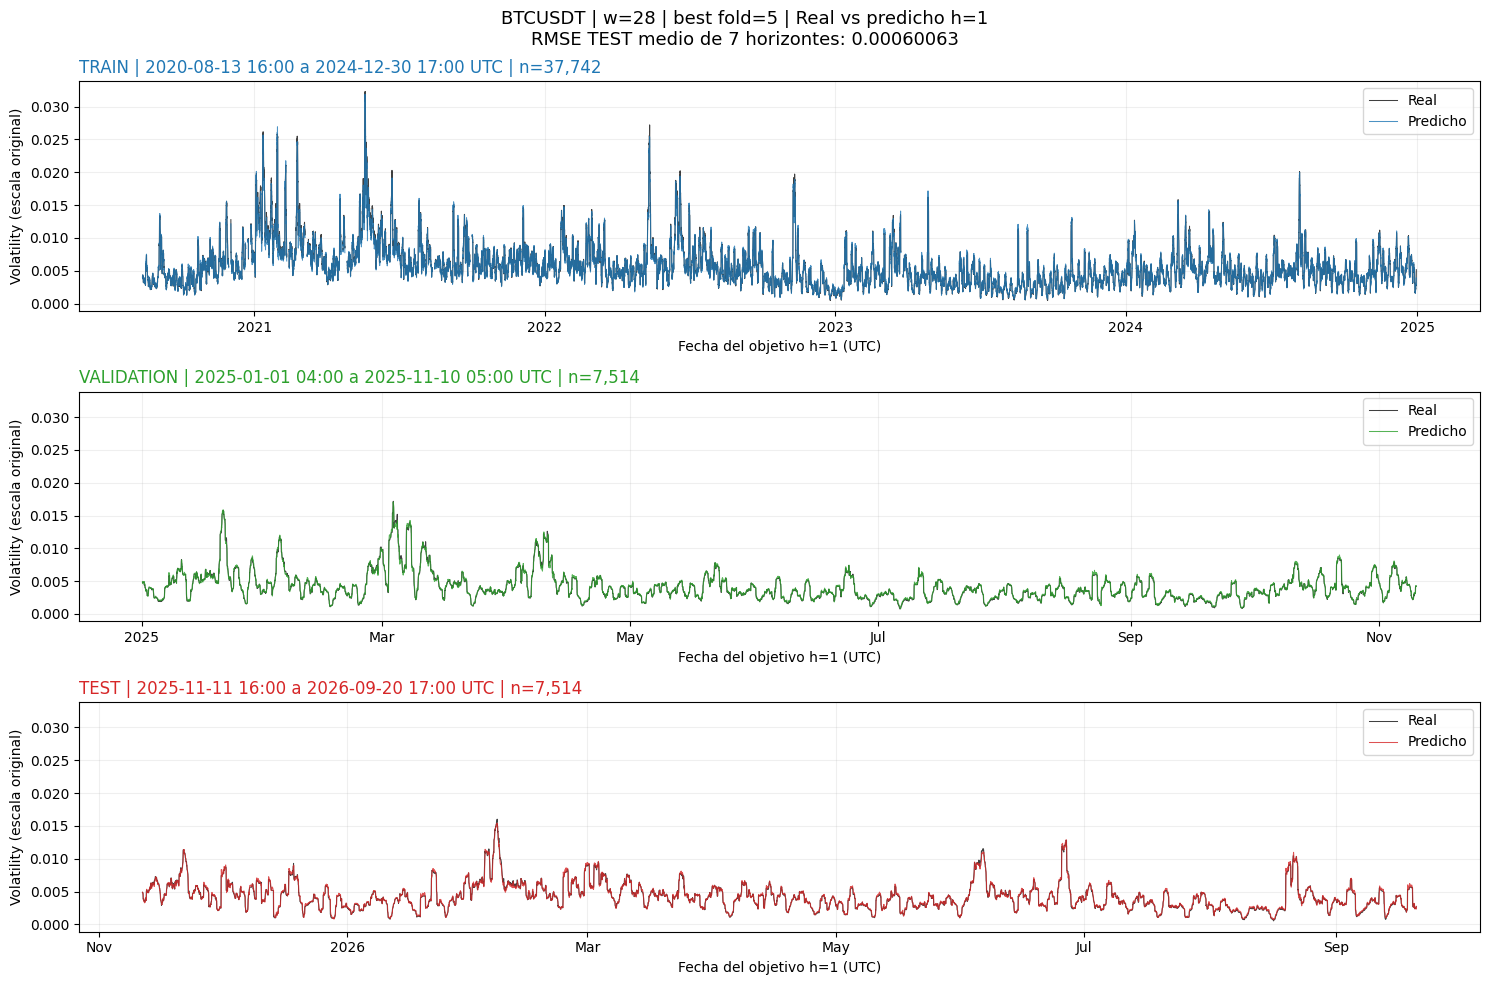

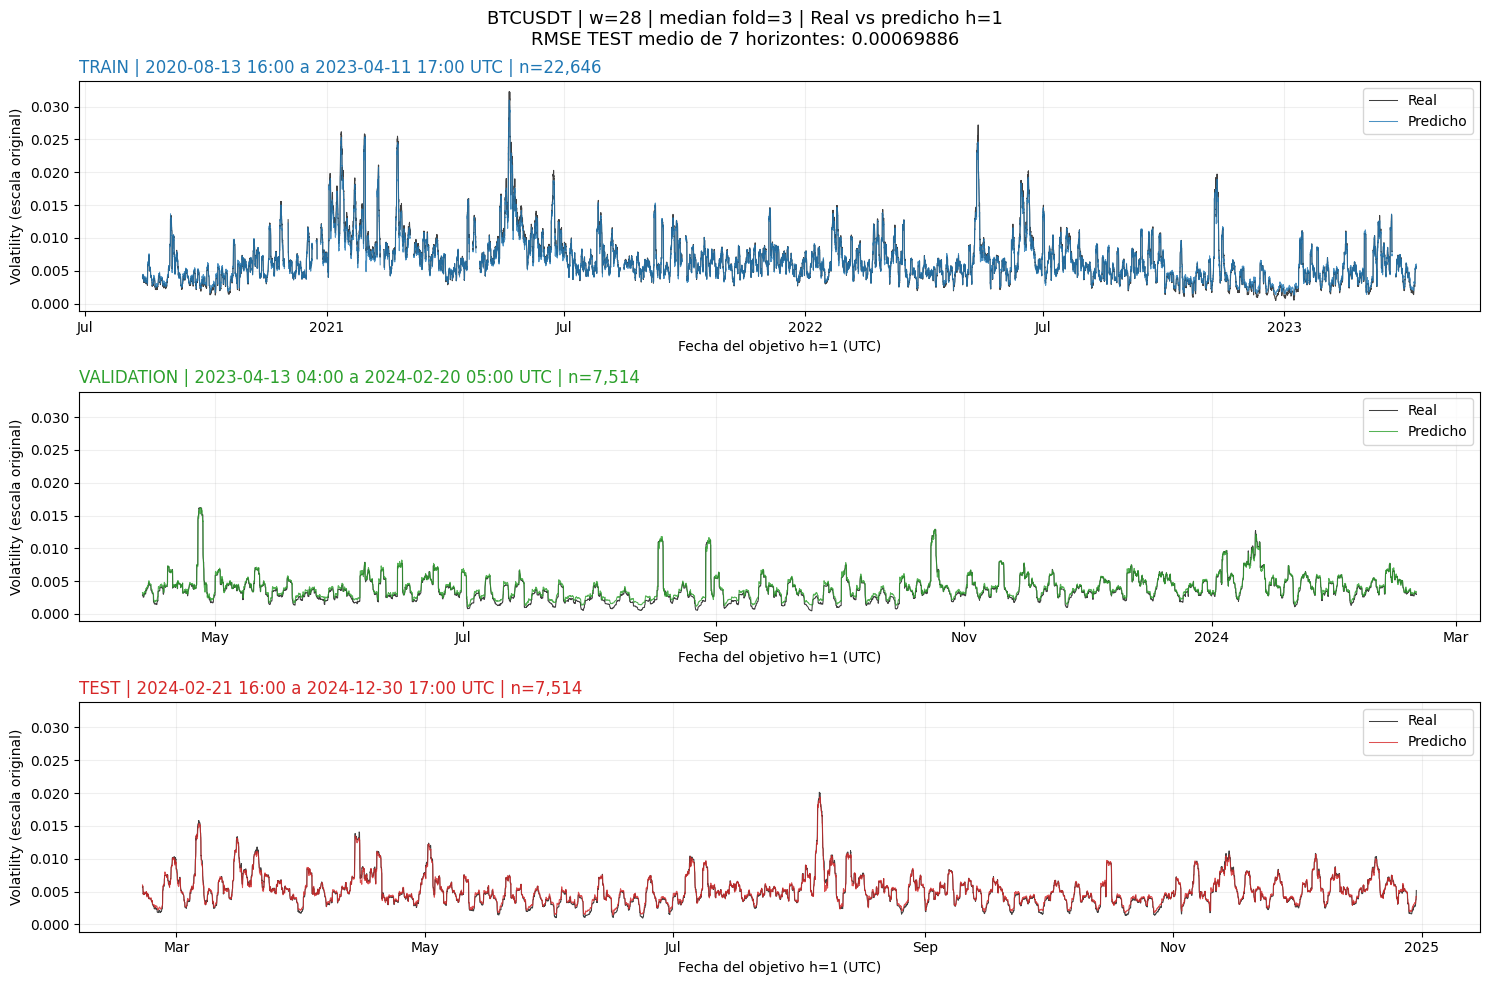

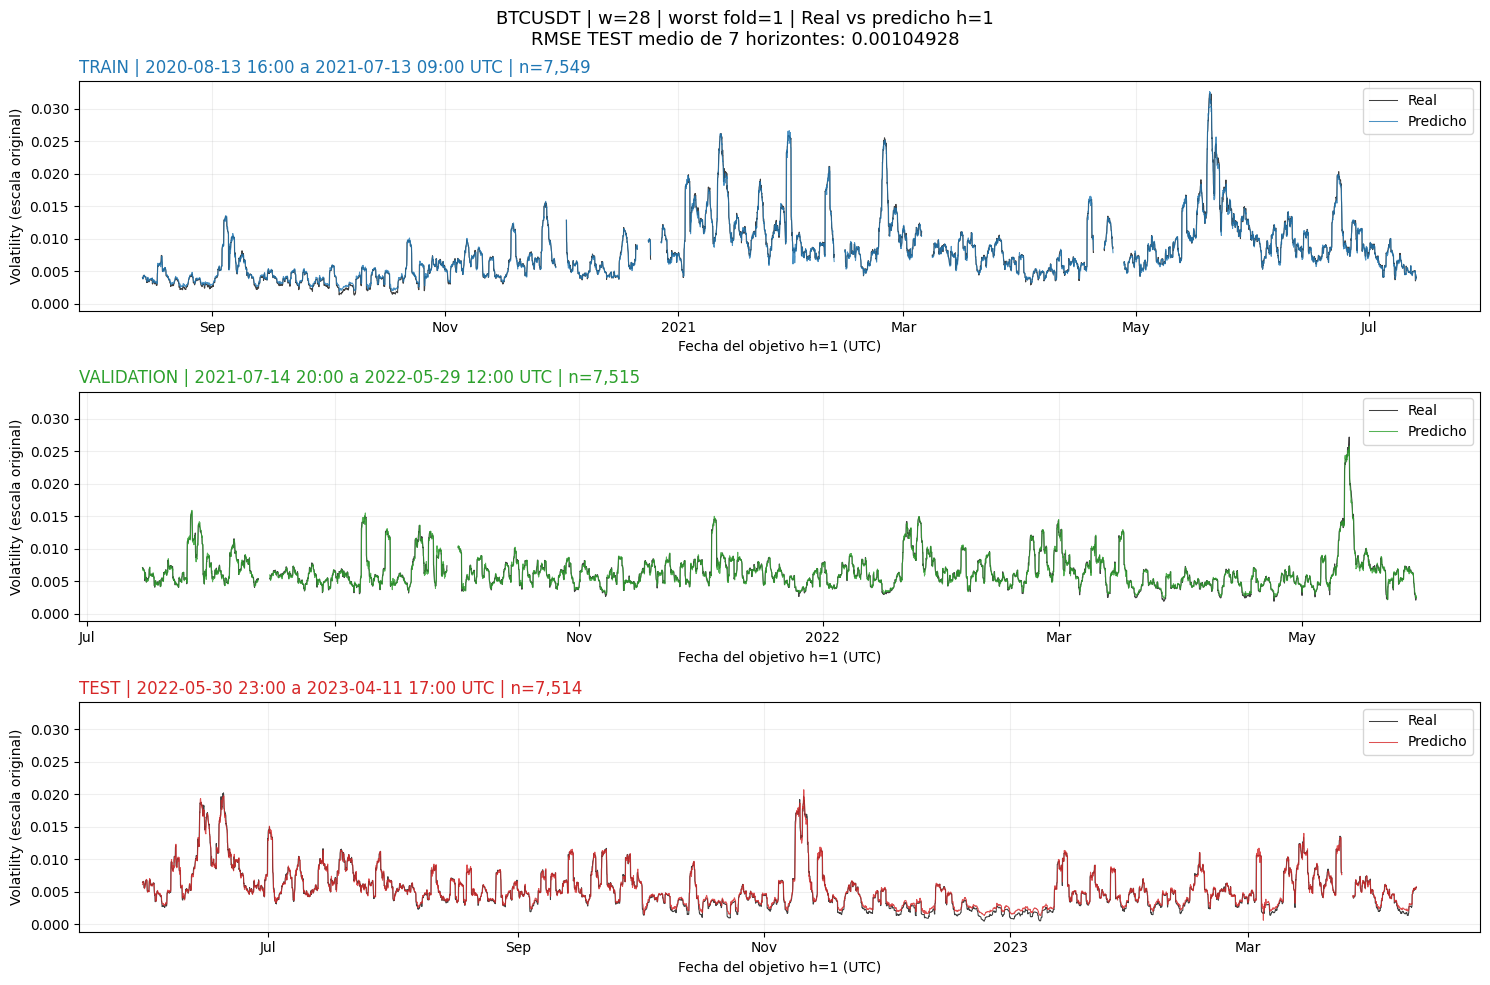

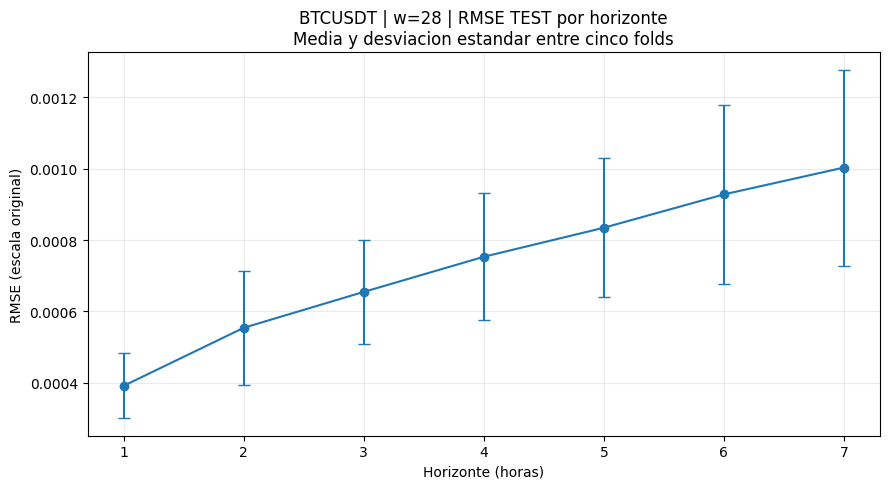

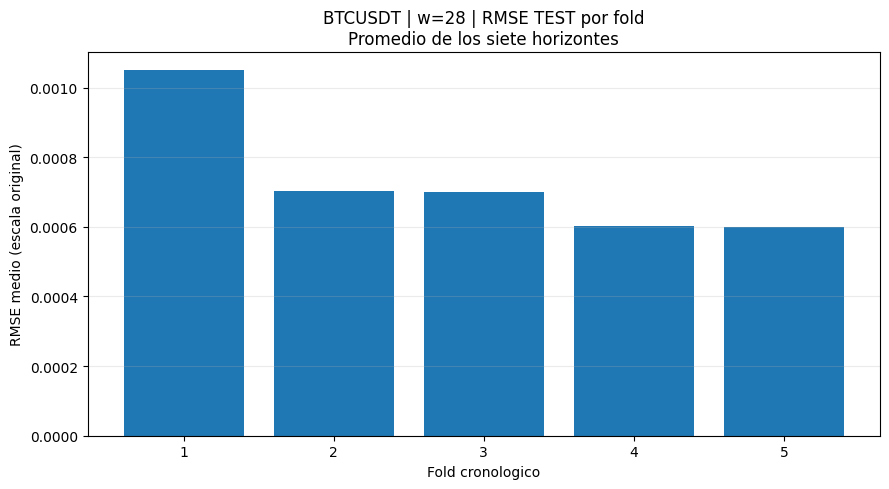

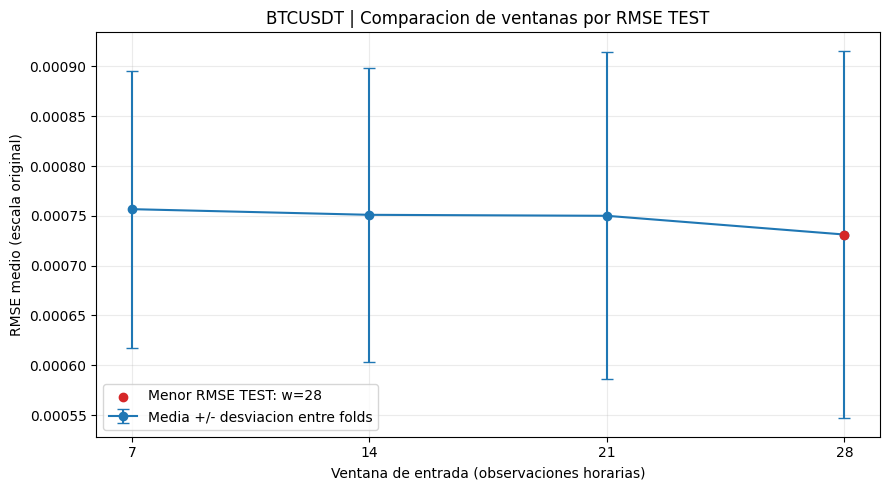

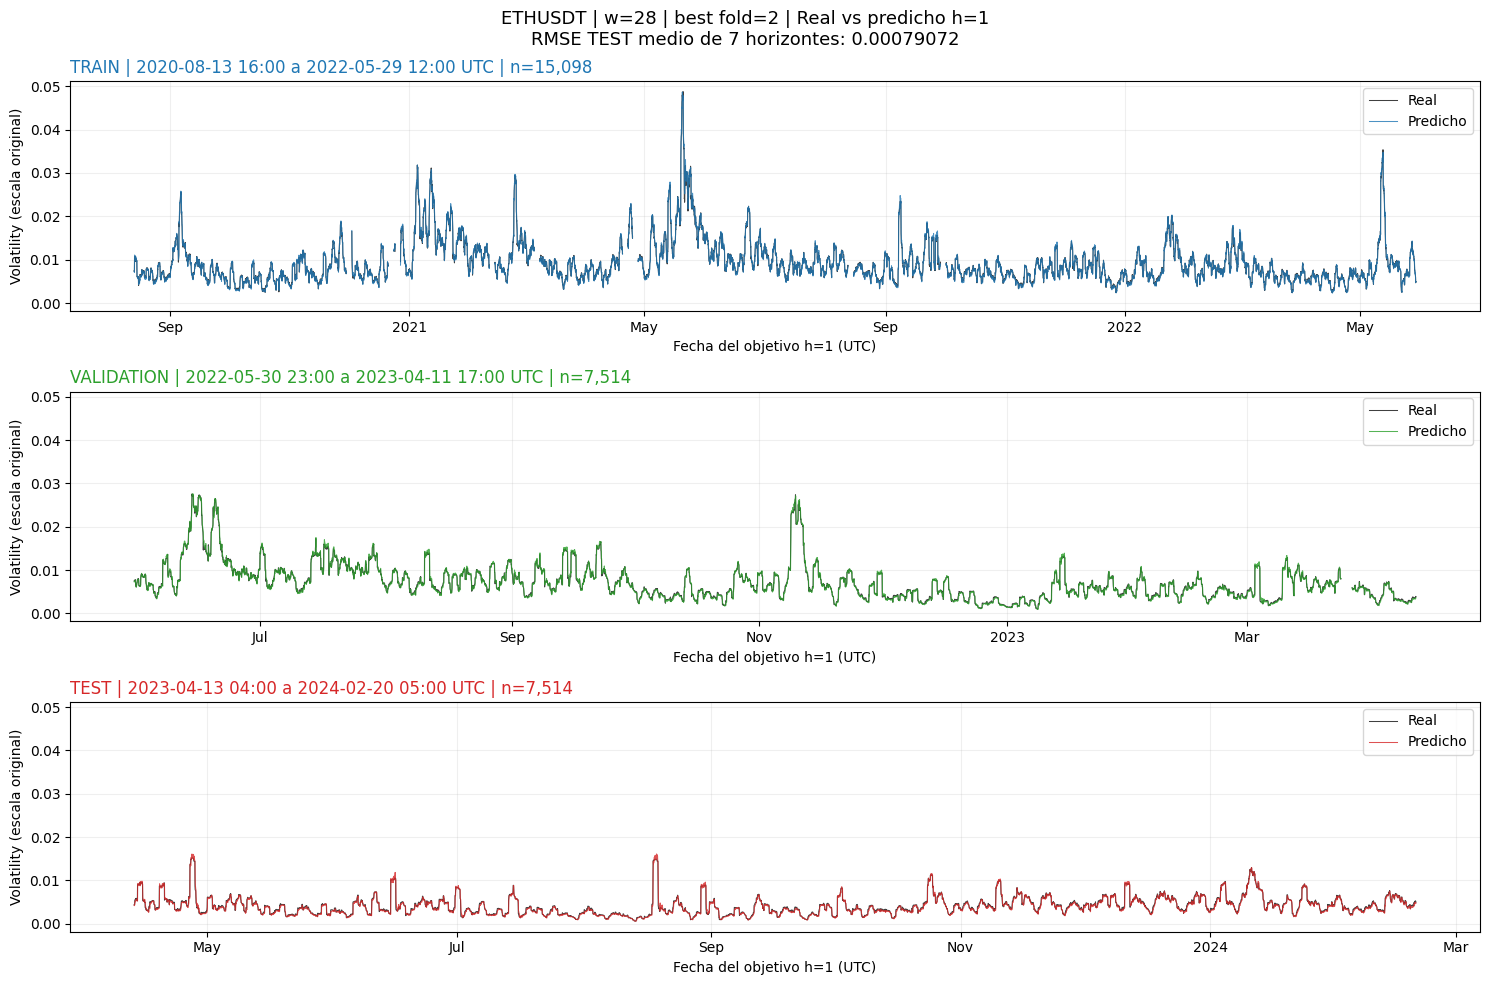

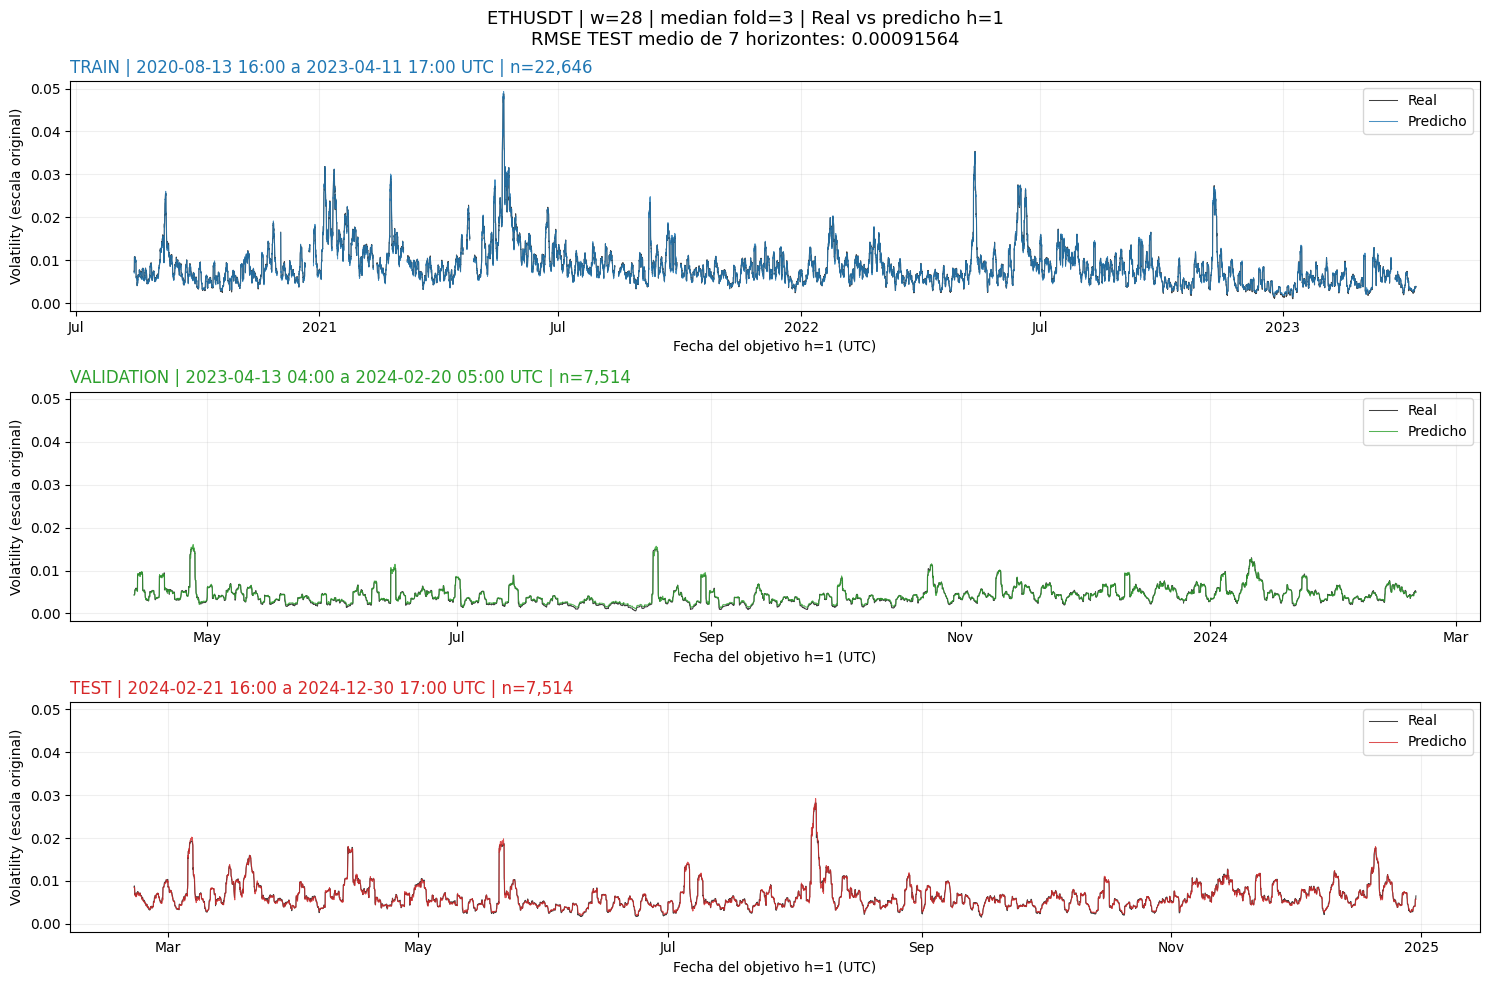

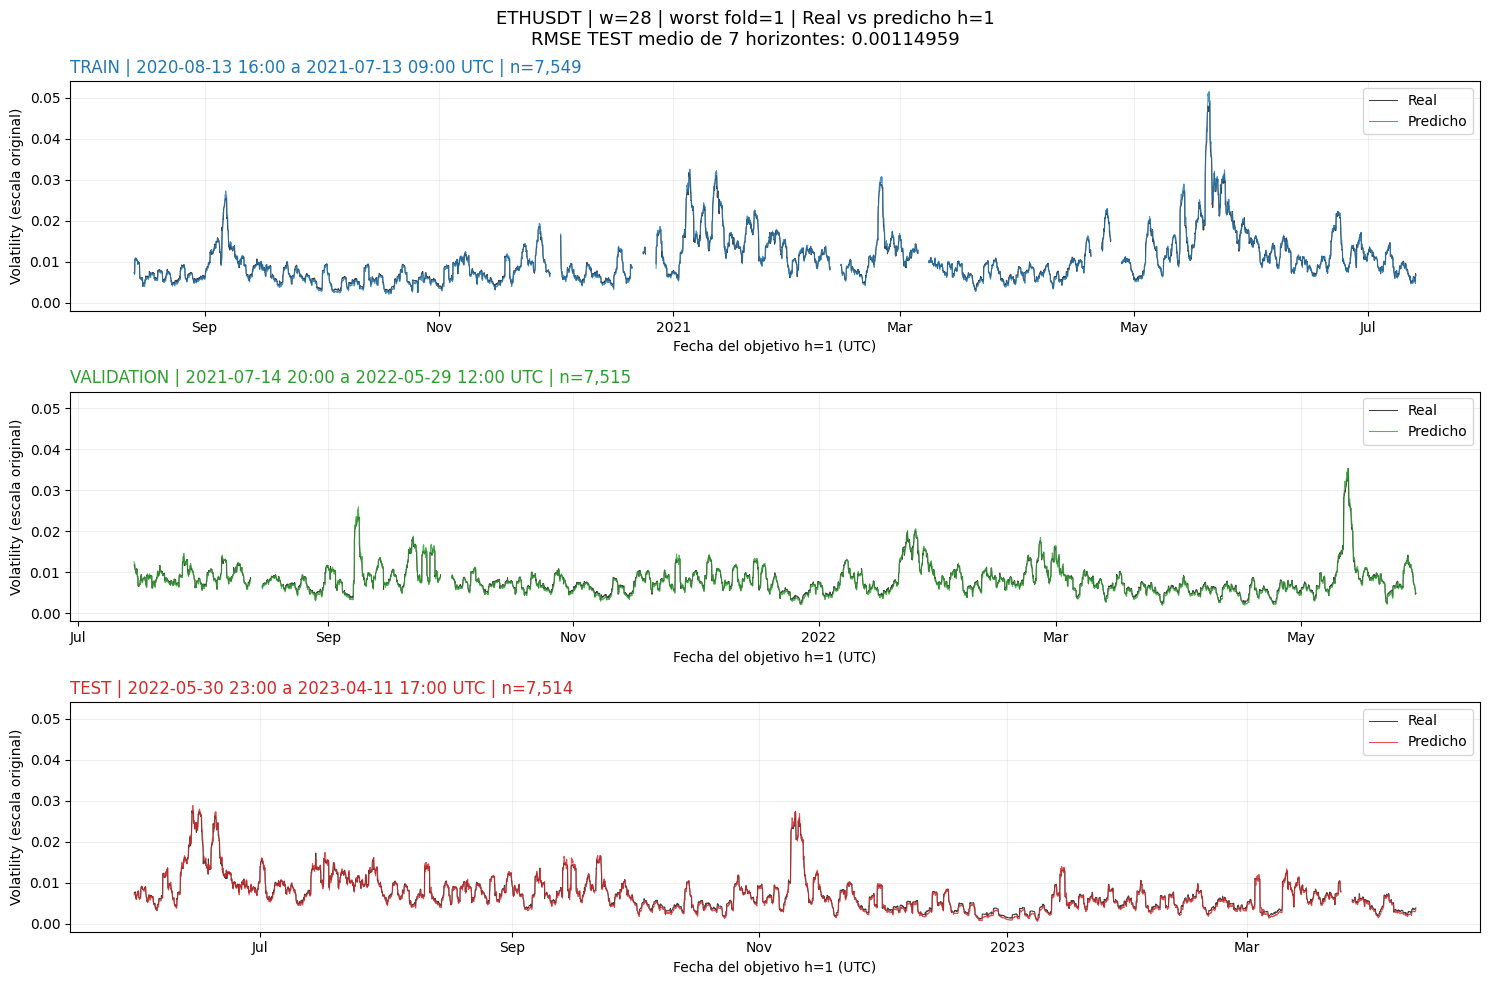

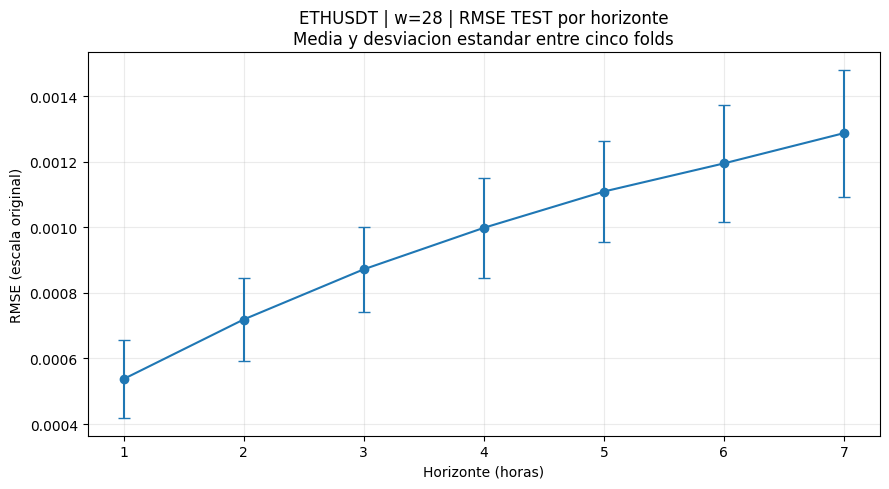

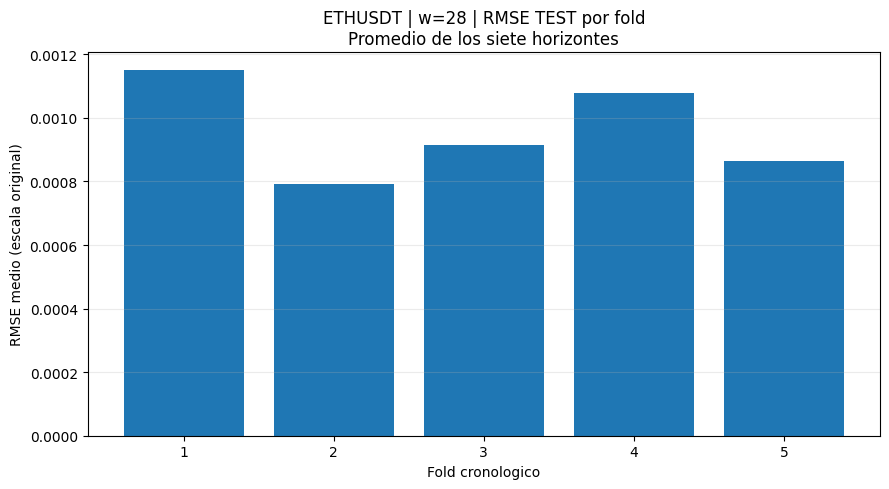

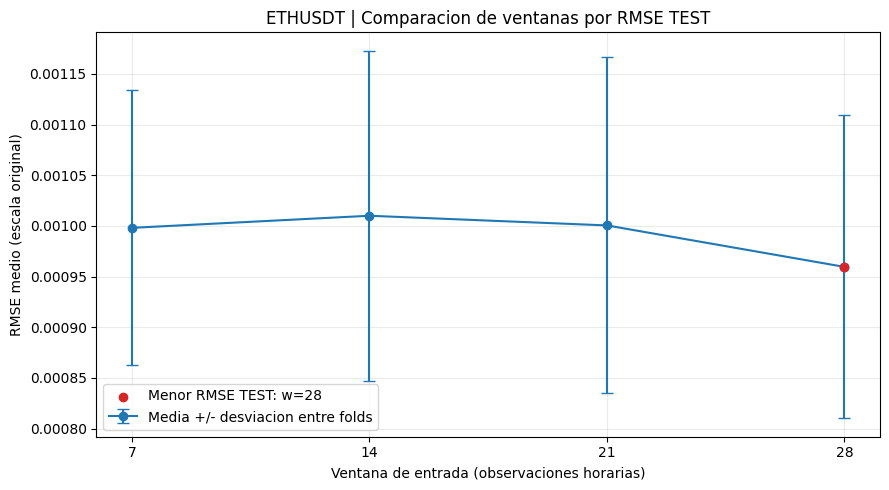

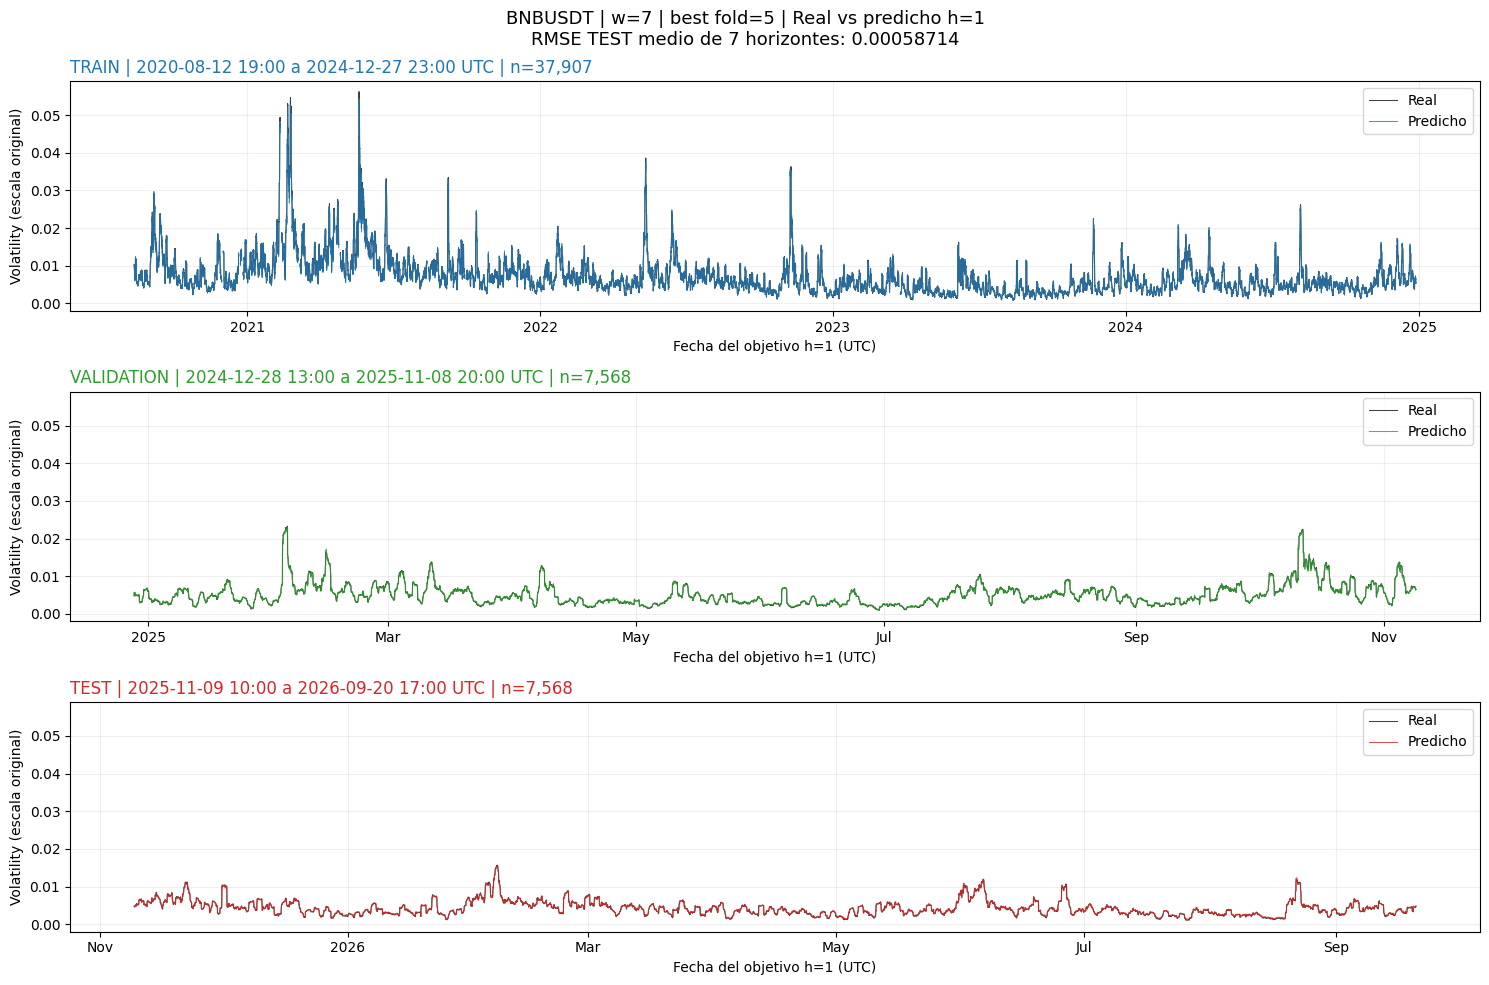

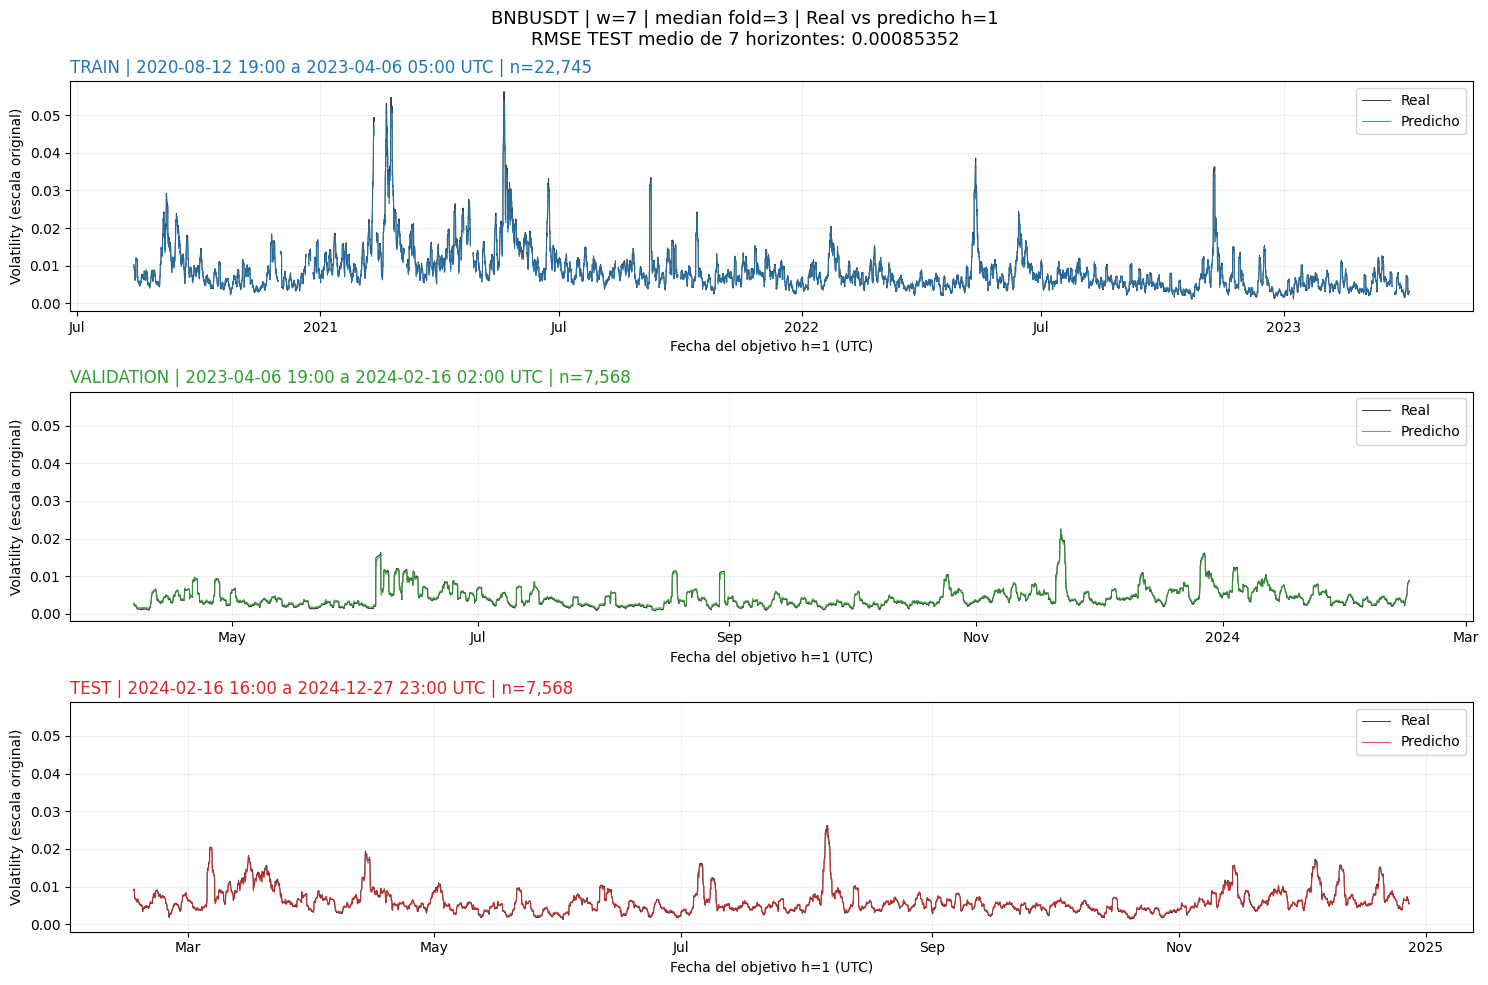

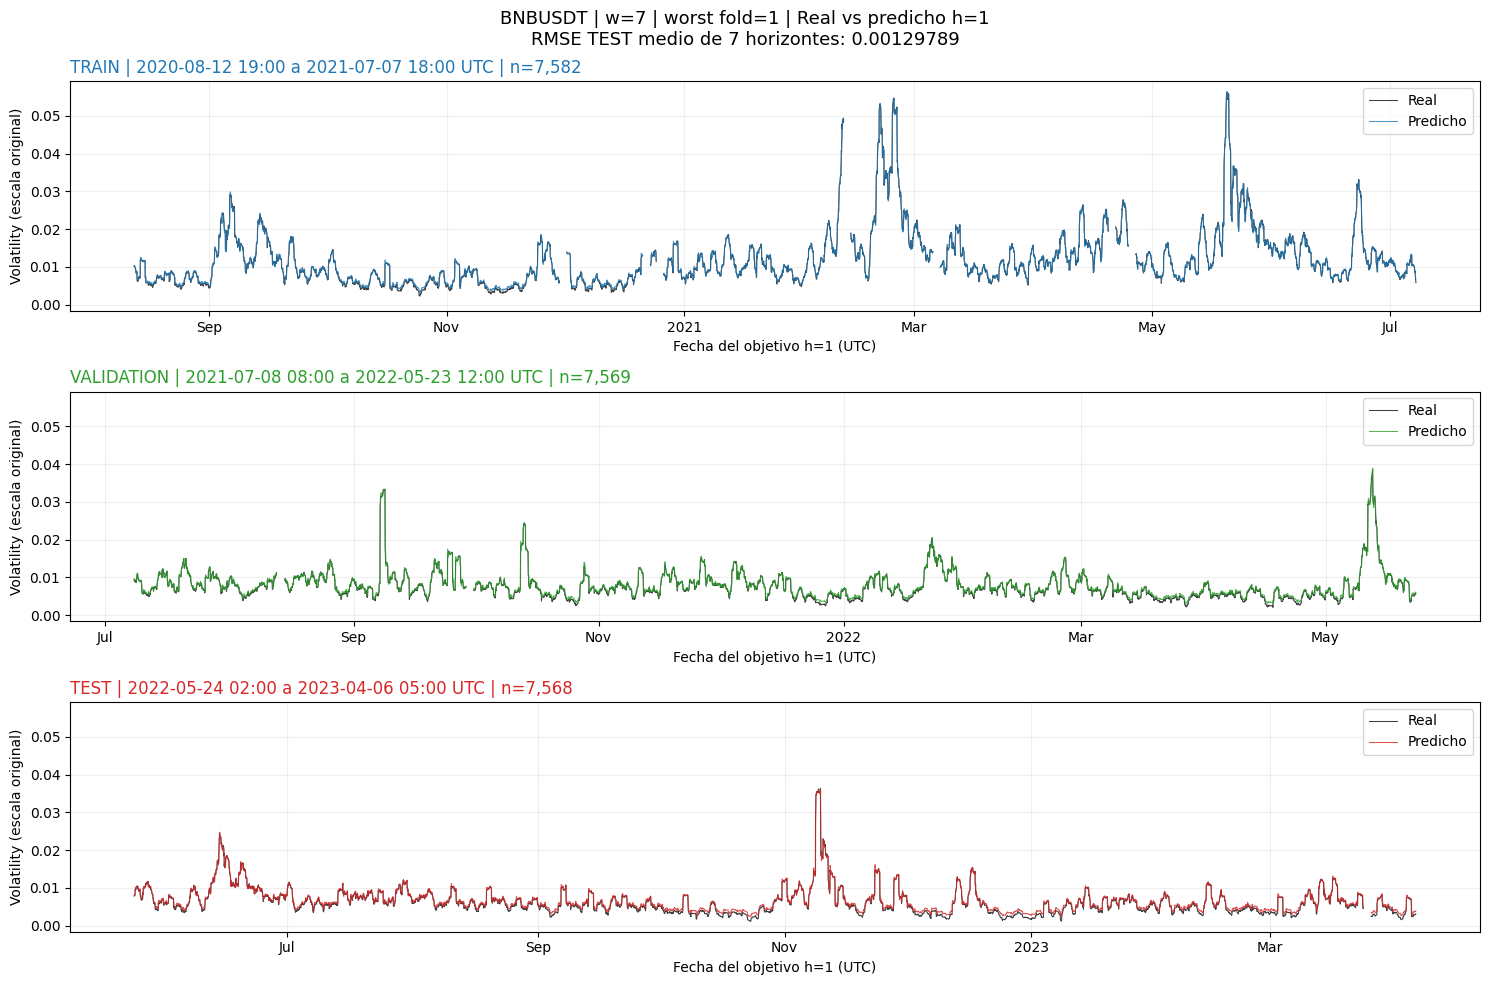

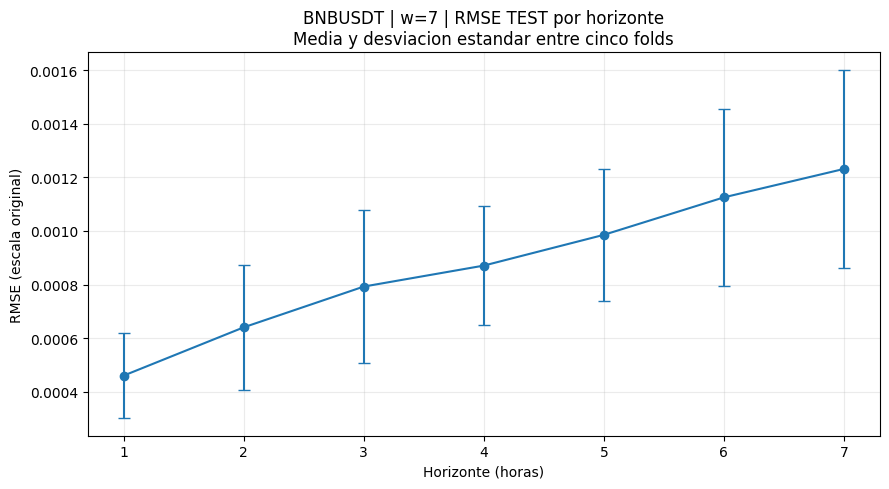

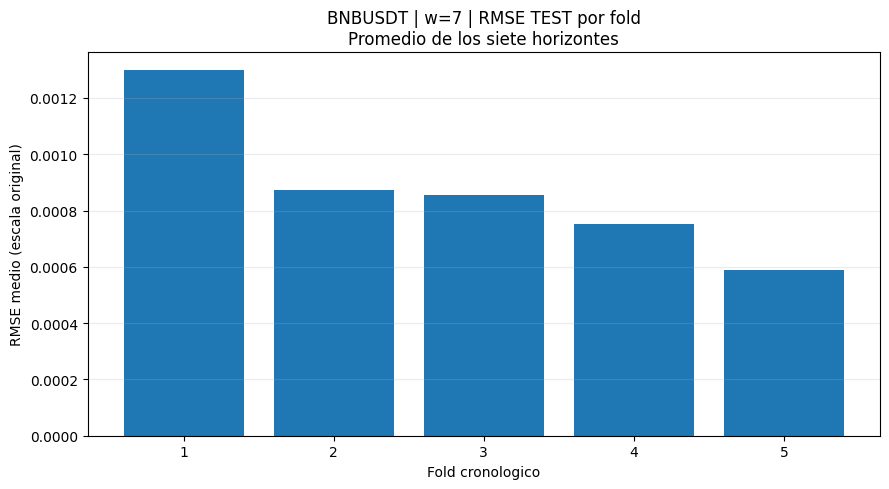

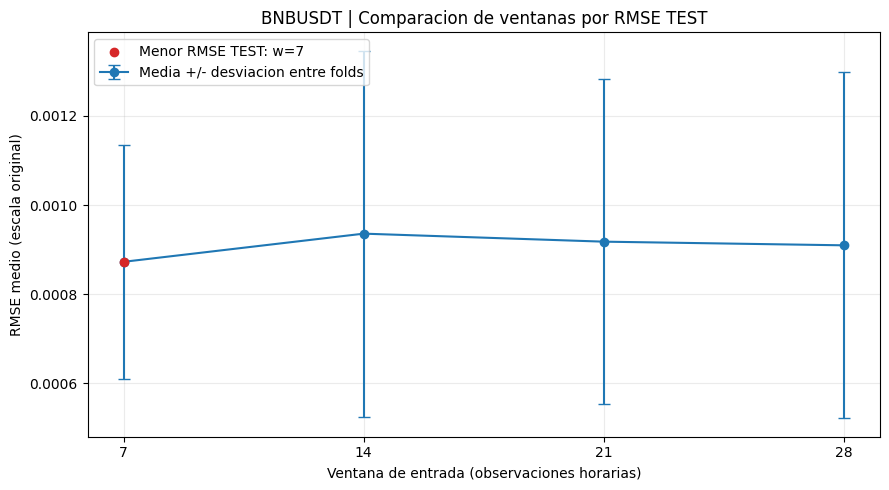

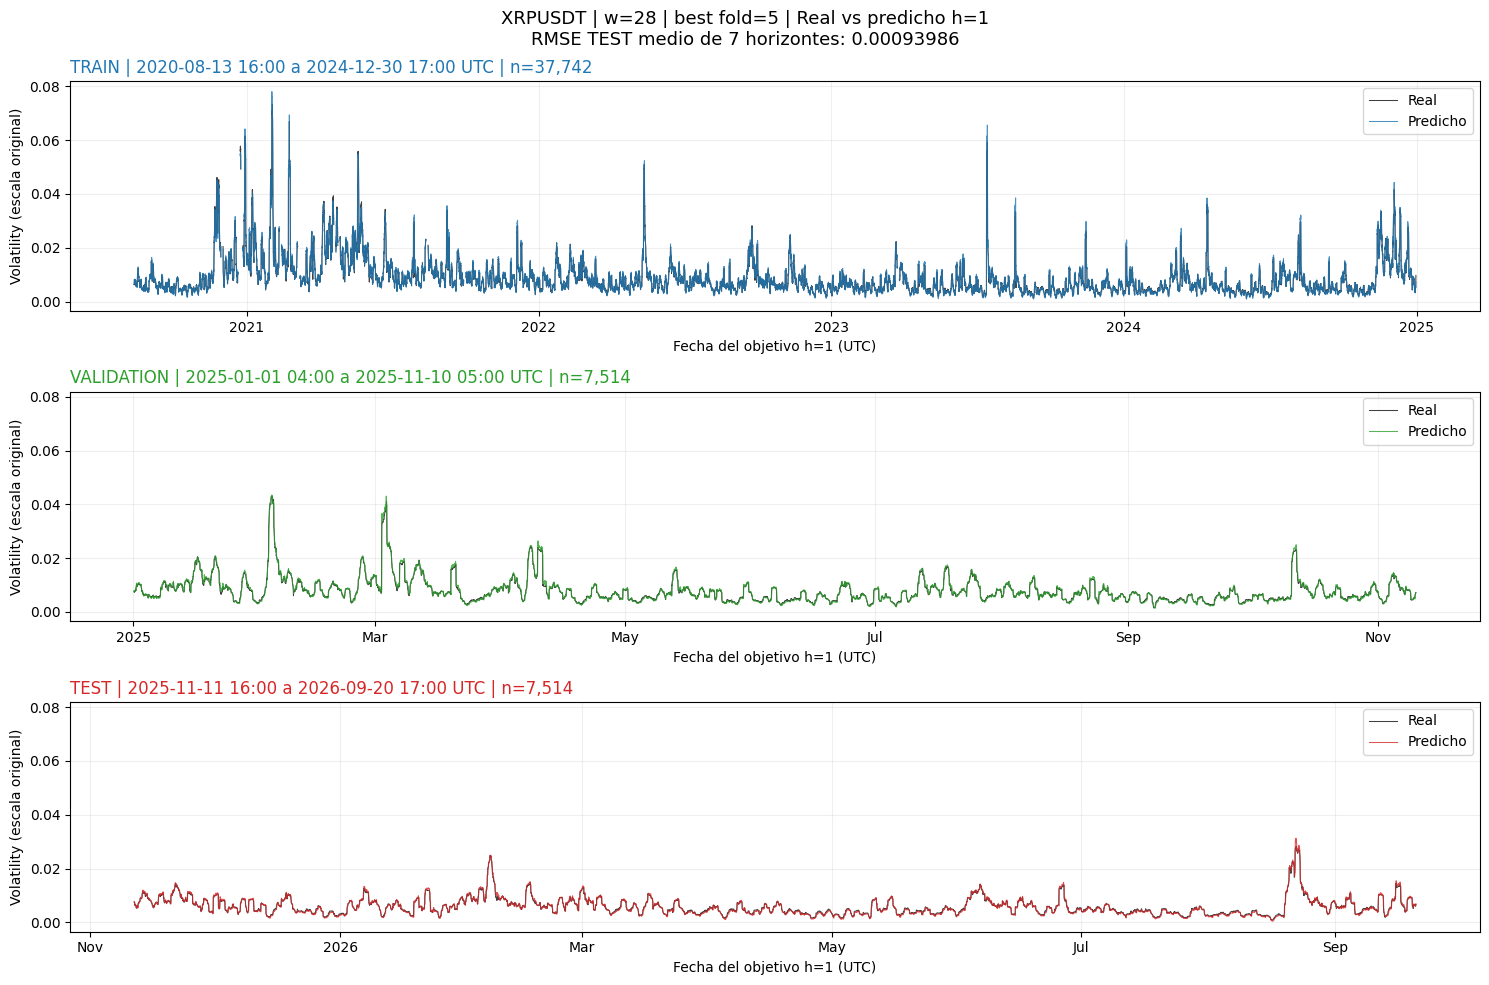

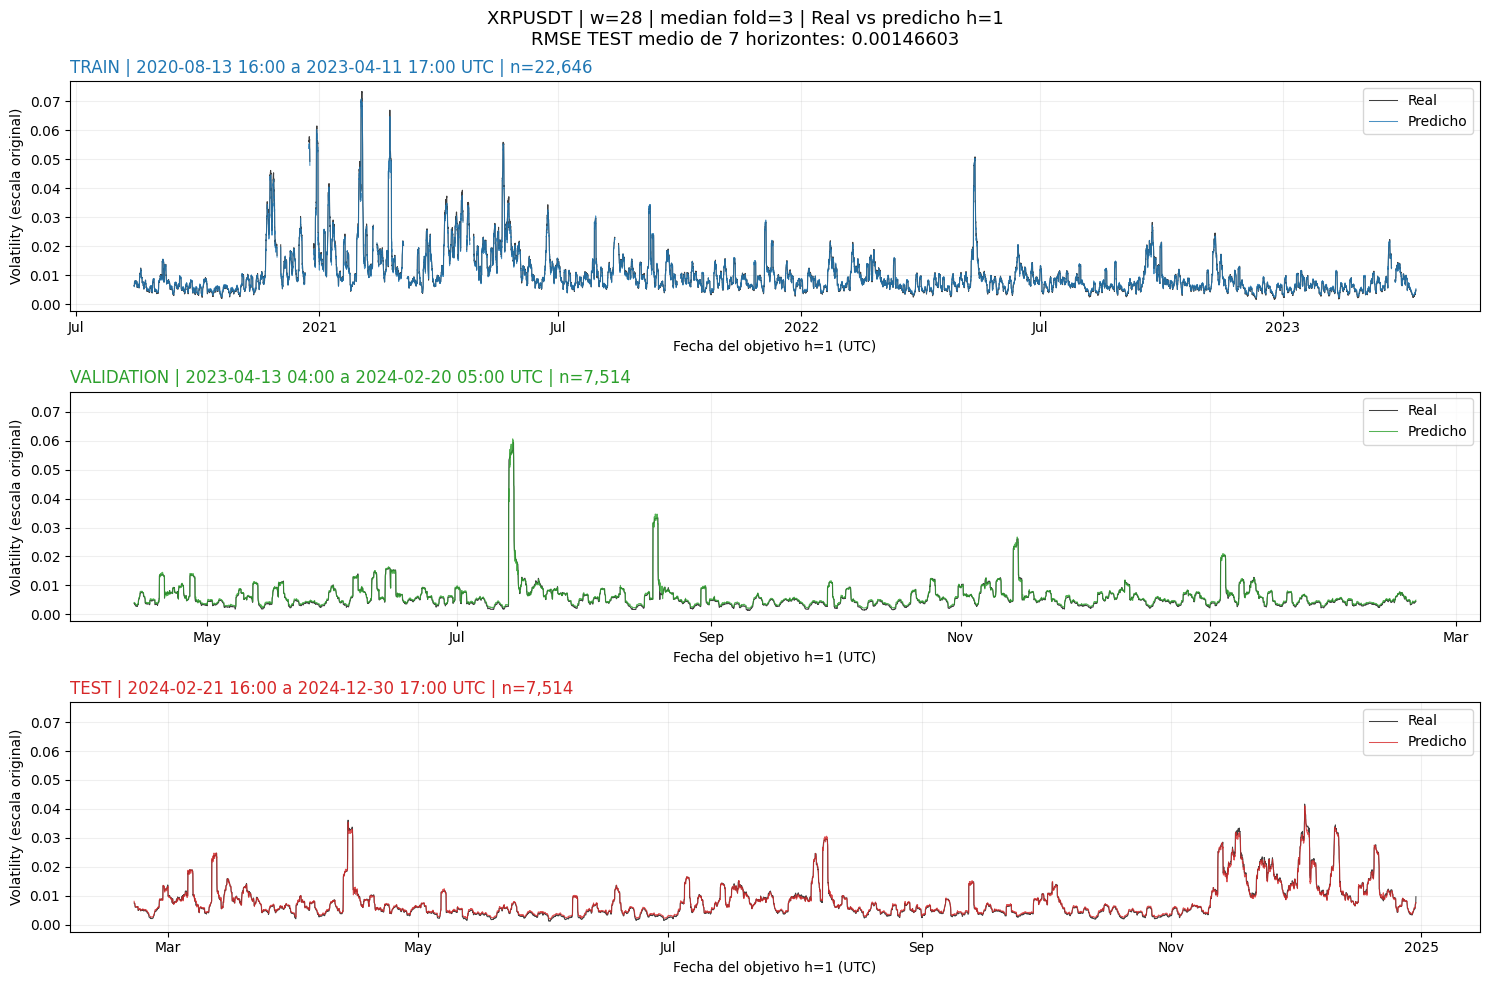

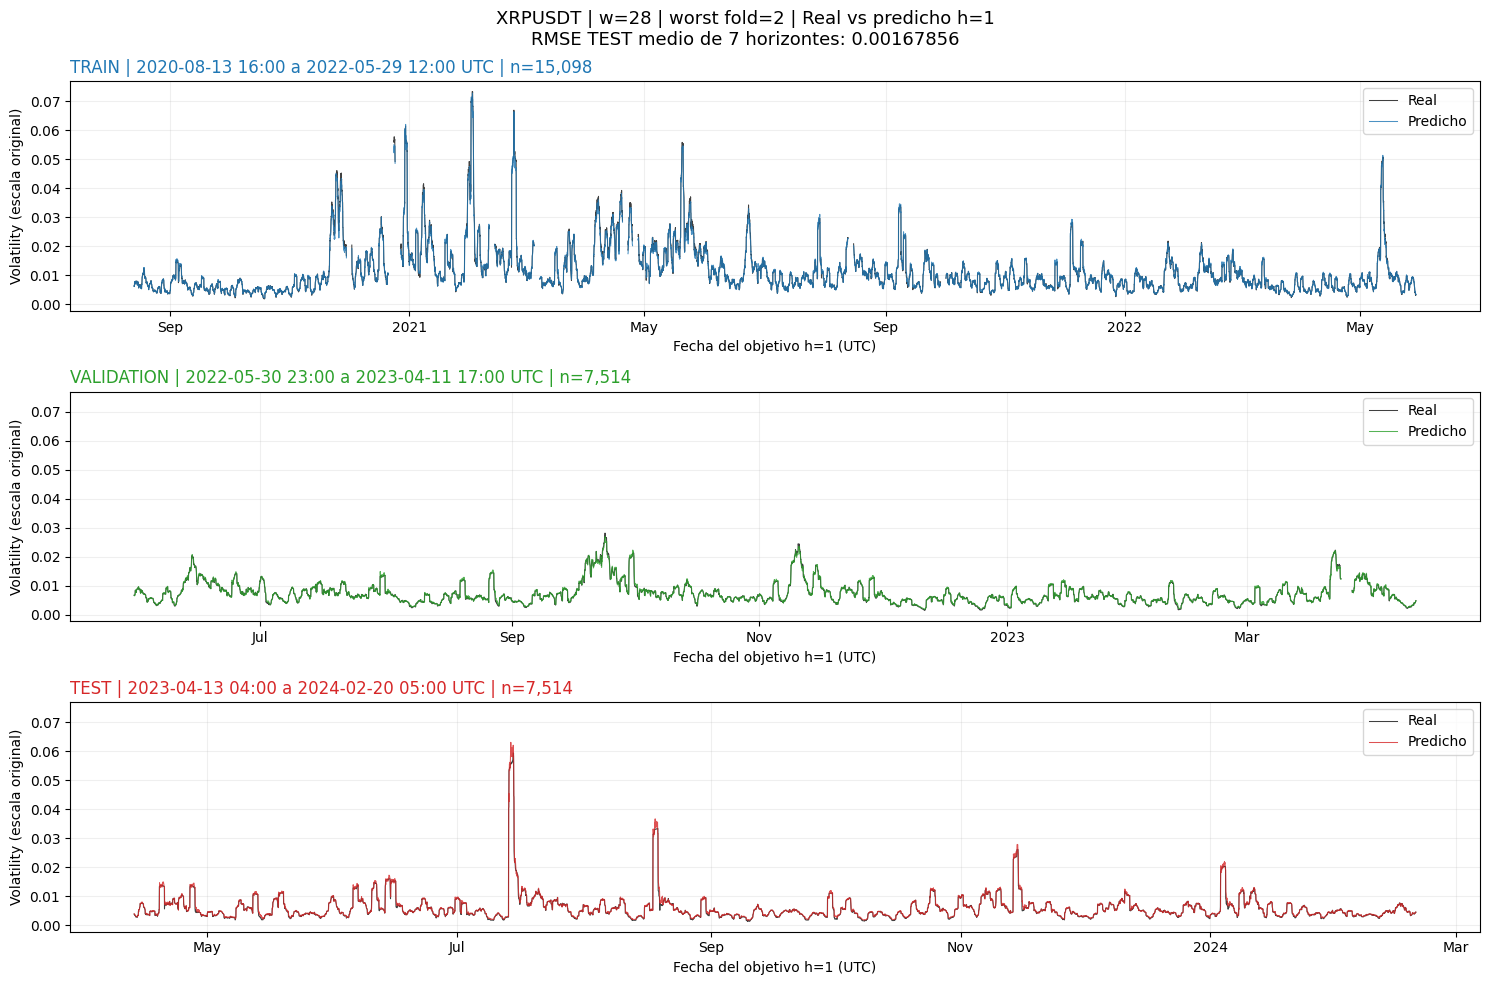

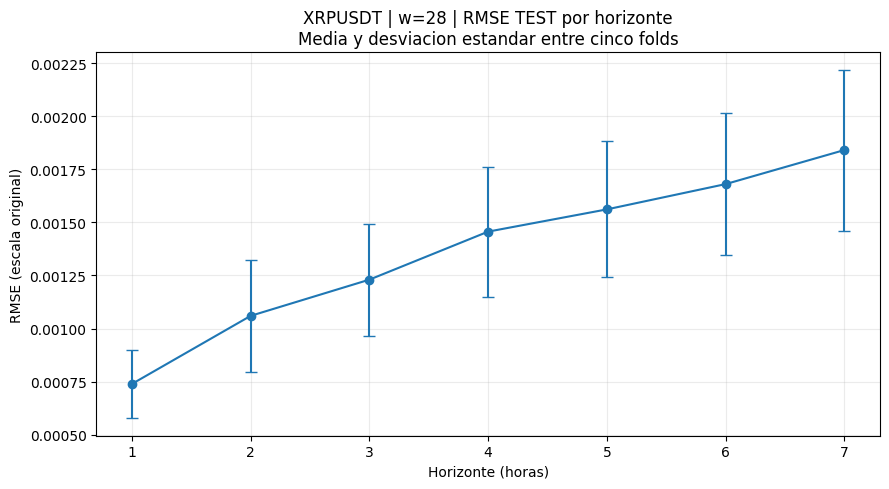

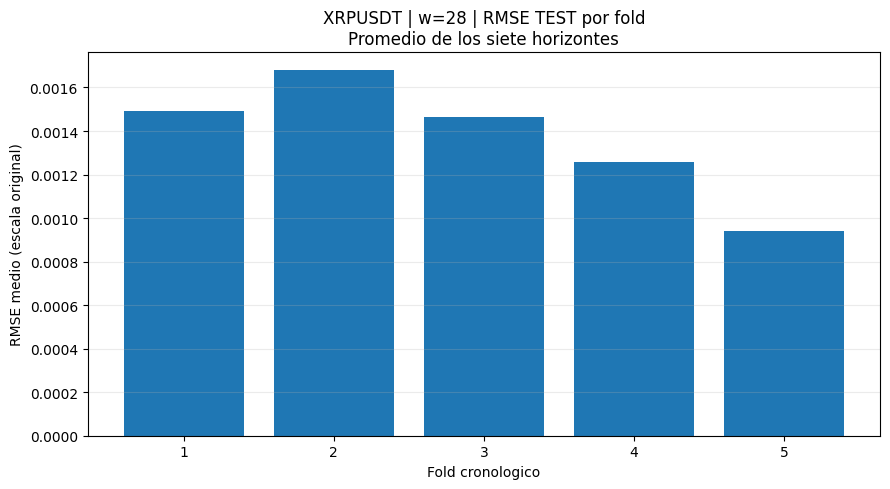

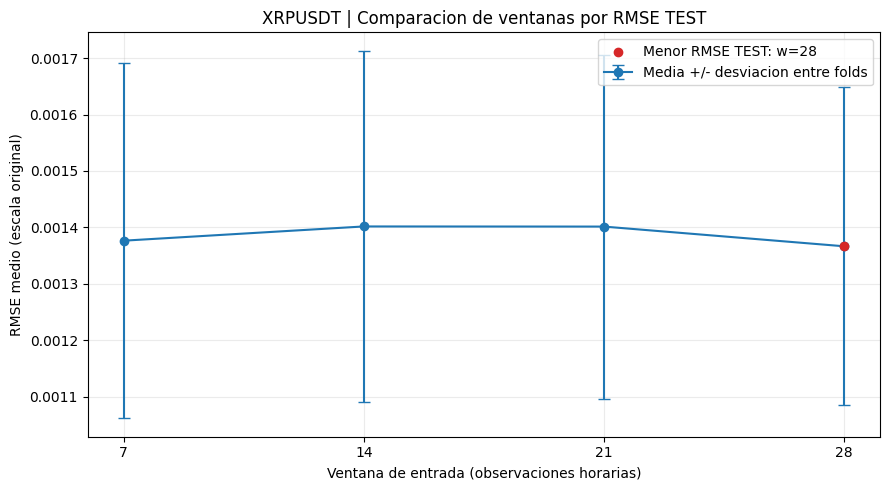

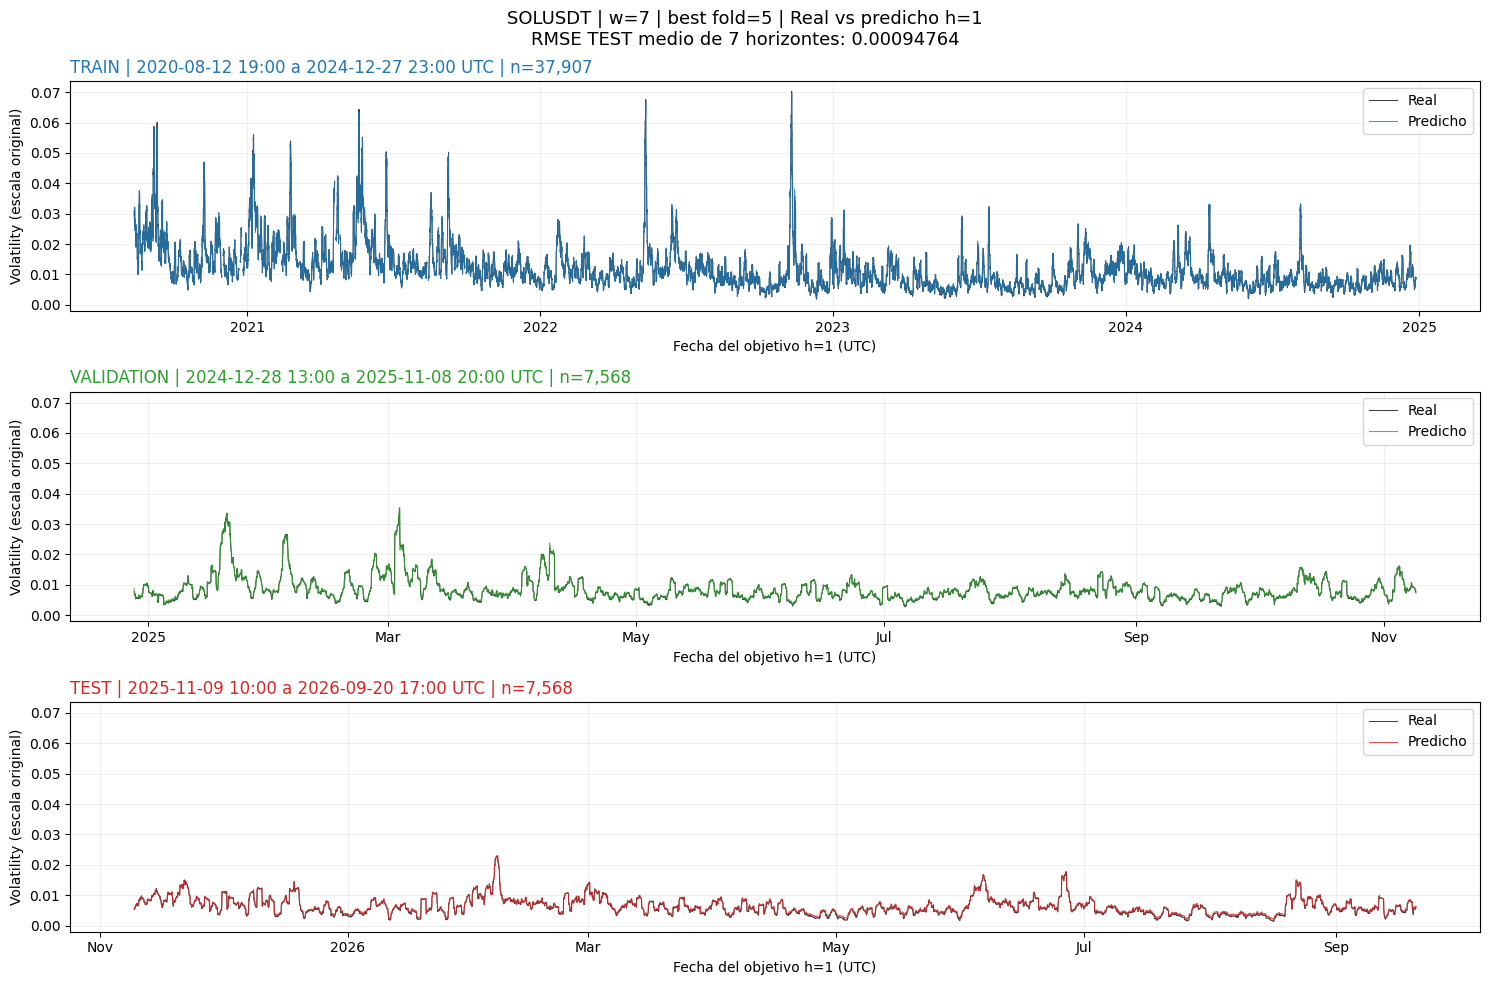

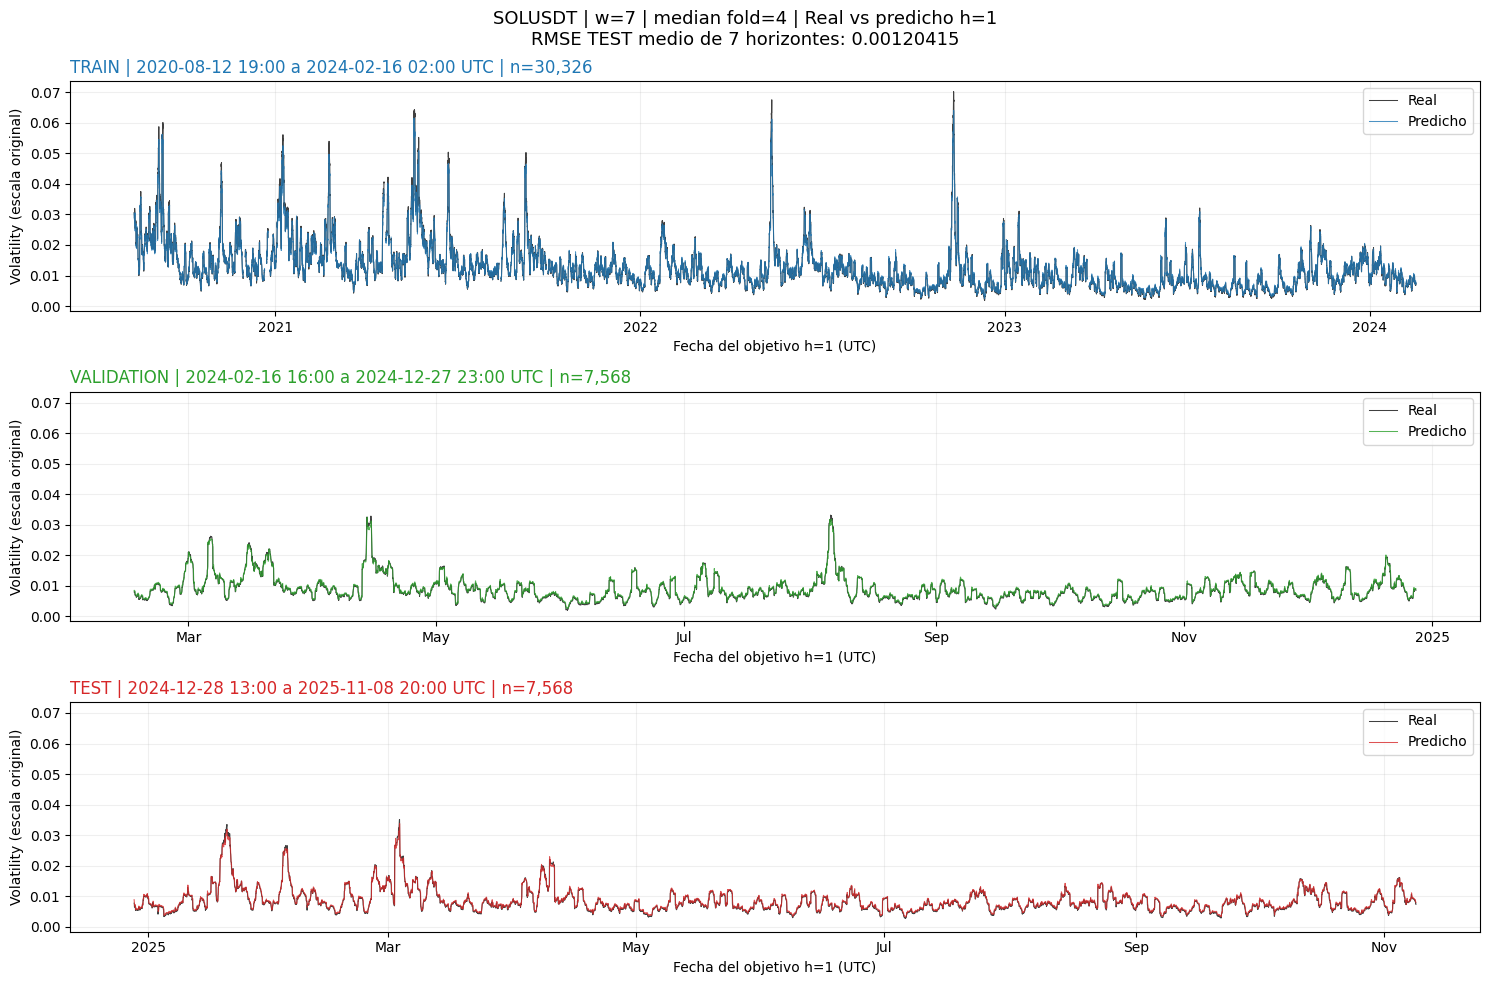

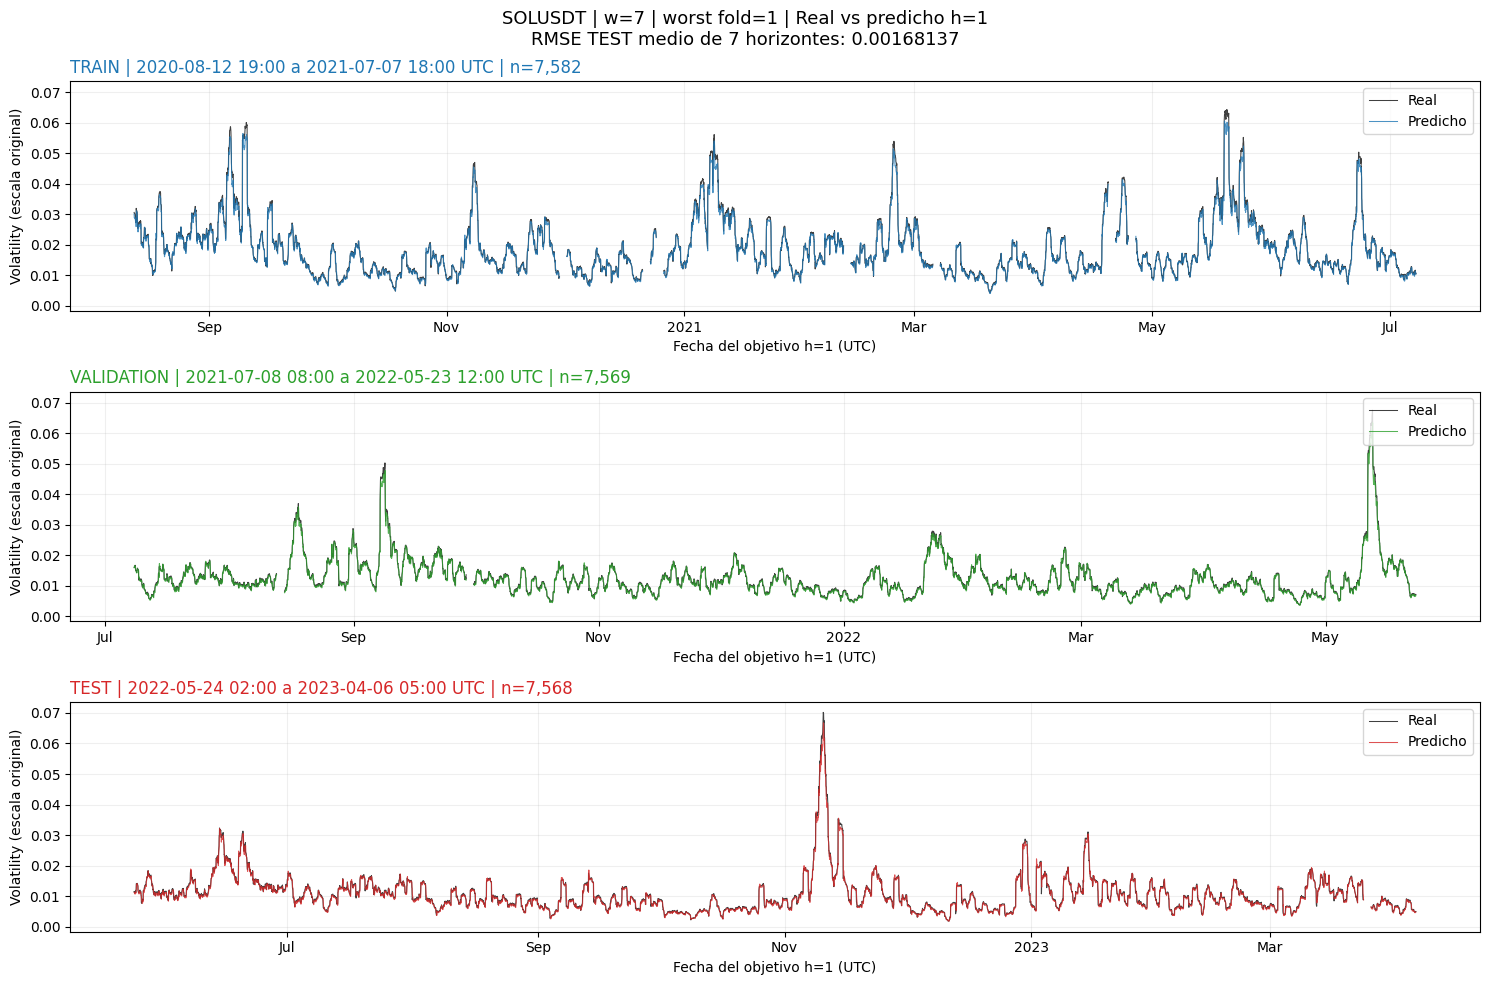

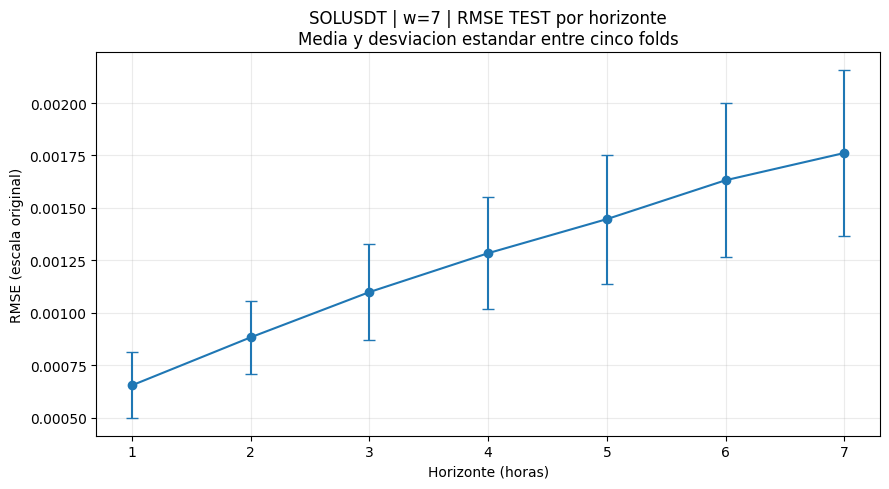

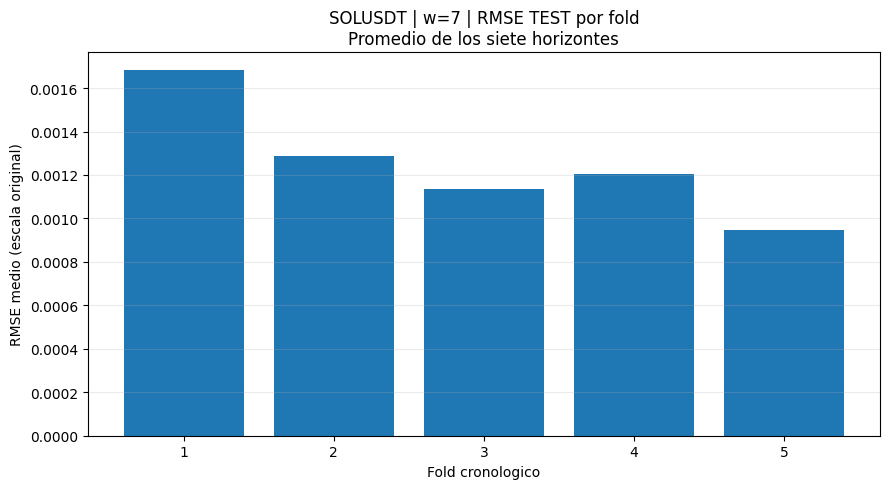

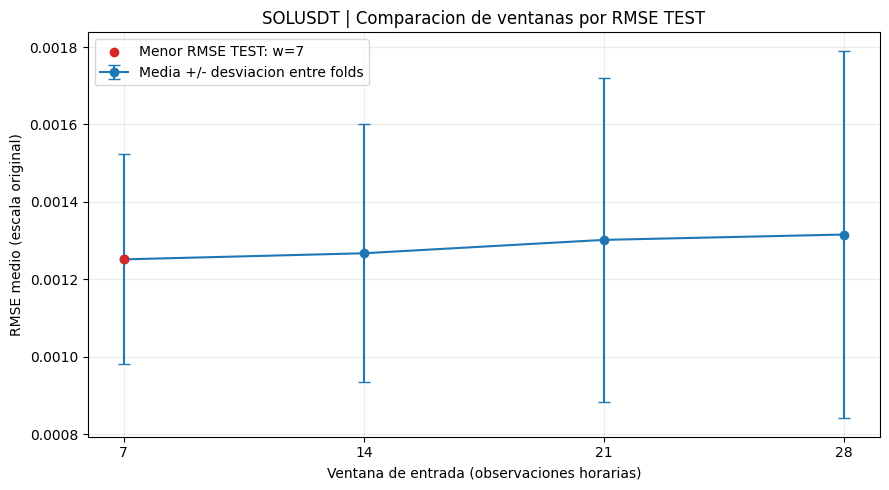

Evaluacion final: 30 figuras verificadas; 0 modelos reentrenados.


role,best,median,worst
symbol,,,
BTCUSDT,5,3,1
ETHUSDT,2,3,1
BNBUSDT,5,3,1
XRPUSDT,5,3,2
SOLUSDT,5,4,1


In [8]:
import matplotlib.dates as mdates
from PIL import Image
FINAL_FIG_DIR=Path("notebooks/figs")
REAL_PRED_DIR=FINAL_FIG_DIR / "real_vs_pred"
REAL_PRED_DIR.mkdir(parents=True,exist_ok=True)
final_figure_records=[]

def save_final_figure(fig,path,symbol,w,kind,role="",fold=None,datasets="test"):
    fig.tight_layout()
    fig.savefig(path,dpi=140,bbox_inches="tight")
    with Image.open(path) as picture:
        assert picture.format=="PNG" and picture.width>400 and picture.height>250
        picture.verify()
    final_figure_records.append({"symbol":symbol,"input_window":w,"kind":kind,"role":role,
        "fold":fold,"datasets":datasets,"path":path.as_posix()})
    plt.show()
    plt.close(fig)

for selection in best_window_by_symbol.itertuples(index=False):
    symbol,w=selection.symbol,int(selection.best_input_window)
    asset=df_volatility.loc[df_volatility.symbol.eq(symbol)].copy()
    observed_X,observed_y,observed_dates,_=build_segment_windows(asset,w)
    expected_folds={f["fold"]:f for f in expanding_temporal_indices(observed_dates)}
    for selected in selected_folds_by_symbol.loc[selected_folds_by_symbol.symbol.eq(symbol)].itertuples(index=False):
        fold=int(selected.fold)
        prediction_file=FINAL_RESULTS_DIR / "volatility_predictions" / f"{symbol}_w{w}_fold{fold}.npz"
        fig,axes=plt.subplots(3,1,figsize=(15,10),sharey=True)
        for ax,(dataset,label,pred_key,index_key,color) in zip(axes,[
            ("train","TRAIN","pred_train","train_indices","tab:blue"),
            ("validation","VALIDATION","pred_val","validation_indices","tab:green"),
            ("test","TEST","pred_test","test_indices","tab:red")]):
            with np.load(prediction_file,allow_pickle=False) as saved:
                indices=saved[index_key]
                prediction=saved[pred_key]
            np.testing.assert_array_equal(indices,expected_folds[fold][dataset])
            truth=observed_y[indices]
            dates=observed_dates.iloc[indices].reset_index(drop=True)
            assert prediction.shape==truth.shape and prediction.shape[1]==7
            assert np.isfinite(prediction).all() and np.isfinite(truth).all()
            cv=final_cv_source.loc[final_cv_source.symbol.eq(symbol)&final_cv_source.input_window.eq(w)&final_cv_source.fold.eq(fold)].iloc[0]
            assert dates.input_start.min()==cv[dataset+"_start"]
            assert dates.target_end.max()==cv[dataset+"_end"]
            stored=final_horizon_source.loc[final_horizon_source.symbol.eq(symbol)&final_horizon_source.input_window.eq(w)&final_horizon_source.fold.eq(fold)&final_horizon_source.dataset.eq(dataset)&final_horizon_source.horizon.eq(1)]
            assert len(stored)==1
            np.testing.assert_allclose(np.sqrt(np.mean((truth[:,0]-prediction[:,0])**2)),stored.RMSE.iloc[0],rtol=1e-9,atol=1e-14)
            breaks=dates.target_start.diff().ne(pd.Timedelta(hours=1)) | dates.segment_id.ne(dates.segment_id.shift())
            for number,(_,group) in enumerate(dates.groupby(breaks.cumsum(),sort=False)):
                positions=group.index.to_numpy()
                ax.plot(group.target_start,truth[positions,0],color="black",linewidth=.75,alpha=.75,label="Real" if number==0 else None)
                ax.plot(group.target_start,prediction[positions,0],color=color,linewidth=.75,alpha=.8,label="Predicho" if number==0 else None)
            assert {"Real","Predicho"}.issubset(set(ax.get_legend_handles_labels()[1]))
            ax.set_title(f"{label} | {dates.target_start.min():%Y-%m-%d %H:%M} a {dates.target_start.max():%Y-%m-%d %H:%M} UTC | n={len(indices):,}",loc="left",color=color)
            ax.set_ylabel("Volatility (escala original)")
            ax.set_xlabel("Fecha del objetivo h=1 (UTC)")
            locator=mdates.AutoDateLocator(minticks=3,maxticks=7)
            ax.xaxis.set_major_locator(locator)
            ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
            ax.legend(loc="upper right")
            ax.grid(alpha=.2)
        fig.suptitle(f"{symbol} | w={w} | {selected.role} fold={fold} | Real vs predicho h=1\nRMSE TEST medio de 7 horizontes: {selected.RMSE_mean:.8f}",fontsize=13)
        save_final_figure(fig,REAL_PRED_DIR / f"{symbol}_w{w}_{selected.role}_fold_real_vs_pred.png",symbol,w,"real_vs_pred",selected.role,fold,"train,validation,test")
    hs=final_rmse_by_horizon.loc[final_rmse_by_horizon.symbol.eq(symbol)].sort_values("horizon")
    fig,ax=plt.subplots(figsize=(9,5))
    ax.errorbar(hs.horizon,hs.RMSE_mean,yerr=hs.RMSE_std,marker="o",capsize=4)
    ax.set(title=f"{symbol} | w={w} | RMSE TEST por horizonte\nMedia y desviacion estandar entre cinco folds",xlabel="Horizonte (horas)",ylabel="RMSE (escala original)",xticks=range(1,8))
    ax.grid(alpha=.25)
    save_final_figure(fig,FINAL_FIG_DIR / f"{symbol}_w{w}_test_rmse_by_horizon.png",symbol,w,"rmse_by_horizon")
    fs=final_test_folds.loc[final_test_folds.symbol.eq(symbol)&final_test_folds.input_window.eq(w)].sort_values("fold")
    fig,ax=plt.subplots(figsize=(9,5))
    ax.bar(fs.fold,fs.RMSE_mean,color="tab:blue")
    ax.set(title=f"{symbol} | w={w} | RMSE TEST por fold\nPromedio de los siete horizontes",xlabel="Fold cronologico",ylabel="RMSE medio (escala original)",xticks=range(1,6))
    ax.grid(axis="y",alpha=.25)
    save_final_figure(fig,FINAL_FIG_DIR / f"{symbol}_w{w}_test_rmse_by_fold.png",symbol,w,"rmse_by_fold")
    ws=final_summary_source.loc[final_summary_source.symbol.eq(symbol)].sort_values("input_window")
    fig,ax=plt.subplots(figsize=(9,5))
    ax.errorbar(ws.input_window,ws.RMSE_mean,yerr=ws.RMSE_std,marker="o",capsize=4,label="Media +/- desviacion entre folds")
    ax.scatter([w],[selection.RMSE_mean],color="tab:red",zorder=3,label=f"Menor RMSE TEST: w={w}")
    ax.set(title=f"{symbol} | Comparacion de ventanas por RMSE TEST",xlabel="Ventana de entrada (observaciones horarias)",ylabel="RMSE medio (escala original)",xticks=INPUT_WINDOWS)
    ax.legend()
    ax.grid(alpha=.25)
    save_final_figure(fig,FINAL_FIG_DIR / f"{symbol}_test_rmse_window_comparison.png",symbol,w,"window_comparison")
final_figure_manifest=pd.DataFrame(final_figure_records)
assert len(final_figure_manifest)==30 and final_figure_manifest.path.nunique()==30
assert final_figure_manifest.groupby("symbol").size().eq(6).all()
assert final_figure_manifest.loc[final_figure_manifest.kind.eq("real_vs_pred"),"datasets"].eq("train,validation,test").all()
assert all(Path(path).is_file() for path in final_figure_manifest.path)
# role y fold vacios en graficas agregadas son campos no aplicables, no mtricas.
final_figure_manifest.to_csv(FINAL_RESULTS_DIR / "final_evaluation_figures.csv",index=False)
print("Evaluacion final: 30 figuras verificadas; 0 modelos reentrenados.")
display(selected_folds_by_symbol.pivot(index="symbol",columns="role",values="fold").reindex(SYMBOLS))


### 3.3.1 Interpretación de la evaluación final

**Ventanas, horizontes y estabilidad por activo.** Los errores se expresan en la escala original de volatility. La dispersion indicada es la desviación estándar entre cinco folds.

- **BTCUSDT: w=28**, RMSE TEST 0.00073127 +/- 0.00018457. El RMSE por horizonte aumenta en todos los pasos: h=1 0.00039150, h=7 0.00100309. RMSE medio TRAIN 0.00095139, VALIDATION 0.00076391, TEST 0.00073127. TEST por fold varia de 0.00060063 a 0.00104928; desviación/media: 25.2%. Folds best/median/worst: 5/3/1. BDS: se rechaza H0 al 5% en 3/5 folds y no se rechaza en 2/5.
- **ETHUSDT: w=28**, RMSE TEST 0.00095952 +/- 0.00014946. El RMSE por horizonte aumenta en todos los pasos: h=1 0.00053732, h=7 0.00128697. RMSE medio TRAIN 0.00111751, VALIDATION 0.00096464, TEST 0.00095952. TEST por fold varia de 0.00079072 a 0.00114959; desviación/media: 15.6%. Folds best/median/worst: 2/3/1. BDS: se rechaza H0 al 5% en 1/5 folds y no se rechaza en 4/5.
- **BNBUSDT: w=7**, RMSE TEST 0.00087250 +/- 0.00026325. El RMSE por horizonte aumenta en todos los pasos: h=1 0.00046062, h=7 0.00123147. RMSE medio TRAIN 0.00138857, VALIDATION 0.00096557, TEST 0.00087250. TEST por fold varia de 0.00058714 a 0.00129789; desviación/media: 30.2%. Folds best/median/worst: 5/3/1. BDS: se rechaza H0 al 5% en 1/5 folds y no se rechaza en 4/5.
- **XRPUSDT: w=28**, RMSE TEST 0.00136670 +/- 0.00028124. El RMSE por horizonte aumenta en todos los pasos: h=1 0.00073930, h=7 0.00184028. RMSE medio TRAIN 0.00191164, VALIDATION 0.00146252, TEST 0.00136670. TEST por fold varia de 0.00093986 a 0.00167856; desviación/media: 20.6%. Folds best/median/worst: 5/3/2. BDS: se rechaza H0 al 5% en 2/5 folds y no se rechaza en 3/5.
- **SOLUSDT: w=7**, RMSE TEST 0.00125142 +/- 0.00027100. El RMSE por horizonte aumenta en todos los pasos: h=1 0.00065413, h=7 0.00176178. RMSE medio TRAIN 0.00202442, VALIDATION 0.00135419, TEST 0.00125142. TEST por fold varia de 0.00094764 a 0.00168137; desviación/media: 21.7%. Folds best/median/worst: 5/4/1. BDS: se rechaza H0 al 5% en 0/5 folds y no se rechaza en 5/5.

**Historia de entrada y horizonte.** Aumentar la ventana no garantiza una mejora: BTC, ETH y XRP seleccionan 28, mientras BNB y SOL seleccionan 7. Las diferencias entre ventanas deben leerse junto a la dispersion entre folds; no se realiza una prueba formal de superioridad. El horizonte mas lejano dispone de menos informacion inmediata; el target suavizado y sus ventanas solapadas tambien condicionan este perfil de error.

**Train, validation y test.** Los promedios anteriores corresponden a diferentes periodos de evaluacion y entrenamiento creciente. Un error TEST menor que TRAIN o VALIDATION puede reflejar un periodo menos volatil; no demuestra por si solo ausencia de sobreajuste. Las figuras muestran los tres conjuntos con sus fechas, sin reajustar los modelos. Las comparaciones describen los resultados obtenidos, no una garantia de generalizacion.

**Estabilidad entre folds.** La dispersion y los rangos reflejan variacion temporal. Best es el fold de menor RMSE TEST observado; median ocupa la tercera posicion y worst tiene el mayor error. Estos ultimos no se llaman mejores modelos. Los folds expansivos comparten historia de entrenamiento y no son replicas independientes; sus desviaciones no son intervalos de confianza.

**BDS por fold.** H0 corresponde a una secuencia independiente e idnticamente distribuida. Se utiliza exclusivamente: p > 0,05, **no se rechaza H0 del test BDS**; p <= 0,05, **se rechaza H0 al nivel del 5 %**. El promedio de p-values es solamente descriptivo; la interpretacion formal considera los folds individualmente. No rechazar no prueba independencia. No se afirma que el modelo sea bueno por un p-value BDS. Se reportan decisiones nominales por fold sin correccion por comparaciones múltiples.

**Limitaciones.** La selección por TEST es retrospectiva y puede producir optimismo: faltaría un periodo externo no usado para elegir ventana. No se comparo aquí con persistencia u otros baselines, por lo que no se demuestra ventaja frente a ellos. Solo se usa historia de volatilidad, sin variables exógenas ni estudio de múltiples semillas. El RMSE absoluto depende de la escala del activo y no ordena directamente su dificultad. MAPE puede amplificarse cerca de cero aun con protección numérica. El solapamiento entre ventanas y targets genera dependencia; el suavizado de 30 horas puede facilitar el corto plazo. Los BDS originales se calcularon sobre la secuencia disponible de residuos y deben interpretarse considerando sus discontinuidades de calendario. No se recortaron predicciones negativas ni se modificaron resultados para favorecer una configuración.

### Aplicabilidad del modelo base general de la guía

**No aplica en este proyecto.**

El proyecto sigue la metodología específica de forecasting de series temporales definida para el proyecto integrador. El modelo utilizado es un MLP multisalida con validación cronológica y horizonte de siete pasos. Por esta razón no se sustituye el experimento temporal por regresión lineal, regresión logística o SVR. Esta nota delimita la aplicabilidad de la guía y no añade estimadores ni entrenamientos.


### Aclaración del diagnóstico de residuos

El BDS ya documentado se aplica sobre los residuos TEST del horizonte h=1. Su hipótesis nula es que los residuos son i.i.d. Un p > 0,05 significa que no se rechaza H0; no demuestra independencia. Se conserva la interpretación por fold y el carácter descriptivo del promedio de p-values.

**Moran de residuos: No aplica**, porque no existe estructura espacial ni matriz de vecindad geográfica.


### Coeficiente de determinación R²

R² se incorpora como métrica complementaria para cumplir la ruta de regresión temporal de la guía; la selección de ventanas permanece basada en RMSE TEST.

El objetivo es continuo, por lo que R² permite describir el error cuadrático de cada horizonte respecto a la variabilidad de su target evaluado. La ruta de regresión temporal de la guía del profesor incluye RMSE, MAPE, R² y diagnóstico de residuos; este complemento no reemplaza ninguna métrica ni modifica el experimento.

Para cada activo, ventana, fold y horizonte h se calcula por separado:

$$R_h^2=1-\frac{\sum_i(y_{i,h}-\widehat y_{i,h})^2}{\sum_i(y_{i,h}-\overline y_h)^2}.$$

R² = 1 indica predicción perfecta; R² = 0 equivale a la referencia de la media del target evaluado bajo esta métrica; R² < 0 indica peor desempeño que esa referencia. Esa media se calcula en el conjunto evaluado: es una referencia descriptiva, no un pronóstico disponible en t. R² se reporta numéricamente, sin convertirlo automáticamente a porcentaje. Por ejemplo, 0,75 admite la interpretación habitual de aproximadamente 75 % de variabilidad explicada bajo esta definición, sin implicar causalidad.

**Reconstrucción validada.** Se leyó exclusivamente `data/processed/crypto_binance_master_1h.csv`. El script reutilizó literalmente las celdas de preparación temporal y target, la función `build_segment_windows` y las fórmulas de métricas del maestro. Los valores reales se recuperaron mediante `observed_y[test_indices]`, usando `test_indices` y `pred_test` de los 100 NPZ de `results/volatility_predictions/`. No se recalcularon folds, no se llamó a timeseries-cv, no se ajustaron escaladores y no se entrenó ningún modelo.

Antes de calcular R², los 700 casos TEST por horizonte reprodujeron MAE, MSE, RMSE y MAPE almacenados: 2.800 comparaciones por horizonte y otras 400 de los promedios por fold, todas satisfactorias con `rtol=1e-8`, `atol=1e-12`. La diferencia absoluta máxima de RMSE fue **9.974659986867e-17**. Esto acredita concordancia numérica dentro de tolerancia, no identidad bit a bit de matrices reales que no se almacenaron. Se verificaron shapes iguales, siete salidas y ausencia de NaN e infinitos en observaciones y predicciones.

Se utilizó `sklearn.metrics.r2_score(..., force_finite=False)` para cada horizonte, sin flatten. Se obtuvieron 700 R², correspondientes a 20 combinaciones símbolo-ventana, cinco folds y siete horizontes, exclusivamente TEST. No hubo targets constantes, casos degenerados, NaN, infinitos ni R² negativos.

**Ventanas previamente seleccionadas por RMSE TEST.** `R2_mean` es la media de los cinco promedios por fold; cada promedio por fold es la media aritmética de sus siete R². `R2_std` en esta tabla es la desviación estándar muestral (`ddof=1`) de los cinco promedios por fold. Cada columna h es la media de ese horizonte sobre cinco folds. No se ponderan por tamaño ni se mezclan matrices antes de calcular R². La tabla reproduce literalmente los valores de `results/best_window_r2_by_symbol.csv`, sin redondeo adicional.

| symbol | best_input_window | R2_mean | R2_std | R2_h1_mean | R2_h2_mean | R2_h3_mean | R2_h4_mean | R2_h5_mean | R2_h6_mean | R2_h7_mean |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| BTCUSDT | 28 | 0.8979403035333018 | 0.020308228326110782 | 0.9726838652877726 | 0.9458958522833321 | 0.9230590930312019 | 0.898758878589949 | 0.87565962674264 | 0.8477011170057469 | 0.8218236917924695 |
| ETHUSDT | 28 | 0.8925821109309968 | 0.02397629131348656 | 0.969097793090784 | 0.9440810335896785 | 0.9169325695917937 | 0.890987432735655 | 0.8641623961137966 | 0.8436161394785258 | 0.8191974119167437 |
| BNBUSDT | 7 | 0.90251097200049 | 0.02601068420630926 | 0.9748797666387341 | 0.9515776650818772 | 0.9258316606865268 | 0.9098878191943752 | 0.8844926713395665 | 0.8500081769743352 | 0.8208990440880157 |
| XRPUSDT | 28 | 0.896526031506537 | 0.04219729778619035 | 0.9704863949432653 | 0.9383295415730644 | 0.9225910821359822 | 0.8882717806742602 | 0.8743236444246374 | 0.8562944441056963 | 0.8253853326888535 |
| SOLUSDT | 7 | 0.9066063318972809 | 0.016571596963030292 | 0.9766172693854689 | 0.9567547751916479 | 0.9334820445934708 | 0.9090965755722046 | 0.8852475114205542 | 0.8542884488783369 | 0.8307576982392829 |

**Comportamiento por horizonte.** En las cinco ventanas seleccionadas, el R² medio disminuye de manera progresiva entre h=1 y h=7: pasa de 0,969098–0,976617 a 0,819197–0,830758. La pérdida de ajuste relativo acompaña el aumento de RMSE previamente documentado. Los promedios globales van de 0,892582 (ETH) a 0,906606 (SOL); no se usan para elegir otra ventana ni para declarar un ganador global entre activos.

**Umbral de revisión de la guía.** Las 20 configuraciones alcanzan `R2_mean >= 0.80`, incluidas las cinco ventanas seleccionadas. También lo alcanzan 99 de los 100 promedios por fold y 648 de los 700 R² individuales por horizonte. Este valor activa la comprobación recomendada por la guía. El proyecto ya cuenta con auditoría de fuga temporal, separación cronológica, purga de fronteras y escalamiento train-only; adicionalmente debe considerarse la persistencia inherente del target rolling.

Un R² alto no demuestra ausencia de leakage ni permite concluir automáticamente que el modelo es excelente. Deben revisarse conjuntamente la separación train/validation/test, el ajuste de los scalers exclusivamente con train y la fuerte persistencia de `volatility`: las ventanas rolling consecutivas comparten 29 de 30 retornos. La auditoría de 2.5 del EDA documenta las medidas existentes. Se conserva también la limitación de selección retrospectiva por TEST, que no constituye una evaluación externa posterior a esa elección.

**Lectura de los resultados finales.** Los cinco activos presentan R² medio TEST superior a 0.80. BNBUSDT (0.90251097200049) y SOLUSDT (0.9066063318972809) superan además 0.90. En las configuraciones seleccionadas, R² disminuye progresivamente desde h=1 hasta h=7; h=7 es el horizonte con menor R² para los cinco activos. No hay ningún R² medio por horizonte negativo en estas cinco configuraciones. SOLUSDT registra el mayor R² medio y ETHUSDT el menor dentro de esta tabla; esta comparación descriptiva no cambia la selección de ventanas ni demuestra superioridad general entre activos.

**Persistencia del target y alcance de la auditoría.** El target `volatility` se calcula como desviación estándar rolling de 30 retornos horarios. Dos valores consecutivos comparten 29 de los 30 retornos utilizados en su cálculo. Por tanto, existe fuerte persistencia y solapamiento temporal inherente al target, lo que facilita la predicción a horizontes cortos y condiciona la interpretación del R² elevado.

La auditoría de leakage ya documentada verificó train antes de validation, validation antes de test, ausencia de shuffle, ventanas que no cruzan `segment_id`, purga de fronteras, `StandardScaler` ajustado solo con train y ausencia de targets futuros en X. El R² alto no se atribuye automáticamente a fuga de información, pero tampoco demuestra su ausencia; requiere cautela por la persistencia del target y las limitaciones ya declaradas.

**Relación con el flujograma del profesor.** El flujograma de regresión temporal recomienda revisar el experimento cuando R² alcanza aproximadamente 0.80–0.90 o valores superiores. En este estudio ese umbral se alcanza, por lo que se realizó una auditoría explícita de leakage temporal. La auditoría confirmó separación cronológica, purga de fronteras, escalamiento train-only y ausencia de uso de información futura en las variables de entrada.

La auditoría citada ya formaba parte del experimento y se reutiliza en esta interpretación; no se volvió a ejecutar el pipeline. El umbral es una señal de revisión, no un requisito mínimo de calidad ni una garantía de desempeño operativo.

**Archivos y reproducibilidad.** El script `scripts/calculate_r2_from_saved_predictions.py` lee el maestro, la caché y los artefactos originales; valida primero y crea exclusivamente cinco CSV nuevos. Rechaza sobrescribirlos si ya existen y muestra `NO MODEL TRAINING PERFORMED`.

- `results/volatility_r2_reconstruction_validation.csv`: las 700 filas de validación y sus comparaciones de las cuatro métricas por horizonte y fold.
- `results/volatility_r2_by_horizon.csv`: 700 R² con `dataset=TEST`.
- `results/volatility_r2_by_fold.csv`: 100 filas; `R2_std` es aquí la desviación estándar muestral de los siete horizontes de ese fold.
- `results/volatility_r2_summary.csv`: 20 filas; `R2_std` es la desviación estándar muestral entre los cinco promedios por fold.
- `results/best_window_r2_by_symbol.csv`: las cinco ventanas seleccionadas previamente, sin reselección.

Las medias solo se calculan si todos sus componentes son finitos; no se sustituyen casos degenerados por cero ni se omiten silenciosamente de los resúmenes. El cálculo complementario se ejecutó con Python 3.13.5, NumPy 2.5.3, pandas 3.0.6 y scikit-learn 1.7.2 en un entorno temporal, sin cambiar el entorno ni los resultados históricos del maestro. La validación anterior comprueba la concordancia de las métricas pese a esa diferencia de entorno.


### Interpretación conjunta de RMSE, R² y BDS

RMSE mide la magnitud del error de pronóstico en la escala original y sigue siendo el criterio utilizado para seleccionar la ventana mediante TEST. R² mide, bajo su definición habitual, la proporción de variabilidad del target explicada respecto a la referencia de su media en el conjunto evaluado. BDS diagnostica dependencia remanente en los residuos TEST del horizonte h=1, contrastando la hipótesis nula de residuos independientes e idénticamente distribuidos: su rechazo puede reflejar incumplimientos de esa hipótesis y no identifica por sí solo su causa. Un p-value mayor que 0.05 significa no rechazar H0, no demostrar independencia.

En los promedios de las configuraciones seleccionadas, RMSE aumenta de h=1 a h=7 mientras R² disminuye: ambos resultados muestran un deterioro de la capacidad predictiva conforme aumenta el horizonte en la muestra evaluada. Ninguna de las tres métricas debe utilizarse de manera aislada; los errores, el ajuste relativo y el diagnóstico de residuos se interpretan junto con la estabilidad entre folds, la auditoría temporal, la persistencia del rolling y la selección retrospectiva por TEST. No se seleccionan nuevas ventanas con R² o BDS.


### Curva de aprendizaje

No se ejecuta un experimento adicional de curva de aprendizaje porque requeriría nuevos reentrenamientos independientes que modificarían el alcance experimental ya definido. El comportamiento frente al aumento de información se estudia mediante los cinco folds cronológicos expansivos, donde los folds posteriores incorporan progresivamente más historia al conjunto de entrenamiento.

Esta comparación no aísla el efecto del tamaño muestral: también cambian las fechas y los regímenes evaluados. No equivale a una curva controlada sobre un conjunto de evaluación fijo.


### Verificación ante R² elevado: comparación con línea base temporal

Los R² elevados activan la revisión indicada en el flujograma del profesor: verificar leakage, comparar con una línea base y revisar complejidad. Este análisis complementario posterior añade únicamente una línea base naive de persistencia; las menciones anteriores a ausencia de baselines describen la etapa original. Se mantienen el MLP, sus predicciones, la metodología y las ventanas elegidas mediante RMSE TEST: BTCUSDT=28, ETHUSDT=28, BNBUSDT=7, XRPUSDT=28 y SOLUSDT=7.

**Definición y muestras idénticas.** Para cada ventana X de volatilidad observada hasta t, persistencia repite su último valor, sigma_t, en h=1,...,7: `prediction = np.repeat(observed_X[test_indices, -1, None], 7, axis=1)`. No tiene parámetros entrenables ni requiere ajuste. La referencia es temporal y utiliza únicamente información disponible al final de X; no usa la media futura del target ni observaciones de y.

Se reutilizaron literalmente la preparación del target y la función de ventanas del maestro mediante el script de reconstrucción ya validado para R². Se leyeron los mismos `test_indices` de los NPZ, sin calcular nuevos folds: cinco activos, sus ventanas seleccionadas y cinco folds, para 25 conjuntos TEST y 175 casos por horizonte. Antes de guardar los resultados, la reconstrucción reprodujo 875 valores MLP existentes (MAE, MSE, RMSE, MAPE y R² en 175 casos) con `rtol=1e-8`, `atol=1e-12`. No hubo NaN, infinitos ni casos degenerados de R²; las shapes y la continuidad se comprobaron. No se reentrenó ninguno de los 100 MLP.

**Métricas comparables.** Se calcularon MAE, MSE, RMSE, MAPE y R² por fold y horizonte; MAPE conserva el denominador protegido con `epsilon=1e-8` y R² usa `force_finite=False`. El promedio por fold es la media simple de sus siete métricas por horizonte; el resumen es la media simple de cinco folds. En particular, RMSE_mean promedia RMSE por horizonte, no es la raíz de MSE_mean ni un cálculo sobre matrices aplanadas. Las desviaciones estándar usan `ddof=1`: entre horizontes en el archivo por fold y entre promedios por fold en el resumen. La tabla conserva los valores almacenados sin redondeo adicional; MAPE y las mejoras se expresan en porcentaje, R² no.

| symbol | best_input_window | model | RMSE_mean | MAE_mean | MAPE_mean | R2_mean | RMSE_improvement_pct |
| --- | --- | --- | --- | --- | --- | --- | --- |
| BTCUSDT | 28 | MLP | 0.0007312671061778 | 0.0004945991773445 | 14.31958954138831 | 0.8979403035333018 | 1.8568457253816641 |
| BTCUSDT | 28 | Persistence | 0.0007451025102898282 | 0.0004095397599451603 | 10.00456792906073 | 0.8874690892087698 | 0.0 |
| ETHUSDT | 28 | MLP | 0.0009595219011006 | 0.0005771923300969 | 10.828846192907438 | 0.8925821109309968 | 3.4711302712665097 |
| ETHUSDT | 28 | Persistence | 0.000994025832683071 | 0.0005291705159820274 | 9.393733756793754 | 0.8797096548343175 | 0.0 |
| BNBUSDT | 7 | MLP | 0.0008724995689284 | 0.0005546200873572 | 12.592242972856562 | 0.90251097200049 | -5.361345352789632 |
| BNBUSDT | 7 | Persistence | 0.0008281021526509001 | 0.00042709873266124596 | 8.52863430474518 | 0.9090360949108408 | 0.0 |
| XRPUSDT | 28 | MLP | 0.0013666986629243 | 0.0007905575383531 | 13.173790838842104 | 0.896526031506537 | -1.179293347908428 |
| XRPUSDT | 28 | Persistence | 0.0013507691324003029 | 0.0006100010501207036 | 8.912749893088748 | 0.89973639885078 | 0.0 |
| SOLUSDT | 7 | MLP | 0.0012514238195019 | 0.0007845884011077 | 10.48172877386926 | 0.9066063318972809 | -1.8094404592121704 |
| SOLUSDT | 7 | Persistence | 0.0012291824941354597 | 0.0006803762098019668 | 8.204956322378749 | 0.9089020861316207 | 0.0 |

La mejora del MLP se define como `100 * (RMSE_persistence - RMSE_MLP) / RMSE_persistence`: positiva favorece al MLP y negativa favorece a persistencia. Las filas Persistence llevan cero como referencia. El CSV también incluye la mejora porcentual de MAE.

**Resultado por activo y estabilidad.** BTC y ETH tienen menor RMSE y mayor R² medio con MLP, pero sus reducciones agregadas de RMSE son modestas: 1,8568 % y 3,4711 %. Esto aporta evidencia descriptiva limitada de mejora sobre repetir el último valor, no una demostración de superioridad general o estadísticamente significativa. En BNB, XRP y SOL, el MLP tiene mayor RMSE y menor R² medio; sus mejoras de RMSE son -5,3613 %, -1,1793 % y -1,8094 %, respectivamente. Las diferencias de XRP y SOL son pequeñas y favorecen a persistencia en el promedio.

Persistencia también obtiene menor MAE y MAPE medio en los cinco activos. El MLP empeora MAE un 20,77 % en BTC, 9,07 % en ETH, 29,86 % en BNB, 29,60 % en XRP y 15,32 % en SOL. Por tanto, ni siquiera en BTC y ETH todas las métricas favorecen al modelo más complejo.

El MLP obtiene menor RMSE medio en 4/5 folds de BTC, 4/5 de ETH, 4/5 de BNB, 3/5 de XRP y 1/5 de SOL. Que BNB gane en cuatro folds pero pierda en el promedio muestra que contar victorias no considera la magnitud de las diferencias. Los folds expansivos comparten historia y no son réplicas independientes; no se realiza una prueba formal de significancia ni se cambia la selección de ventanas.

**Comportamiento por horizonte.** La siguiente tabla muestra la mejora porcentual de RMSE del MLP frente a persistencia en cada horizonte, calculada sobre los RMSE medios de los cinco folds. No es el promedio de los porcentajes individuales por fold.

| Activo | h=1 | h=2 | h=3 | h=4 | h=5 | h=6 | h=7 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| BTCUSDT | -14.9027 | -8.2012 | -0.4899 | 2.5063 | 5.3625 | 5.5072 | 6.7052 |
| ETHUSDT | -15.1927 | -4.0944 | 0.2228 | 3.1449 | 5.3891 | 8.2245 | 9.5626 |
| BNBUSDT | -20.6355 | -12.3573 | -9.4635 | -1.6537 | -0.7963 | -3.2341 | -2.9927 |
| XRPUSDT | -22.0179 | -15.5082 | -4.3963 | -3.8733 | 2.6144 | 6.0398 | 6.1409 |
| SOLUSDT | -14.2853 | -3.9397 | -2.1028 | -0.8569 | 0.2572 | -1.0458 | 0.3527 |

El RMSE medio aumenta de h=1 a h=7 para ambos métodos en los cinco activos. El MLP pierde en h=1 frente a persistencia en todos ellos. Su ventaja relativa no disminuye de forma general con el horizonte: en BTC y ETH mejora progresivamente, pasando a RMSE menor desde h=4 y h=3 respectivamente, y alcanza reducciones de 6,71 % y 9,56 % en h=7. XRP pasa a favorecer al MLP desde h=5 y alcanza 6,14 % en h=7, aunque pierde en el promedio de los siete horizontes. BNB pierde en los siete horizontes, con evolución no monótona; SOL solo mejora ligeramente en h=5 (0,26 %) y h=7 (0,35 %), también sin patrón monótono. Una ventaja relativa mayor a largo horizonte no implica un error absoluto menor: los errores de ambos métodos crecen.

**Leakage, persistencia y complejidad.** La auditoría existente verificó separación cronológica train/validation/test, ausencia de shuffle, ventanas dentro de `segment_id`, purga de fronteras, scaling train-only y ausencia de targets futuros en X. Este complemento incorpora la comparación naive pendiente. El target es una desviación estándar rolling de 30 retornos horarios; dos valores consecutivos comparten 29 de esos retornos. La persistencia y el solapamiento inherentes explican por qué repetir el último valor constituye una referencia exigente, sobre todo en h=1. Un R² alto, que también obtiene la línea base, no demuestra ausencia de fuga ni suficiencia del MLP.

El MLP conserva capas ocultas (64,32), mientras que persistencia no tiene parámetros entrenables. La mayor complejidad no proporciona una mejora uniforme: solo dos activos mejoran modestamente RMSE y R² agregados, y ninguno mejora MAE o MAPE. La complejidad adicional requiere esta lectura conjunta, sin tuning ni cambios de arquitectura. La selección retrospectiva por RMSE TEST y la falta de un período externo siguen limitando la generalización; esta comparación no reabre la selección de ventanas.

**Artefactos nuevos.** `scripts/calculate_persistence_baseline.py` reutiliza las funciones de reconstrucción existentes, rechaza sobrescribir archivos y muestra `NO MODEL TRAINING PERFORMED`. Crea únicamente `results/persistence_metrics_by_horizon.csv` (175 filas), `results/persistence_metrics_by_fold.csv` (25 filas), `results/persistence_summary.csv` (5 filas) y `results/mlp_vs_persistence.csv` (10 filas). Las métricas MLP de la comparación proceden de los CSV ya guardados; sus archivos originales, predicciones y figuras permanecen intactos.


# 4. Conclusiones, Limitaciones y Reproducibilidad

Ventanas de entrada seleccionadas por RMSE TEST: **BTCUSDT = 28**, **ETHUSDT = 28**, **BNBUSDT = 7**, **XRPUSDT = 28**, **SOLUSDT = 7**. El horizonte permanece en 7 horas y la volatilidad se calcula con 30 retornos horarios. La conclusión final que sigue procede de la celda 26 del notebook maestro.

### Resultados principales

La comparación de los resultados finales de TEST identifica una ventana de entrada de **28 observaciones horarias para BTCUSDT, ETHUSDT y XRPUSDT**, y de **7 observaciones horarias para BNBUSDT y SOLUSDT**. No existe una única ventana de entrada óptima para todos los activos dentro de las configuraciones evaluadas: ampliar la historia de entrada no garantiza un menor error. Cada criptomoneda se seleccionó por separado, sin elegir un ganador global entre series distintas.

En todos los activos, para su ventana seleccionada, el **RMSE medio de TEST aumenta progresivamente desde h=1 hasta h=7**. Esto indica un deterioro de la precisión conforme aumenta el horizonte de pronóstico en la muestra evaluada; no implica que cada observacion individual o cada fold presente necesariamente el mismo patron.

La tabla reproduce los valores almacenados en `results/best_window_by_symbol.csv`, sin redondeo adicional. Las medias resumen los cinco folds y, para las métricas de error, los siete horizontes. `RMSE_std` es la desviación estándar muestral entre folds. MAE y RMSE se expresan en unidades originales de volatility, MSE en unidades al cuadrado y MAPE en porcentaje. `RMSE_mean` promedia los RMSE por horizonte; no es la raíz del MSE promedio.

| symbol | best_input_window | RMSE_mean | RMSE_std | MAE_mean | MAPE_mean | MSE_mean | BDS_pvalue_mean |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| BTCUSDT | 28 | 0.0007312671061778 | 0.0001845722374319 | 0.0004945991773445 | 14.31958954138831 | 6.042626750259671e-07 | 0.1808025235834009 |
| ETHUSDT | 28 | 0.0009595219011006 | 0.0001494570390571 | 0.0005771923300969 | 10.828846192907438 | 1.0008363265460483e-06 | 0.3073685539671471 |
| BNBUSDT | 7 | 0.0008724995689284 | 0.0002632498376451 | 0.0005546200873572 | 12.592242972856562 | 8.826787758492946e-07 | 0.2024245322497591 |
| XRPUSDT | 28 | 0.0013666986629243 | 0.0002812370954898 | 0.0007905575383531 | 13.173790838842104 | 2.0632155755113024e-06 | 0.1365720924102251 |
| SOLUSDT | 7 | 0.0012514238195019 | 0.0002710002728802 | 0.0007845884011077 | 10.48172877386926 | 1.7679771706002514e-06 | 0.2996031567673319 |

Como métrica complementaria de regresión temporal, las configuraciones seleccionadas alcanzaron R² medios TEST de 0.897940 para BTCUSDT, 0.892582 para ETHUSDT, 0.902511 para BNBUSDT, 0.896526 para XRPUSDT y 0.906606 para SOLUSDT. El R² disminuyó progresivamente al aumentar el horizonte de h=1 a h=7. Estos valores elevados deben interpretarse considerando la persistencia y el solapamiento inherentes a la volatilidad rolling de 30 horas y no constituyen por sí solos evidencia de ausencia de leakage ni garantía de desempeño operativo futuro.

En una comparación complementaria posterior sobre las mismas ventanas seleccionadas e índices TEST, el MLP redujo el RMSE frente a persistencia un 1,8568 % en BTCUSDT y un 3,4711 % en ETHUSDT, con R² medios mayores que la línea base. Son mejoras modestas, no evidencia de superioridad general. En BNBUSDT, XRPUSDT y SOLUSDT, persistencia obtuvo menor RMSE y mayor R² medio; las mejoras de RMSE del MLP fueron -5,3613 %, -1,1793 % y -1,8094 %, respectivamente. Persistencia obtuvo también menor MAE y MAPE en los cinco activos. La ventaja relativa del MLP no disminuyó de forma general con el horizonte: mejoró en BTC, ETH y XRP, mientras BNB y SOL mostraron patrones no monótonos. Estos resultados resaltan la persistencia del target rolling de 30 horas y obligan a ponderar la complejidad (64,32) del MLP frente a una referencia sin parámetros entrenables. No se modificaron las ventanas seleccionadas por RMSE TEST ni se reentrenaron modelos; las conclusiones anteriores sobre ausencia de comparación con baselines corresponden a la etapa original.

### Interpretación del BDS

`BDS_pvalue_mean` resume descriptivamente los p-values obtenidos sobre los residuos de TEST del horizonte h=1. **El promedio de p-values no constituye una prueba combinada ni permite decidir por si solo sobre la hipótesis nula.** La inferencia debe realizarse por fold, consultando `results/bds_best_window_by_fold.csv`.

La hipótesis nula del test BDS corresponde a una secuencia independiente e idnticamente distribuida. Para cada fold, p > 0,05 significa que **no se rechaza H0 del test BDS**; p <= 0,05 significa que **se rechaza H0 al nivel del 5 %**. No rechazar H0 no demuestra independencia ni establece que el modelo sea bueno. Estos diagnósticos deben complementarse con los errores de pronóstico y su estabilidad temporal.

### Limitaciones

- El MLP recibe únicamente historia de `volatility`. No incorpora volumen, precio como entrada directa, noticias ni otras variables exógenas. El precio de cierre se utilizo para construir los retornos y el target, pero no se proporciona como feature independiente al MLP.
- El target es volatilidad historica calculada con una desviación estándar móvil de **30 observaciones horarias** de retornos logarítmicos, con `ddof=0`, sin anualizar. Es una medida suavizada; el solapamiento entre ventanas contribuye a su persistencia.
- El horizonte se limita a **7 horas**. Estos resultados no validan pronósticos a plazos superiores.
- El desempeño puede variar en otros periodos y regimenes de mercado. Los folds muestran variacion temporal y comparten historia de entrenamiento, por lo que no son replicas independientes.
- La partición nativa de `tsxv.splitTrainValTest.split_train_val_test_groupKFold` fue evaluada y tuvo que adaptarse: intercalaba train, validation y test a lo largo de la serie y permitia ventanas sobre discontinuidades. Se construyeron ventanas dentro de cada `segment_id` y cinco folds cronológicos expansivos con purga en sus fronteras, para evitar leakage temporal. Esta adaptación es explicita y no se atribuye a la partición nativa.
- La ventana se eligió retrospectivamente por RMSE TEST. Por tanto, ese TEST ya no constituye una evaluacion independiente posterior a la selección; haria falta un periodo externo no utilizado para escoger la configuración.
- No se demuestra superioridad frente a persistencia u otros baselines, que no se compararon en esta etapa. Tampoco se estudio la sensibilidad a múltiples semillas o arquitecturas. Un menor RMSE absoluto entre activos no determina por si solo cual serie se pronostica mejor, ya que sus escalas difieren.

### Reproducibilidad

- **Datos:** Binance Spot, velas de frecuencia **1h**, reutilizando `data/processed/crypto_binance_master_1h.csv`, sin descargar nuevamente. Los tiempos `open_time` y `close_time` se interpretan en UTC mediante `pd.to_datetime(..., format="mixed", utc=True)` al cargar el CSV.
- **Activos:** BTCUSDT, ETHUSDT, BNBUSDT, XRPUSDT y SOLUSDT, procesados por separado y ordenados temporalmente.
- **Target:** `volatility`, desviación estándar móvil de 30 retornos horarios; retornos y rolling calculados dentro de cada símbolo y segmento continuo. Se excluyen solo las filas no utilizables por ese cálculo.
- **Entradas y salidas:** `INPUT_WINDOWS = [7, 14, 21, 28]`, `N_STEPS_JUMP = 1` y `N_STEPS_FORECAST = 7`. Cada muestra usa solo historia de volatility y predice simultaneamente los siete valores futuros. La ventana completa X+y permanece en un mismo segmento.
- **Validación:** cinco folds cronológicos expansivos por configuración, obtenidos a partir de siete bloques consecutivos de ventanas válidas y la purga documentada. Se cumple `train_end < validation_start` y `validation_end < test_start`, considerando las fechas completas de X+y, sin shuffle de las particiónes. Las fechas y tamaños se conservan en `results/timeseries_cv_structure.csv`.
- **Escalamiento:** dos `StandardScaler` independientes por fold, para X e y, ajustados exclusivamente con train. Validation y test solo se transforman. Las predicciones vuelven a la escala original mediante `scaler_y.inverse_transform` antes de calcular métricas.
- **Modelo:** `MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, random_state=RANDOM_STATE + fold, shuffle=False, early_stopping=False)`, con `RANDOM_STATE = 42` y folds numerados de 1 a 5. Cada modelo tiene siete salidas; no se entrena un modelo separado por horizonte. Se conservan los demas parametros predeterminados de la version utilizada.
- **Entorno registrado:** Python 3.10.21 en `vol_venv`, scikit-learn 1.7.2 y statsmodels 0.15.0. La semilla fija permite reproducir el procedimiento; conservar versiones, datos y configuración numérica ayuda a reproducir los resultados.
- **Evaluación:** MAE, MSE, RMSE y MAPE por horizonte y conjunto; MAPE utiliza `epsilon=1e-8` y se expresa en porcentaje. BDS se aplica a residuos TEST h=1 con `max_dim=2` y `distance=1.5`. Se conservan los tres CSV originales de métricas, los diagnósticos, las predicciones NPZ y las tablas y figuras finales.

Esta seccion se elaboro exclusivamente a partir de los resultados finales existentes. No se reentrenaron modelos, no se modificaron los folds y no se alteraron CSV ni figuras para redactar estas conclusiones.


### Limitaciones adicionales

El alcance se limita a cinco activos de un exchange, Binance Spot, durante un período específico. No se presupone representatividad de otros exchanges, criptoactivos o regímenes. Las asociaciones y los pronósticos no establecen causalidad y los resultados no constituyen recomendación financiera.

Se mantienen las limitaciones ya documentadas: ausencia de variables exógenas, horizonte limitado a siete horas, target definido como volatilidad rolling 30h y adaptación explícita de la validación temporal. El EDA complementario describe perfiles temporales y el segmento continuo mayor de cada activo; no demuestra estacionariedad global ni modifica las ventanas seleccionadas: BTCUSDT = 28, ETHUSDT = 28, BNBUSDT = 7, XRPUSDT = 28 y SOLUSDT = 7.


## Matriz de cumplimiento de la guía

| Criterio | Estado | Evidencia | Justificación |
| --- | --- | --- | --- |
| Base de datos | CUMPLIDO | Base de datos, apartados originales y 1.6–1.11 | Fuente, preparación y alcance documentados. |
| Definición del problema | CUMPLIDO | Base de datos 1.6 | Volatilidad futura t+1 a t+7. |
| Justificación del dataset | CUMPLIDO | Base de datos 1.7 | Datos reales horarios, API pública y reproducibilidad. |
| Fuente | CUMPLIDO | Fuente, frecuencia y período | Binance Spot y caché CSV. |
| Diccionario de variables | CUMPLIDO | Variables originales y símbolo; target | Campos originales y variables derivadas explicados. |
| Tamaño muestral | CUMPLIDO | Base de datos 1.8 | 289.094 filas originales; 266.060 útiles. |
| Calidad | CUMPLIDO | Base de datos 1.9; EDA 2.2–2.3 | NaN, duplicados, huecos, segmentos e infinitos. |
| Ética | CUMPLIDO | Base de datos 1.11 | Datos de mercado sin información personal. |
| 2.1/2.3 Variable objetivo actual | CUMPLIDO | EDA 2.3 | Volatilidad rolling de 30 retornos horarios. |
| Análisis unidimensional | CUMPLIDO | EDA 2.4 | Descriptivos, histogramas y boxplots existentes. |
| Análisis bidimensional | CUMPLIDO | EDA 2.4 y 2.4.2 | Correlaciones contemporáneas y su interpretación. |
| Análisis multivariado clásico | NO APLICA | EDA 2.9; modelado 3.1 | El predictor modelado es una serie univariada de volatility con rezagos temporales; siete salidas no implican variables exógenas múltiples. |
| 2.5 Leakage | CUMPLIDO | EDA 2.5 | Disponibilidad en t, purga y separación temporal. |
| 2.6 Temporal | CUMPLIDO | EDA 2.6.1–2.6.7 | ACF existente, perfiles, ADF/KPSS y PACF nuevos. |
| 2.7 Espacial | NO APLICA | EDA 2.7 | Sin coordenadas ni unidades espaciales. |
| 2.8 Espacio-temporal | NO APLICA | EDA 2.8 | Existe tiempo, pero no dimensión espacial. |
| 2.9 Preprocesamiento | CUMPLIDO | EDA 2.9 | Transformaciones y separación existentes conservadas. |
| MLP multisalida | CUMPLIDO | Modelado 3.2 | Arquitectura (64,32); 100 modelos ya entrenados. |
| Ventanas 7/14/21/28 | CUMPLIDO | Modelado 3.1 | Historia de volatility por segmento. |
| Horizonte 7 | CUMPLIDO | Modelado 3.1–3.2 | Siete salidas simultáneas. |
| Folds cronológicos | CUMPLIDO | Modelado 3.1 | Cinco folds expansivos con purga. |
| Scaling train-only | CUMPLIDO | Modelado 3.2 | Dos StandardScaler ajustados exclusivamente con train. |
| MAE | CUMPLIDO | Modelado 3.2–3.3 | Resultados guardados por horizonte y fold. |
| MSE | CUMPLIDO | Modelado 3.2–3.3 | Resultados guardados en unidades al cuadrado. |
| RMSE | CUMPLIDO | Modelado 3.2–3.3 | Media de RMSE por horizonte y selección retrospectiva explícita. |
| MAPE | CUMPLIDO | Modelado 3.2–3.3 | Porcentaje, epsilon=1e-8 y limitación cerca de cero. |
| BDS | CUMPLIDO | Modelado 3.2 y aclaración final | Residuos TEST h=1; inferencia por fold. |
| Reproducibilidad | CUMPLIDO | Conclusiones, Reproducibilidad; README.md | Entorno original, caché, artefactos, semilla y comandos documentados. |
| R² | CUMPLIDO | Modelado, Coeficiente de determinación R² | Métrica complementaria de regresión temporal calculada sobre predicciones TEST almacenadas. |
| Línea base temporal | CUMPLIDO | Persistencia | Comparación exigida ante R² elevado. |
